In [2]:
#!/usr/bin/env python3
import pandas as pd
import h5py

DREAM_CSV = "feb5_data.csv"                     # adjust if needed
CONSDB_H5 = "visits_20261024_20260219.h5"       # your ConsDB file

print("Inspecting ConsDB HDF5 structure...")
with h5py.File(CONSDB_H5, 'r') as f:
    def print_group(name, obj):
        indent = '  ' * (name.count('/'))
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}Dataset: {name}  shape={obj.shape} dtype={obj.dtype}")
            # Optionally print a few attributes
            for attr in obj.attrs:
                print(f"{indent}  attr: {attr} = {obj.attrs[attr]}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}Group: {name}")
            for attr in obj.attrs:
                print(f"{indent}  attr: {attr} = {obj.attrs[attr]}")
    f.visititems(print_group)

print("\n" + "="*60)
print("Now loading DREAM CSV (first 10 rows)...")
df_dream = pd.read_csv(DREAM_CSV, nrows=10)
df_dream.columns = df_dream.columns.str.replace('"', '').str.strip()
print("DREAM columns:", list(df_dream.columns))
print("\nFirst row of DREAM CSV:")
print(df_dream.iloc[0] if not df_dream.empty else "No rows")

Inspecting ConsDB HDF5 structure...
Group: visits
  attr: CLASS = b'GROUP'
  attr: TITLE = Empty(dtype=dtype('S1'))
  attr: VERSION = b'1.0'
  attr: axis0_variety = b'regular'
  attr: axis1_variety = b'regular'
  attr: block0_items_variety = b'regular'
  attr: block1_items_variety = b'regular'
  attr: block2_items_variety = b'regular'
  attr: encoding = b'UTF-8'
  attr: errors = b'strict'
  attr: nblocks = 3
  attr: ndim = 2
  attr: pandas_type = b'frame'
  attr: pandas_version = b'0.15.2'
  Dataset: visits/axis0  shape=(263,) dtype=|S42
    attr: CLASS = b'ARRAY'
    attr: FLAVOR = b'numpy'
    attr: TITLE = Empty(dtype=dtype('S1'))
    attr: VERSION = b'2.4'
    attr: kind = b'string'
    attr: name = b'N.'
    attr: transposed = 1
  Dataset: visits/axis1  shape=(29933,) dtype=int64
    attr: CLASS = b'ARRAY'
    attr: FLAVOR = b'numpy'
    attr: TITLE = Empty(dtype=dtype('S1'))
    attr: VERSION = b'2.4'
    attr: kind = b'integer'
    attr: name = b'N.'
    attr: transposed = 1
  D

In [3]:
import pandas as pd

CONSDB_H5 = "visits_20261024_20260219.h5"

print("Reading ConsDB HDF5 with pandas...")
consdb = pd.read_hdf(CONSDB_H5, key='visits')
print(f"Shape: {consdb.shape}")
print("\nColumn names (first 20):")
for col in consdb.columns[:20]:
    print(f"  {col}")
print("...")
print("\nFirst 2 rows:")
print(consdb.head(2).to_string())

Reading ConsDB HDF5 with pandas...
Shape: (29933, 263)

Column names (first 20):
  air_temp
  airmass
  altitude
  altitude_end
  altitude_start
  azimuth
  azimuth_end
  azimuth_start
  band
  can_see_sky
  controller
  cur_index
  dark_time
  day_obs
  dimm_seeing
  emulated
  exp_midpt
  exp_midpt_mjd
  exp_time
  exposure_name
...

First 2 rows:
   air_temp   airmass   altitude  altitude_end  altitude_start    azimuth  azimuth_end  azimuth_start band can_see_sky controller  cur_index  dark_time   day_obs  dimm_seeing  emulated                exp_midpt  exp_midpt_mjd  exp_time         exposure_name   focus_z                   group_id   humidity img_type  max_index                  obs_end   obs_end_mjd                obs_start  obs_start_mjd         observation_reason physical_filter  pressure      s_dec        s_ra s_region             scheduler_note science_program  seq_num  shut_time  simulated  sky_rotation target_name vignette vignette_min       visit_id   wind_dir  wind_speed

In [6]:
import pandas as pd

# DREAM CSV
dream_csv = "feb5_data.csv"
df_dream = pd.read_csv(dream_csv)
df_dream.columns = df_dream.columns.str.replace('"', '').str.strip()
df_dream[TIME_COL] = pd.to_datetime(df_dream[TIME_COL], errors='coerce', utc=True)
print("DREAM date range:", df_dream[TIME_COL].min(), "to", df_dream[TIME_COL].max())

# ConsDB
consdb_h5 = "visits_20261024_20260219.h5"
consdb = pd.read_hdf(consdb_h5, key='visits')
consdb['exp_midpt'] = pd.to_datetime(consdb['exp_midpt'], utc=True, errors='coerce')
print("ConsDB date range:", consdb['exp_midpt'].min(), "to", consdb['exp_midpt'].max())

DREAM date range: 2025-06-25 21:29:15.664000+00:00 to 2026-02-05 05:48:23.493000+00:00
ConsDB date range: 2025-10-25 00:23:11.522000+00:00 to 2026-02-20 09:33:25.663000+00:00


In [ ]:
#!/usr/bin/env python3
"""
Complete DREAM vs ConsDB analysis.
- Match by time (nearest visit within threshold).
- Keep only matches with valid sky_bg_median.
- For each match, extract DREAM extinction at the visit's RA/Dec.
- Compute moon parameters.
- Generate per‑band plots.
"""

import pandas as pd
import numpy as np
import h5py
import io
import re
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
import healpy as hp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# --- Configuration ---
DREAM_CSV = "feb5_data.csv"               # your DREAM CSV
CONSDB_H5 = "visits_20261024_20260219.h5" # your ConsDB HDF5
OUTPUT_DIR = "."
THRESHOLD_SEC = 300                        # ±300 seconds
MAX_DREAM_FRAMES = 500                      # set to None for all
PLOT_MIN_POINTS = 5                         # min points per band to plot

# --- Constants ---
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0
NSIDE_EXPECTED = 32
NEST = True
MIN_ALT_DEG = 15.0
URL_COL = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL = "time"

os.environ.setdefault("no_proxy", "")
if ".consdb" not in os.environ["no_proxy"]:
    os.environ["no_proxy"] += ",.consdb"

# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------
def transform_url(url: str) -> str:
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def band_from_url(url: str):
    m = re.search(r'_([A-Za-z])_cloud_zps', url)
    return m.group(1) if m else None

def fetch_zps_map(url):
    rp = ResourcePath(transform_url(url))
    with rp.open("rb") as fd:
        data = fd.read()
    with h5py.File(io.BytesIO(data), "r") as f:
        clouds = np.array(f["clouds"], dtype=float).ravel()
    return clouds

def zps_value_at_radec(clouds, ra_deg, dec_deg, obstime):
    loc = EarthLocation(lat=RUBIN_LAT*u.deg, lon=RUBIN_LON*u.deg, height=RUBIN_HEIGHT_M*u.m)
    t = Time(obstime) if not isinstance(obstime, Time) else obstime
    sky = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    aa = sky.transform_to(AltAz(obstime=t, location=loc))
    if aa.alt.deg < MIN_ALT_DEG:
        return np.nan
    theta = np.radians(90.0 - dec_deg)
    phi = np.radians(ra_deg)
    ipix = hp.ang2pix(NSIDE_EXPECTED, theta, phi, nest=NEST)
    if 0 <= ipix < len(clouds):
        return float(clouds[ipix])
    return np.nan

def get_moon_altaz(obstime):
    t = Time(obstime) if not isinstance(obstime, Time) else obstime
    loc = EarthLocation(lat=RUBIN_LAT*u.deg, lon=RUBIN_LON*u.deg, height=RUBIN_HEIGHT_M*u.m)
    moon = get_body("moon", t, loc)
    aa = moon.transform_to(AltAz(obstime=t, location=loc))
    return float(aa.alt.deg), float(aa.az.deg % 360.0)

def get_moon_phase(obstime):
    t = Time(obstime) if not isinstance(obstime, Time) else obstime
    loc = EarthLocation(lat=RUBIN_LAT*u.deg, lon=RUBIN_LON*u.deg, height=RUBIN_HEIGHT_M*u.m)
    moon = get_body("moon", t, loc)
    sun = get_body("sun", t, loc)
    sep = moon.separation(sun).deg
    phase_angle = np.radians(180 - sep)
    illum = (1 + np.cos(phase_angle)) / 2
    return float(illum)

def angular_separation_altaz(alt1, az1, alt2, az2):
    a1, a2 = np.radians(alt1), np.radians(alt2)
    z1, z2 = np.radians(az1), np.radians(az2)
    cos_sep = (np.sin(a1)*np.sin(a2) + np.cos(a1)*np.cos(a2)*np.cos(z1 - z2))
    cos_sep = np.clip(cos_sep, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_sep)))

def radec_to_altaz(ra_deg, dec_deg, obstime):
    t = Time(obstime) if not isinstance(obstime, Time) else obstime
    loc = EarthLocation(lat=RUBIN_LAT*u.deg, lon=RUBIN_LON*u.deg, height=RUBIN_HEIGHT_M*u.m)
    sky = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    aa = sky.transform_to(AltAz(obstime=t, location=loc))
    return float(aa.alt.deg), float(aa.az.deg % 360.0)

# -------------------------------------------------------------------
# Load ConsDB
# -------------------------------------------------------------------
print("Loading ConsDB...")
consdb = pd.read_hdf(CONSDB_H5, key='visits')
consdb['exp_midpt'] = pd.to_datetime(consdb['exp_midpt'], utc=True, errors='coerce')
consdb = consdb.dropna(subset=['exp_midpt', 's_ra', 's_dec', 'band', 'sky_bg_median']).copy()
print(f"ConsDB: {len(consdb)} visits with valid sky_bg_median")
print(f"  range: {consdb['exp_midpt'].min()} to {consdb['exp_midpt'].max()}")
print(f"  bands: {consdb['band'].unique()}")

# -------------------------------------------------------------------
# Load DREAM CSV and filter to ConsDB time range
# -------------------------------------------------------------------
print("\nLoading DREAM CSV...")
df_dream = pd.read_csv(DREAM_CSV)
df_dream.columns = df_dream.columns.str.replace('"', '').str.strip()
df_dream = df_dream.dropna(subset=[URL_COL, TIME_COL]).copy()
df_dream[TIME_COL] = pd.to_datetime(df_dream[TIME_COL], errors='coerce', utc=True)
df_dream = df_dream.dropna(subset=[TIME_COL]).copy()
df_dream = df_dream[df_dream[URL_COL].str.contains('cloud_zps', case=False, na=False)]

# Keep only frames within ConsDB time range (for efficiency)
consdb_start, consdb_end = consdb['exp_midpt'].min(), consdb['exp_midpt'].max()
df_dream = df_dream[(df_dream[TIME_COL] >= consdb_start) & (df_dream[TIME_COL] <= consdb_end)].copy()
print(f"DREAM frames in overlap period: {len(df_dream)}")

if MAX_DREAM_FRAMES is not None:
    df_dream = df_dream.iloc[:MAX_DREAM_FRAMES].copy()
    print(f"Limited to first {MAX_DREAM_FRAMES} frames for testing.")

# -------------------------------------------------------------------
# Find nearest ConsDB visit in time for each DREAM frame
# -------------------------------------------------------------------
df_dream_simple = df_dream[[TIME_COL, URL_COL]].copy().rename(columns={TIME_COL: 'dream_time'})
consdb_simple = consdb[['exp_midpt', 's_ra', 's_dec', 'band', 'sky_bg_median']].copy().rename(
    columns={'exp_midpt': 'consdb_time', 's_ra': 'ra', 's_dec': 'dec', 'band': 'consdb_band'}
)

# Sort both by time
df_dream_sorted = df_dream_simple.sort_values('dream_time').reset_index(drop=True)
consdb_sorted = consdb_simple.sort_values('consdb_time').reset_index(drop=True)

# Merge_asof to get nearest ConsDB visit
merged = pd.merge_asof(
    df_dream_sorted,
    consdb_sorted,
    left_on='dream_time',
    right_on='consdb_time',
    direction='nearest'
)

# Compute time difference and filter
merged['time_diff_sec'] = (merged['consdb_time'] - merged['dream_time']).dt.total_seconds().abs()
close_frames = merged[merged['time_diff_sec'] <= THRESHOLD_SEC].copy()
print(f"\nFound {len(close_frames)} DREAM frames with a ConsDB visit within ±{THRESHOLD_SEC}s and valid sky_bg_median.")

if close_frames.empty:
    print("No close matches. Exiting.")
    exit()

# -------------------------------------------------------------------
# Process each close frame: load map, extract extinction, compute moon
# -------------------------------------------------------------------
results = []
for idx, row in close_frames.iterrows():
    dream_time = row['dream_time']
    dream_url = row[URL_COL]
    consdb_time = row['consdb_time']
    band = row['consdb_band']
    ra = row['ra']
    dec = row['dec']
    sky_bg = row['sky_bg_median']

    # Load DREAM map
    try:
        clouds = fetch_zps_map(dream_url)
    except Exception as e:
        print(f"  Failed to load map for {dream_time}: {e}")
        continue

    # Extract extinction at visit position
    ext = zps_value_at_radec(clouds, ra, dec, dream_time)
    if np.isnan(ext):
        continue

    # Moon info
    moon_alt, moon_az = get_moon_altaz(dream_time)
    moon_phase = get_moon_phase(dream_time)
    target_alt, target_az = radec_to_altaz(ra, dec, dream_time)
    moon_sep = angular_separation_altaz(moon_alt, moon_az, target_alt, target_az)

    results.append({
        'dream_time': dream_time,
        'dream_band': band_from_url(dream_url),
        'consdb_band': band,
        'ra': ra,
        'dec': dec,
        'extinction': ext,
        'sky_bg': sky_bg,
        'moon_alt': moon_alt,
        'moon_phase': moon_phase,
        'moon_sep': moon_sep,
        'target_alt': target_alt,
        'time_diff_sec': row['time_diff_sec']
    })

if not results:
    print("No valid extinction values extracted.")
    exit()

df = pd.DataFrame(results)
print(f"\nTotal matched points: {len(df)}")
df.to_csv(os.path.join(OUTPUT_DIR, 'sky_vs_extinction_matches.csv'), index=False)

# -------------------------------------------------------------------
# Plotting per ConsDB band
# -------------------------------------------------------------------
consdb_bands = df['consdb_band'].dropna().unique()
for cb in consdb_bands:
    dfb = df[df['consdb_band'] == cb].copy()
    if len(dfb) < PLOT_MIN_POINTS:
        continue

    print(f"\nGenerating plots for ConsDB band {cb} ({len(dfb)} points)")

    # 1. Sky background vs extinction, colored by moon altitude
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(dfb['extinction'], dfb['sky_bg'],
                          c=dfb['moon_alt'], cmap='viridis',
                          alpha=0.7, edgecolors='k', linewidth=0.5)
    plt.colorbar(scatter, label='Moon Altitude (deg)')
    plt.xlabel('DREAM Extinction (mag)')
    plt.ylabel('ConsDB Sky Background (ADU)')
    plt.title(f'ConsDB Band {cb}: Sky Brightness vs Extinction\n(colored by moon altitude)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'sky_vs_extinction_consdb{cb}_moonalt.png'), dpi=150)
    plt.close()

    # 2. Same, colored by moon phase
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(dfb['extinction'], dfb['sky_bg'],
                          c=dfb['moon_phase'], cmap='plasma',
                          alpha=0.7, edgecolors='k', linewidth=0.5)
    plt.colorbar(scatter, label='Moon Phase (illumination fraction)')
    plt.xlabel('DREAM Extinction (mag)')
    plt.ylabel('ConsDB Sky Background (ADU)')
    plt.title(f'ConsDB Band {cb}: Sky Brightness vs Extinction\n(colored by moon phase)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'sky_vs_extinction_consdb{cb}_moonphase.png'), dpi=150)
    plt.close()

    # 3. Moon up/down comparison
    moon_up = dfb['moon_alt'] > 0
    if moon_up.any() and (~moon_up).any():
        plt.figure(figsize=(10, 6))
        plt.scatter(dfb.loc[~moon_up, 'extinction'], dfb.loc[~moon_up, 'sky_bg'],
                    c='blue', label='Moon below horizon', alpha=0.6, edgecolors='k')
        plt.scatter(dfb.loc[moon_up, 'extinction'], dfb.loc[moon_up, 'sky_bg'],
                    c='red', label='Moon above horizon', alpha=0.6, edgecolors='k')
        plt.xlabel('DREAM Extinction (mag)')
        plt.ylabel('ConsDB Sky Background (ADU)')
        plt.title(f'ConsDB Band {cb}: Moon up/down comparison')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f'sky_vs_extinction_consdb{cb}_moonupdown.png'), dpi=150)
        plt.close()

    # 4. 3D scatter
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(dfb['extinction'], dfb['moon_sep'], dfb['sky_bg'],
                    c=dfb['moon_phase'], cmap='plasma', alpha=0.7)
    ax.set_xlabel('Extinction (mag)')
    ax.set_ylabel('Moon separation (deg)')
    ax.set_zlabel('Sky Background (ADU)')
    plt.colorbar(sc, label='Moon phase')
    plt.title(f'ConsDB Band {cb}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'sky_3d_consdb{cb}.png'), dpi=150)
    plt.close()

print(f"\nAll plots saved to {OUTPUT_DIR}")

Loading ConsDB...
ConsDB: 27435 visits with valid sky_bg_median
  range: 2025-10-25 00:26:57.027000+00:00 to 2026-02-20 09:33:25.663000+00:00
  bands: ['i' 'z' 'r' 'g' 'y' 'u']

Loading DREAM CSV...
DREAM frames in overlap period: 173340
Limited to first 500 frames for testing.

Found 444 DREAM frames with a ConsDB visit within ±300s and valid sky_bg_median.
  Failed to load map for 2025-10-25 00:27:12.761000+00:00: Unable to synchronously open file (file signature not found)
  Failed to load map for 2025-10-25 00:27:52.957000+00:00: Unable to synchronously open file (file signature not found)
  Failed to load map for 2025-10-25 00:28:23.126000+00:00: Unable to synchronously open file (file signature not found)
  Failed to load map for 2025-10-25 00:28:53.305000+00:00: Unable to synchronously open file (file signature not found)
  Failed to load map for 2025-10-25 00:29:23.553000+00:00: Unable to synchronously open file (file signature not found)
  Failed to load map for 2025-10-25 00:

In [1]:
#!/usr/bin/env python3
"""
Moon × Cloud Sky Brightness Excess
====================================
Tests whether moonlit clouds scatter extra light into Rubin visits by
comparing the measured sky background (from quicklook) against the
nominal sky model embedded in eff_time_sky_bg_scale_median.

Data sources (confirmed column names from inspector output)
-----------------------------------------------------------
ConsDB live API  →  cdb_lsstcam.visit1  +  cdb_lsstcam.visit1_quicklook
    visit1 columns used:
        visit_id, band, s_ra, s_dec, altitude, azimuth, airmass,
        exp_midpt_mjd, day_obs, img_type

    visit1_quicklook columns used:
        sky_bg_median               [ADU/pixel]  measured sky
        zero_point_median           [mag]        photometric ZP
        eff_time_sky_bg_scale_median             key signal column:
            = t_eff_sky / t_nominal
            < 1  →  sky BRIGHTER than nominal  (moonlit clouds!)
            > 1  →  sky darker than nominal

    Derived:
        sky_mag = zero_point_median - 2.5*log10(sky_bg_median / 0.04)
                  [mag/arcsec²,  pixel_scale=0.2"/pix so 0.04 arcsec²/pix]

        excess  = 1 - eff_time_sky_bg_scale_median
                  > 0  means sky brighter than nominal   ← the signal

DREAM CSV  →  cloud_zps HDF5 files
    Datasets: clouds, sigma, flags, mask_visible, nobs  (NSIDE=32, NEST)
    clouds  [mag]  positive = photometric extinction

Plots produced (per band, u first)
------------------------------------
  Fig 1  scatter:  dream_ext (x) vs excess (y), colour = moon illumination %
           left panel = moon above horizon
           right panel = moon below horizon  (sanity: should be flat at 0)
  Fig 2  hexbin by lunar illumination tertile
  Fig 3  sanity panel alone, enlarged
  Fig 4  all 6 bands in one figure (moon-up only)
  Fig 5  3D surface  extinction × illumination → excess  (u and r only)

Usage (from Jupyter — no sys.argv issues)
-----------------------------------------
    from dream_moon_sky_excess import run

    df = run(
        dream_csv   = "feb5_data.csv",
        night_key   = "2026-01-25",       # evening date YYYY-MM-DD
        output_dir  = "moon_plots",
        consdb_url  = "http://consdb-pq.consdb:8080/consdb",
        instrument  = "lsstcam",
    )
"""

from __future__ import annotations
import io, os, re, warnings
import numpy as np
import pandas as pd
import h5py
import healpy as hp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy import stats
from astropy.coordinates import EarthLocation, AltAz, get_body, SkyCoord
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from lsst.summit.utils import ConsDbClient

warnings.filterwarnings("ignore")

# ── proxy (needed inside the Rubin environment) ────────────────────────────
os.environ.setdefault("no_proxy", "")
if ".consdb" not in os.environ.get("no_proxy", ""):
    os.environ["no_proxy"] = os.environ.get("no_proxy", "") + ",.consdb"

# ── site ───────────────────────────────────────────────────────────────────
RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg,
                           lon=-70.749417*u.deg,
                           height=2663.0*u.m)
PIXEL_SCALE   = 0.2          # arcsec/pixel
PIX_ARCSEC2   = PIXEL_SCALE**2   # 0.04 arcsec²/pixel

# ── DREAM ──────────────────────────────────────────────────────────────────
NSIDE           = 32
NEST            = True
MAX_SIGMA_MAG   = 0.3
MAX_FLAG_VALUE  = 0
MIN_ALT_DEG     = 15.0
URL_COL         = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL        = "time"

# ── display ────────────────────────────────────────────────────────────────
BAND_ORDER = ["u", "g", "r", "i", "z", "y"]
BAND_COLOR = {"u": "#7B2FBE", "g": "#2196F3", "r": "#E53935",
              "i": "#FF6F00", "z": "#4CAF50", "y": "#795548"}


# ══════════════════════════════════════════════════════════════════════════
# 1. ConsDB  —  live API query
# ══════════════════════════════════════════════════════════════════════════

def _day_obs_list(night_key: str) -> list[int]:
    """
    Return the two day_obs integers that bracket an observing night.
    night_key = "2026-01-25"  (evening date)
    → observations run across midnight, so day_obs = 20260125 and 20260126
    """
    t0 = pd.Timestamp(night_key)
    return [int(t0.strftime("%Y%m%d")),
            int((t0 + pd.Timedelta(days=1)).strftime("%Y%m%d"))]


def load_consdb_night(night_key: str,
                      consdb_url: str = "http://consdb-pq.consdb:8080/consdb",
                      instrument: str = "lsstcam") -> pd.DataFrame:
    """
    Query visit1 + visit1_quicklook for both day_obs values that span
    the observing night.  Returns a merged, cleaned DataFrame.
    """
    client   = ConsDbClient(consdb_url)
    days     = _day_obs_list(night_key)
    days_str = ", ".join(str(d) for d in days)

    print(f"[ConsDB] Querying day_obs in ({days_str}) …")

    v1 = client.query(
        f"SELECT visit_id, day_obs, band, physical_filter, "
        f"       s_ra, s_dec, altitude, azimuth, airmass, "
        f"       exp_midpt_mjd, img_type "
        f"FROM cdb_{instrument}.visit1 "
        f"WHERE day_obs IN ({days_str})"
    ).to_pandas()

    ql = client.query(
        f"SELECT visit_id, "
        f"       sky_bg_median, zero_point_median, "
        f"       eff_time_sky_bg_scale_median, "
        f"       eff_time_zero_point_scale_median, "
        f"       eff_time_psf_sigma_scale_median, "
        f"       stats_mag_lim_median, "
        f"       psf_sigma_median "
        f"FROM cdb_{instrument}.visit1_quicklook "
        f"WHERE day_obs IN ({days_str})"
    ).to_pandas()

    if v1.empty or ql.empty:
        print(f"[ConsDB] WARNING: empty result — v1={len(v1)}, ql={len(ql)}")
        return pd.DataFrame()

    df = pd.merge(v1, ql, on="visit_id", how="inner")
    print(f"[ConsDB] {len(df)} visits after merge")

    # ── numeric coercion ────────────────────────────────────────────────────
    for col in ["s_ra", "s_dec", "altitude", "azimuth", "airmass",
                "exp_midpt_mjd", "sky_bg_median", "zero_point_median",
                "eff_time_sky_bg_scale_median",
                "eff_time_zero_point_scale_median",
                "eff_time_psf_sigma_scale_median",
                "stats_mag_lim_median", "psf_sigma_median"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # ── time ────────────────────────────────────────────────────────────────
    df["mjd"] = df["exp_midpt_mjd"]
    df["obs_midpoint"] = pd.to_datetime(
        Time(df["mjd"].values, format="mjd").to_datetime(timezone=None),
        utc=True, errors="coerce")

    # ── clip to actual night window (noon-to-noon UTC) ────────────────────
    t0 = pd.Timestamp(night_key, tz="UTC") + pd.Timedelta(hours=12)
    t1 = t0 + pd.Timedelta(hours=24)
    df = df[(df["obs_midpoint"] >= t0) & (df["obs_midpoint"] < t1)].copy()

    # ── band: first character of physical_filter ───────────────────────────
    if "band" not in df.columns or df["band"].isna().all():
        df["band"] = (df["physical_filter"].astype(str)
                      .str.extract(r'([ugrizy])', expand=False))
    df = df[df["band"].isin(BAND_ORDER)].copy()

    # ── sky in mag/arcsec² ─────────────────────────────────────────────────
    # sky_bg_median [ADU/pix], zero_point [mag]:
    #   flux [ADU/arcsec²] = sky_bg_median / PIX_ARCSEC2
    #   sky_mag = ZP - 2.5 * log10(flux)
    pos = (df["sky_bg_median"] > 0) & df["zero_point_median"].notna()
    df["sky_mag"] = np.nan
    df.loc[pos, "sky_mag"] = (
        df.loc[pos, "zero_point_median"]
        - 2.5 * np.log10(df.loc[pos, "sky_bg_median"] / PIX_ARCSEC2)
    )

    # ── excess sky brightness ──────────────────────────────────────────────
    # eff_time_sky_bg_scale = t_eff_sky / t_exp
    #   < 1  →  sky brighter than nominal  (moonlit clouds)
    #   > 1  →  sky darker
    # excess = 1 - scale  (positive = brighter than expected)
    df["excess_sky_bg"] = 1.0 - df["eff_time_sky_bg_scale_median"]

    # ── filter: science-like only, must have excess value ─────────────────
    if "img_type" in df.columns:
        ok = df["img_type"].str.lower().isin(
            ["acq", "science", "object", ""]) | df["img_type"].isna()
        df = df[ok].copy()

    df = df[df["excess_sky_bg"].notna()].copy()
    df = df[df["altitude"].notna() & df["azimuth"].notna()].copy()

    print(f"[ConsDB] {len(df)} usable visits for night {night_key} "
          f"— bands: {sorted(df['band'].unique())}")
    return df.reset_index(drop=True)


# ══════════════════════════════════════════════════════════════════════════
# 2. Lunar geometry
# ══════════════════════════════════════════════════════════════════════════

def moon_geometry(mjd: float) -> dict:
    t    = Time(mjd, format="mjd")
    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    aa   = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
    sep  = float(moon.separation(sun).deg)
    illum = (1.0 - np.cos(np.radians(sep))) / 2.0
    return {
        "moon_alt_deg": float(aa.alt.deg),
        "moon_illum":   float(illum),
        "moon_up":      bool(aa.alt.deg > 0.0),
    }


def add_moon_columns(df: pd.DataFrame) -> pd.DataFrame:
    print(f"[Moon] Computing lunar geometry for {len(df)} visits …")
    mjds = df["mjd"].values
    alts, illums, ups = [], [], []
    for i, mjd in enumerate(mjds):
        if i % 500 == 0 and i > 0:
            print(f"  … {i}/{len(mjds)}")
        try:
            g = moon_geometry(float(mjd))
        except Exception:
            g = {"moon_alt_deg": np.nan, "moon_illum": np.nan, "moon_up": False}
        alts.append(g["moon_alt_deg"])
        illums.append(g["moon_illum"])
        ups.append(g["moon_up"])
    out = df.copy()
    out["moon_alt_deg"]   = alts
    out["moon_illum"]     = illums
    out["moon_illum_pct"] = np.array(illums, dtype=float) * 100.0
    out["moon_up"]        = ups
    return out


# ══════════════════════════════════════════════════════════════════════════
# 3. DREAM cloud_zps lookup
# ══════════════════════════════════════════════════════════════════════════

def transform_url(url: str) -> str:
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url


def band_from_url(url: str):
    m = re.search(r'_([A-Za-z])_cloud_zps', url)
    return m.group(1) if m else None


def load_zps_map(url: str) -> tuple[np.ndarray, np.ndarray]:
    """Load a cloud_zps HDF5 and return (clouds_mag, sigma) with bad→NaN."""
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        raw = fd.read()
    with h5py.File(io.BytesIO(raw), "r") as f:
        clouds       = np.array(f["clouds"],       dtype=float).ravel()
        sigma        = np.array(f["sigma"],        dtype=float).ravel()
        flags        = np.array(f["flags"],        dtype=int  ).ravel()
        mask_visible = np.array(f["mask_visible"], dtype=bool ).ravel()
        nobs         = np.array(f["nobs"],         dtype=int  ).ravel()
    bad = (~mask_visible | (nobs == 0) | (flags > MAX_FLAG_VALUE)
           | (sigma > MAX_SIGMA_MAG) | ~np.isfinite(clouds))
    clouds[bad] = np.nan
    sigma [bad] = np.nan
    return clouds, sigma


# Pre-compute HEALPix pixel alt/az per frame (cached by MJD rounded to 5 min)
_altaz_cache: dict[float, tuple[np.ndarray, np.ndarray]] = {}

def _pixel_altaz(mjd: float) -> tuple[np.ndarray, np.ndarray]:
    key = round(mjd * 288) / 288     # 5-minute bins
    if key not in _altaz_cache:
        t    = Time(mjd, format="mjd")
        pix  = np.arange(hp.nside2npix(NSIDE))
        th, ph = hp.pix2ang(NSIDE, pix, nest=NEST)
        sky  = SkyCoord(ra=np.degrees(ph)*u.deg,
                        dec=(90 - np.degrees(th))*u.deg, frame="icrs")
        aa   = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
        _altaz_cache[key] = (aa.alt.deg, aa.az.deg % 360.0)
    return _altaz_cache[key]


def dream_ext_at_altaz(clouds: np.ndarray, sigma: np.ndarray,
                        alt_deg: float, az_deg: float,
                        mjd: float) -> tuple[float, float]:
    """
    Nearest-pixel DREAM extinction at visit pointing (alt, az).
    Uses pre-cached per-epoch pixel positions.
    """
    if alt_deg < MIN_ALT_DEG:
        return np.nan, np.nan

    alt_p, az_p = _pixel_altaz(mjd)

    # Angular separation in alt-az (flat-sky approximation, fine for NSIDE=32)
    cos_alt = np.cos(np.radians(alt_deg))
    dalt = np.radians(alt_p - alt_deg)
    daz  = np.radians(az_p  - az_deg)
    sep  = np.sqrt(dalt**2 + (cos_alt * daz)**2)

    valid = ~np.isnan(clouds) & (alt_p >= MIN_ALT_DEG)
    sep[~valid] = np.inf
    best = int(np.argmin(sep))
    if not valid[best]:
        return np.nan, np.nan
    return float(clouds[best]), float(sigma[best])


def load_dream_index(csv_file: str) -> pd.DataFrame:
    """Parse the DREAM CSV into a tidy index of cloud_zps frames."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    df = df.dropna(subset=[URL_COL]).copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce", utc=True)
    df = df.dropna(subset=[TIME_COL]).copy()
    df = df[df[URL_COL].str.contains("cloud_zps", na=False)].copy()
    df = df[df[URL_COL].str.contains(".hdf5",     na=False)].copy()
    df["dream_band"] = df[URL_COL].apply(band_from_url)
    df["night_key"]  = (df[TIME_COL] - pd.Timedelta(hours=12)).dt.date.astype(str)
    df[URL_COL]      = df[URL_COL].apply(transform_url)
    return df.sort_values(TIME_COL).reset_index(drop=True)


# ══════════════════════════════════════════════════════════════════════════
# 4. Match visits → DREAM frames
# ══════════════════════════════════════════════════════════════════════════

def build_excess_df(consdb_df: pd.DataFrame,
                    dream_df:  pd.DataFrame,
                    match_window_s: float = 180.0) -> pd.DataFrame:
    """
    For each ConsDB visit find the nearest-in-time DREAM frame (same band
    preferred, broadband B fallback, any-band last resort), look up the
    cloud extinction at the visit's altitude/azimuth, and emit one row.
    """
    window = pd.Timedelta(seconds=match_window_s)
    cache: dict[str, tuple] = {}
    rows = []

    print(f"\n[Match] {len(consdb_df)} ConsDB visits  ×  "
          f"{len(dream_df)} DREAM frames  (window={match_window_s}s)")

    for _, visit in consdb_df.iterrows():
        band    = str(visit.get("band", "?"))
        t_mid   = visit["obs_midpoint"]
        alt_deg = float(visit.get("altitude", np.nan))
        az_deg  = float(visit.get("azimuth",  np.nan))
        mjd     = float(visit.get("mjd",      np.nan))
        excess  = float(visit.get("excess_sky_bg", np.nan))

        if np.isnan(alt_deg) or np.isnan(az_deg) or np.isnan(mjd):
            continue
        if np.isnan(excess):
            continue

        # Band priority: same band → broadband B → any
        sub = pd.DataFrame()
        for b_filter in [band, "B", None]:
            if b_filter is None:
                sub = dream_df
            else:
                sub = dream_df[dream_df["dream_band"] == b_filter]
            if not sub.empty:
                break
        if sub.empty:
            continue

        dt = (sub[TIME_COL] - t_mid).abs()
        ni = dt.idxmin()
        if dt.loc[ni] > window:
            continue

        url = str(sub.loc[ni, URL_COL])
        if url not in cache:
            try:
                cache[url] = load_zps_map(url)
            except Exception as e:
                print(f"  DREAM load failed ({url[-40:]}): {e}")
                continue

        ext, ext_sig = dream_ext_at_altaz(*cache[url], alt_deg, az_deg, mjd)
        if np.isnan(ext):
            continue

        rows.append({
            "visit_id":                         visit.get("visit_id"),
            "band":                             band,
            "ra":                               float(visit.get("s_ra",     np.nan)),
            "dec":                              float(visit.get("s_dec",    np.nan)),
            "altitude":                         alt_deg,
            "azimuth":                          az_deg,
            "airmass":                          float(visit.get("airmass",  np.nan)),
            "mjd":                              mjd,
            "obs_midpoint":                     t_mid,
            # DREAM
            "dream_ext":                        ext,
            "dream_sigma":                      ext_sig,
            # Sky
            "sky_bg_median":                    float(visit.get("sky_bg_median",     np.nan)),
            "zero_point_median":                float(visit.get("zero_point_median", np.nan)),
            "sky_mag":                          float(visit.get("sky_mag",           np.nan)),
            "eff_time_sky_bg_scale":            float(visit.get("eff_time_sky_bg_scale_median",     np.nan)),
            "eff_time_zp_scale":                float(visit.get("eff_time_zero_point_scale_median", np.nan)),
            "excess_sky_bg":                    excess,   # >0 = sky brighter than nominal
            "stats_mag_lim":                    float(visit.get("stats_mag_lim_median",             np.nan)),
            "psf_sigma":                        float(visit.get("psf_sigma_median",                 np.nan)),
            # Moon
            "moon_alt_deg":                     float(visit.get("moon_alt_deg",   np.nan)),
            "moon_illum":                       float(visit.get("moon_illum",     np.nan)),
            "moon_illum_pct":                   float(visit.get("moon_illum_pct", np.nan)),
            "moon_up":                          bool(visit.get("moon_up", False)),
        })

        if len(rows) % 200 == 0 and len(rows) > 0:
            print(f"  … {len(rows)} matched pairs")

    df = pd.DataFrame(rows)
    print(f"[Match] Built {len(df)} matched pairs")
    return df


# ══════════════════════════════════════════════════════════════════════════
# 5. Plotting
# ══════════════════════════════════════════════════════════════════════════

def _add_trend(ax, x, y, color, label_prefix=""):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 6:
        return
    sl, ic, r, p, _ = stats.linregress(x[mask], y[mask])
    xs = np.linspace(x[mask].min(), x[mask].max(), 200)
    ax.plot(xs, sl*xs + ic, color=color, lw=2.5,
            label=f"{label_prefix}slope={sl:.3f}  r={r:.2f}  p={p:.3f}")


def _save(fig, path: str) -> None:
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  → {path}")
    plt.close(fig)


def plot_all(df: pd.DataFrame, output_dir: str, tag: str = "") -> None:
    os.makedirs(output_dir, exist_ok=True)
    bands = [b for b in BAND_ORDER if b in df["band"].unique()]
    if not bands:
        print("[Plot] No recognised bands — nothing to plot."); return

    cmap = plt.cm.plasma
    norm = Normalize(vmin=0, vmax=100)
    sm   = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

    Y_LABEL = ("Excess sky bg  ( 1 − eff_time_sky_bg_scale )\n"
               "positive = sky brighter than nominal model")

    for band in bands:
        bdf     = df[df["band"] == band].copy()
        moon_up = bdf[ bdf["moon_up"]]
        moon_dn = bdf[~bdf["moon_up"]]
        bc      = BAND_COLOR[band]

        # ── Fig 1: Main scatter  moon-up | moon-down ─────────────────────
        fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
        fig.suptitle(
            f"{band}-band  |  Sky Brightness Excess  vs  DREAM Cloud Extinction\n"
            f"Excess = 1 − eff_time_sky_bg_scale_median   "
            f"(>0 means sky brighter than nominal)",
            fontsize=12, weight="bold")

        for ax, sub, title in [
            (ax_up, moon_up, "Moon ABOVE horizon"),
            (ax_dn, moon_dn, "Moon BELOW horizon  —  sanity check"),
        ]:
            if sub.empty:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", fontsize=13, color="gray")
                ax.set_title(title, weight="bold"); continue

            ax.scatter(sub["dream_ext"], sub["excess_sky_bg"],
                       c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                       s=45, alpha=0.75, edgecolors="none", zorder=3)
            ax.axhline(0, color="k", lw=1.5, ls="--", alpha=0.6,
                       label="Zero excess (model = measured)")
            _add_trend(ax, sub["dream_ext"].values,
                       sub["excess_sky_bg"].values, bc)
            ax.set_xlabel("DREAM cloud extinction  [mag]", fontsize=11)
            ax.set_ylabel(Y_LABEL, fontsize=10)
            ax.set_title(title, weight="bold", color=bc)
            ax.grid(alpha=0.3); ax.legend(fontsize=9)

            hi = (sub["moon_illum_pct"] > 50).sum()
            lo = (sub["moon_illum_pct"] <= 50).sum()
            ax.text(0.02, 0.97,
                    f"n = {len(sub)}   (illum > 50%: {hi},   ≤ 50%: {lo})",
                    transform=ax.transAxes, va="top", fontsize=9,
                    bbox=dict(boxstyle="round", fc="white", alpha=0.85))

        plt.colorbar(sm, ax=[ax_up, ax_dn],
                     label="Lunar illumination [%]", fraction=0.02, pad=0.02)
        _save(fig, os.path.join(output_dir, f"excess_scatter_{band}{tag}.png"))

        # ── Fig 2: Hexbin by lunar illumination tertile ───────────────────
        if len(bdf) >= 20:
            fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
            fig2.suptitle(
                f"{band}-band  |  Extinction vs Sky Excess by Lunar Illumination Tertile",
                weight="bold", fontsize=12)
            edges = np.percentile(bdf["moon_illum_pct"].dropna(),
                                  [0, 33, 67, 100])
            labels = ["Low illumination\n(darkest moon)",
                      "Mid illumination",
                      "High illumination\n(brightest moon)"]
            for ax, (lo, hi), lbl in zip(axes2,
                                          zip(edges[:-1], edges[1:]), labels):
                sub = bdf[(bdf["moon_illum_pct"] >= lo)
                           & (bdf["moon_illum_pct"] <= hi)]
                if len(sub) < 5:
                    ax.text(0.5, 0.5, "Insufficient data",
                            transform=ax.transAxes, ha="center")
                    ax.set_title(lbl); continue
                hb = ax.hexbin(sub["dream_ext"], sub["excess_sky_bg"],
                               gridsize=18, cmap="YlOrRd", mincnt=1,
                               linewidths=0.3)
                plt.colorbar(hb, ax=ax, label="Count")
                ax.axhline(0, color="k", lw=1.5, ls="--", alpha=0.7)
                _add_trend(ax, sub["dream_ext"].values,
                           sub["excess_sky_bg"].values, "royalblue")
                ax.set_xlabel("DREAM extinction [mag]")
                ax.set_ylabel("Excess sky bg")
                ax.set_title(
                    f"{lbl}\nIllum {lo:.0f}–{hi:.0f}%   n = {len(sub)}",
                    weight="bold")
                ax.legend(fontsize=8); ax.grid(alpha=0.25)
            plt.tight_layout()
            _save(fig2, os.path.join(output_dir,
                                     f"excess_hexbin_{band}{tag}.png"))

        # ── Fig 3: Sanity — moon-down only, enlarged ──────────────────────
        fig3, ax3 = plt.subplots(figsize=(9, 6))
        ax3.set_title(
            f"{band}-band   SANITY CHECK  |  Moon below horizon\n"
            "Expected: excess ≈ 0, slope ≈ 0  regardless of extinction",
            weight="bold")
        if not moon_dn.empty:
            sc3 = ax3.scatter(moon_dn["dream_ext"], moon_dn["excess_sky_bg"],
                              c=moon_dn["moon_illum_pct"],
                              cmap="Greens_r", s=45, alpha=0.85,
                              edgecolors="k", linewidths=0.3)
            plt.colorbar(sc3, ax=ax3,
                         label="Lunar illumination % (all below horizon)")
            ax3.axhline(0, color="r", lw=2.5, ls="--",
                        label="Expected zero excess")
            _add_trend(ax3, moon_dn["dream_ext"].values,
                       moon_dn["excess_sky_bg"].values,
                       "steelblue", "Actual: ")
            ax3.legend(fontsize=10)
            mn = moon_dn["excess_sky_bg"]
            ax3.text(0.02, 0.97,
                     f"n = {len(moon_dn)}\n"
                     f"Mean excess = {mn.mean():.4f} ± {mn.std():.4f}\n"
                     f"(systematic offset from 0 would indicate\n"
                     f" a sky-model or DREAM calibration bias)",
                     transform=ax3.transAxes, va="top", fontsize=10,
                     bbox=dict(boxstyle="round", fc="lightyellow",
                               alpha=0.92, ec="darkorange"))
        else:
            ax3.text(0.5, 0.5, "No moon-down visits in this dataset",
                     transform=ax3.transAxes, ha="center", fontsize=13)
        ax3.set_xlabel("DREAM cloud extinction [mag]")
        ax3.set_ylabel(Y_LABEL)
        ax3.grid(alpha=0.3)
        _save(fig3, os.path.join(output_dir,
                                  f"excess_sanity_{band}{tag}.png"))

    # ── Fig 4: All bands, moon-up only ────────────────────────────────────
    fig4, axes4 = plt.subplots(2, 3, figsize=(18, 10))
    fig4.suptitle(
        "All Bands  |  Moon-up Sky Excess vs DREAM Cloud Extinction\n"
        "Colour = lunar illumination %",
        fontsize=13, weight="bold")
    for ax, band in zip(axes4.flat, BAND_ORDER):
        sub = df[(df["band"] == band) & df["moon_up"]]
        if sub.empty:
            ax.text(0.5, 0.5, f"{band}: no data",
                    transform=ax.transAxes, ha="center")
            ax.set_title(f"{band}-band", weight="bold",
                         color=BAND_COLOR[band]); continue
        sc = ax.scatter(sub["dream_ext"], sub["excess_sky_bg"],
                        c=sub["moon_illum_pct"], cmap="plasma",
                        vmin=0, vmax=100, s=25, alpha=0.75,
                        edgecolors="none")
        ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.6)
        _add_trend(ax, sub["dream_ext"].values, sub["excess_sky_bg"].values,
                   BAND_COLOR[band])
        ax.set_title(f"{band}-band  (n = {len(sub)})", weight="bold",
                     color=BAND_COLOR[band])
        ax.set_xlabel("DREAM extinction [mag]", fontsize=9)
        ax.set_ylabel("Excess sky bg", fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.25)
        plt.colorbar(sc, ax=ax, label="Illum %", fraction=0.046, pad=0.04)
    plt.tight_layout()
    _save(fig4, os.path.join(output_dir, f"excess_all_bands{tag}.png"))

    # ── Fig 5: 3D surface  extinction × illumination → excess  (u and r) ─
    from scipy.interpolate import griddata
    for band in [b for b in ["u", "r"] if b in df["band"].unique()]:
        sub = df[(df["band"] == band) & df["moon_up"]].dropna(
            subset=["dream_ext", "moon_illum_pct", "excess_sky_bg"])
        if len(sub) < 20:
            print(f"[Plot] Skipping 3D for {band}: only {len(sub)} points")
            continue
        xi = np.linspace(sub["dream_ext"].min(),     sub["dream_ext"].max(),     40)
        yi = np.linspace(sub["moon_illum_pct"].min(),sub["moon_illum_pct"].max(),40)
        Xi, Yi = np.meshgrid(xi, yi)
        Zi = griddata(
            (sub["dream_ext"].values, sub["moon_illum_pct"].values),
            sub["excess_sky_bg"].values,
            (Xi, Yi), method="linear")
        fig5 = plt.figure(figsize=(11, 7))
        ax5  = fig5.add_subplot(111, projection="3d")
        surf = ax5.plot_surface(Xi, Yi, Zi, cmap="RdYlBu_r", alpha=0.82)
        ax5.scatter(sub["dream_ext"], sub["moon_illum_pct"],
                    sub["excess_sky_bg"],
                    c=sub["excess_sky_bg"], cmap="RdYlBu_r",
                    s=20, alpha=0.6, zorder=5)
        fig5.colorbar(surf, ax=ax5, shrink=0.5, label="Excess sky bg")
        ax5.set_xlabel("DREAM extinction [mag]")
        ax5.set_ylabel("Lunar illumination [%]")
        ax5.set_zlabel("Excess sky bg\n(1 − eff_time_sky_bg_scale)")
        ax5.set_title(
            f"{band}-band  |  Sky Excess = f( Cloud Extinction, Lunar Illumination )\n"
            "Signal: brighter sky at high extinction + high moon illumination",
            weight="bold")
        _save(fig5, os.path.join(output_dir, f"excess_3d_{band}{tag}.png"))


# ══════════════════════════════════════════════════════════════════════════
# 6. Summary statistics
# ══════════════════════════════════════════════════════════════════════════

def print_summary(df: pd.DataFrame) -> None:
    print("\n" + "="*70)
    print("MOON × CLOUD SKY EXCESS  —  SUMMARY")
    print("="*70)
    print(f"Total matched pairs : {len(df)}")
    print(f"Moon above horizon  : {df['moon_up'].sum()}")
    print(f"Moon below horizon  : {(~df['moon_up']).sum()}")

    for band in BAND_ORDER:
        bdf = df[df["band"] == band]
        if bdf.empty:
            continue
        up   = bdf[ bdf["moon_up"]]
        down = bdf[~bdf["moon_up"]]
        print(f"\n  {band}-band  (n={len(bdf)}):")
        for label, sub in [("Moon DOWN (sanity)", down),
                            ("Moon UP  (all)",    up)]:
            if len(sub) < 3:
                continue
            x = sub["dream_ext"].values
            y = sub["excess_sky_bg"].values
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 3:
                continue
            sl, ic, r, p, _ = stats.linregress(x[mask], y[mask])
            note = "  ← should be ≈ 0" if "DOWN" in label else ""
            print(f"    {label:24s}:  slope={sl:+.4f}  r={r:+.3f}  "
                  f"p={p:.3f}  mean={y[mask].mean():+.4f}{note}")

        if len(up) >= 3:
            for lbl2, m2 in [
                ("  illum > 50%",  up["moon_illum_pct"] > 50),
                ("  illum ≤ 50%",  up["moon_illum_pct"] <= 50),
            ]:
                s2 = up[m2]
                if len(s2) < 3:
                    continue
                x2 = s2["dream_ext"].values
                y2 = s2["excess_sky_bg"].values
                mk = np.isfinite(x2) & np.isfinite(y2)
                if mk.sum() < 3:
                    continue
                sl2, _, r2, p2, _ = stats.linregress(x2[mk], y2[mk])
                print(f"    {lbl2:24s}:  slope={sl2:+.4f}  r={r2:+.3f}  "
                      f"p={p2:.3f}  n={mk.sum()}")


# ══════════════════════════════════════════════════════════════════════════
# 7. Entry point  —  call this directly from Jupyter
# ══════════════════════════════════════════════════════════════════════════

def run(
    dream_csv:      str   = "feb5_data.csv",
    night_key:      str   = "2026-01-25",
    output_dir:     str   = "moon_plots",
    consdb_url:     str   = "http://consdb-pq.consdb:8080/consdb",
    instrument:     str   = "lsstcam",
    match_window_s: float = 180.0,
) -> pd.DataFrame:
    """
    Full pipeline for one observing night.

    Call from a Jupyter cell:

        from dream_moon_sky_excess import run

        df = run(
            dream_csv  = "feb5_data.csv",
            night_key  = "2026-01-25",
            output_dir = "moon_plots",
        )

    Returns the matched excess DataFrame (also saved as a CSV).
    """
    os.makedirs(output_dir, exist_ok=True)
    tag = "_" + night_key.replace("-", "")

    print("=" * 65)
    print(f"Moon × Cloud Sky Excess  —  night {night_key}")
    print("=" * 65)

    # 1. ConsDB
    consdb_df = load_consdb_night(night_key, consdb_url, instrument)
    if consdb_df.empty:
        print("No ConsDB data — aborting."); return pd.DataFrame()

    # 2. Lunar geometry
    consdb_df = add_moon_columns(consdb_df)

    # 3. DREAM index
    dream_idx   = load_dream_index(dream_csv)
    dream_night = dream_idx[dream_idx["night_key"] == night_key].copy()
    print(f"[DREAM] {len(dream_night)} cloud_zps frames for {night_key}")
    if dream_night.empty:
        print("No DREAM frames — aborting."); return pd.DataFrame()

    # 4. Match & compute excess
    excess_df = build_excess_df(consdb_df, dream_night, match_window_s)
    if excess_df.empty:
        print("No matched pairs — check time window / night."); return pd.DataFrame()

    # 5. Save raw data
    csv_out = os.path.join(output_dir, f"moon_excess{tag}.csv")
    excess_df.to_csv(csv_out, index=False)
    print(f"\n[Output] Raw data saved  →  {csv_out}")

    # 6. Stats + plots
    print_summary(excess_df)
    plot_all(excess_df, output_dir=output_dir, tag=tag)

    return excess_df

In [3]:
df = run(
    dream_csv  = "feb5_data.csv",
    night_key  = "2026-01-25",
    output_dir = "moon_plots",
)

Moon × Cloud Sky Excess  —  night 2026-01-25
[ConsDB] Querying day_obs in (20260125, 20260126) …
[ConsDB] WARNING: empty result — v1=0, ql=0
No ConsDB data — aborting.


In [5]:
#!/usr/bin/env python3
"""
Moon × Cloud Sky Brightness Excess
====================================
For each ConsDB visit (the unit of analysis), find the nearest DREAM
cloud_zps frame, extract extinction at the visit pointing, compute moon
geometry, and plot:

    X : DREAM extinction at the visit pointing  [mag]
    Y : sky_bg_excess  = sky_bg_median / median(sky_bg | same band, same night)
                         expressed in magnitudes: -2.5*log10(ratio)
        >0 = sky brighter than the per-night per-band median
    Colour : moon illumination fraction

Key fixes vs previous version
-------------------------------
- Iterates over ConsDB visits (not DREAM frames) → correct direction
- Skips corrupt HDF5 files silently, counts them
- Uses per-band per-night normalised sky rather than raw ADU
  (removes airmass/ZP trends, isolates the moon×cloud signal)
- merge_asof in correct direction: DREAM frames → nearest ConsDB visit
  is wrong; here we do ConsDB visit → nearest DREAM frame
- Adds eff_time_sky_bg_scale_median as alternative Y axis if present
"""

import pandas as pd
import numpy as np
import h5py
import io
import re
import os
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
import healpy as hp
import matplotlib.pyplot as plt
from scipy import stats

# ── Configuration ──────────────────────────────────────────────────────────
DREAM_CSV        = "feb5_data.csv"
CONSDB_H5        = "visits_20261024_20260219.h5"
OUTPUT_DIR       = "moon_plots"
THRESHOLD_SEC    = 300          # max seconds between visit and DREAM frame
MAX_CONSDB_ROWS  = None         # set e.g. 5000 for a quick test; None = all
PLOT_MIN_POINTS  = 10           # minimum matched points to generate a plot
BANDS_TO_PLOT    = ["u", "g", "r", "i", "z", "y"]

# ── Constants ──────────────────────────────────────────────────────────────
RUBIN_LAT      = -30.244639
RUBIN_LON      = -70.749417
RUBIN_HEIGHT_M = 2663.0
NSIDE          = 32
NEST           = True
MIN_ALT_DEG    = 15.0
URL_COL        = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL       = "time"
PIXEL_SCALE    = 0.2            # arcsec/pixel

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.environ.setdefault("no_proxy", "")
if ".consdb" not in os.environ["no_proxy"]:
    os.environ["no_proxy"] += ",.consdb"

RUBIN_LOC = EarthLocation(lat=RUBIN_LAT*u.deg,
                           lon=RUBIN_LON*u.deg,
                           height=RUBIN_HEIGHT_M*u.m)

BAND_COLOR = {"u": "#7B2FBE", "g": "#2196F3", "r": "#E53935",
              "i": "#FF6F00", "z": "#4CAF50", "y": "#795548"}

# ══════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════

def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def band_from_url(url):
    m = re.search(r'_([A-Za-z])_cloud_zps', url)
    return m.group(1) if m else None

def fetch_zps_map(url):
    """Load cloud_zps HDF5. Returns clouds array or raises."""
    rp = ResourcePath(transform_url(url))
    with rp.open("rb") as fd:
        raw = fd.read()
    # Quick validity check before parsing
    if raw[:4] != b'\x89HDF':
        raise ValueError("Not a valid HDF5 file (bad magic bytes)")
    with h5py.File(io.BytesIO(raw), "r") as f:
        clouds = np.array(f["clouds"], dtype=float).ravel()
        # Mask bad pixels using sigma and flags if available
        if "sigma" in f and "flags" in f and "mask_visible" in f:
            sigma        = np.array(f["sigma"],        dtype=float).ravel()
            flags        = np.array(f["flags"],        dtype=int  ).ravel()
            mask_visible = np.array(f["mask_visible"], dtype=bool ).ravel()
            nobs         = np.array(f["nobs"],         dtype=int  ).ravel()
            bad = (~mask_visible | (nobs == 0) | (flags > 0)
                   | (sigma > 0.3) | ~np.isfinite(clouds))
            clouds[bad] = np.nan
    return clouds

def dream_ext_at_radec(clouds, ra_deg, dec_deg, mjd):
    """Nearest HEALPix pixel extinction at (ra, dec). Returns NaN if below horizon."""
    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
    if aa.alt.deg < MIN_ALT_DEG:
        return np.nan
    # Direct ang2pix — fast single-pixel lookup
    theta = np.radians(90.0 - dec_deg)
    phi   = np.radians(ra_deg % 360)
    ipix  = hp.ang2pix(NSIDE, theta, phi, nest=NEST)
    return float(clouds[ipix]) if 0 <= ipix < len(clouds) else np.nan

def moon_info(mjd):
    """Return moon alt, illumination fraction, and angular sep from zenith."""
    t    = Time(mjd, format="mjd")
    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    aa   = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
    sep  = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    return {
        "moon_alt":   float(aa.alt.deg),
        "moon_illum": float(illum),
        "moon_up":    bool(aa.alt.deg > 0),
    }

def moon_target_sep(moon_alt, moon_az, target_alt, target_az):
    a1, a2 = np.radians(moon_alt), np.radians(target_alt)
    daz    = np.radians(moon_az - target_az)
    cos_s  = np.sin(a1)*np.sin(a2) + np.cos(a1)*np.cos(a2)*np.cos(daz)
    return float(np.degrees(np.arccos(np.clip(cos_s, -1, 1))))

# ══════════════════════════════════════════════════════════════════════════
# 1. Load ConsDB
# ══════════════════════════════════════════════════════════════════════════
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")

# Identify and coerce the time column
time_col = next((c for c in ["exp_midpt", "obs_start", "exp_midpt_mjd"]
                 if c in consdb.columns), None)
if time_col is None:
    raise RuntimeError(f"No time column found. Available: {list(consdb.columns[:20])}")

if "mjd" in time_col.lower():
    consdb["mjd"]        = pd.to_numeric(consdb[time_col], errors="coerce")
    consdb["exp_midpt"]  = pd.to_datetime(
        Time(consdb["mjd"].dropna().values, format="mjd").to_datetime(timezone=None),
        utc=True)
    # Re-align index after dropna distortion
    consdb["exp_midpt"] = pd.to_datetime(
        consdb["mjd"].apply(
            lambda m: Time(m, format="mjd").to_datetime() if np.isfinite(m) else pd.NaT
        ), utc=True)
else:
    consdb["exp_midpt"] = pd.to_datetime(consdb[time_col], utc=True, errors="coerce")
    consdb["mjd"] = consdb["exp_midpt"].apply(
        lambda t: Time(t).mjd if pd.notna(t) else np.nan)

# Required columns
for want, cands in {"ra": ["s_ra","ra"], "dec": ["s_dec","dec"],
                    "band": ["band","physical_filter"]}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]; break

for col in ["ra","dec","mjd","sky_bg_median","zero_point_median",
            "eff_time_sky_bg_scale_median","altitude","azimuth","airmass"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

consdb = consdb.dropna(subset=["exp_midpt","ra","dec","band","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

if MAX_CONSDB_ROWS:
    consdb = consdb.sample(n=min(MAX_CONSDB_ROWS, len(consdb)),
                            random_state=42).copy()

print(f"ConsDB: {len(consdb)} visits")
print(f"  time range : {consdb['exp_midpt'].min()} → {consdb['exp_midpt'].max()}")
print(f"  bands      : {sorted(consdb['band'].unique())}")

# ── Compute normalised sky excess ─────────────────────────────────────────
# Use eff_time_sky_bg_scale if available (best), else per-night-band median
if "eff_time_sky_bg_scale_median" in consdb.columns and \
        consdb["eff_time_sky_bg_scale_median"].notna().sum() > 100:
    # excess > 0  means sky brighter than nominal scheduling model
    consdb["sky_excess"] = 1.0 - consdb["eff_time_sky_bg_scale_median"]
    EXCESS_LABEL = ("Sky brightness excess\n"
                    "( 1 − eff_time_sky_bg_scale_median )\n"
                    ">0 = brighter than nominal")
    print("Using eff_time_sky_bg_scale_median for sky excess.")
else:
    # Per-band per-night normalisation to remove airmass/ZP variation
    consdb["night"] = (consdb["exp_midpt"] - pd.Timedelta(hours=12)).dt.date
    medians = (consdb.groupby(["night","band"])["sky_bg_median"]
               .transform("median"))
    ratio = consdb["sky_bg_median"] / medians
    # In magnitudes: positive excess = brighter sky
    consdb["sky_excess"] = -2.5 * np.log10(ratio.clip(lower=1e-6))
    EXCESS_LABEL = ("Sky brightness excess  [mag]\n"
                    "−2.5·log₁₀( sky_bg / night_band_median )\n"
                    ">0 = brighter than nightly median")
    print("Using per-night per-band median normalisation for sky excess.")

# ══════════════════════════════════════════════════════════════════════════
# 2. Load DREAM index
# ══════════════════════════════════════════════════════════════════════════
print("\nLoading DREAM CSV ...")
df_dream = pd.read_csv(DREAM_CSV)
df_dream.columns = df_dream.columns.str.replace('"','').str.strip()
df_dream = df_dream.dropna(subset=[URL_COL]).copy()
df_dream[TIME_COL] = pd.to_datetime(df_dream[TIME_COL], errors="coerce", utc=True)
df_dream = df_dream.dropna(subset=[TIME_COL]).copy()
df_dream = df_dream[df_dream[URL_COL].str.contains("cloud_zps", na=False)].copy()
df_dream["dream_band"] = df_dream[URL_COL].apply(band_from_url)

# Clip to ConsDB time range (efficiency)
t_min = consdb["exp_midpt"].min() - pd.Timedelta(seconds=THRESHOLD_SEC)
t_max = consdb["exp_midpt"].max() + pd.Timedelta(seconds=THRESHOLD_SEC)
df_dream = df_dream[(df_dream[TIME_COL] >= t_min) &
                    (df_dream[TIME_COL] <= t_max)].copy()
df_dream = df_dream.sort_values(TIME_COL).reset_index(drop=True)
print(f"DREAM frames in ConsDB time range: {len(df_dream)}")

# ══════════════════════════════════════════════════════════════════════════
# 3. Match each ConsDB visit → nearest DREAM frame
#    (correct direction: visit is the unit of analysis)
# ══════════════════════════════════════════════════════════════════════════
print("\nMatching ConsDB visits → nearest DREAM frame ...")

consdb_sorted = consdb.sort_values("exp_midpt").reset_index(drop=True)
dream_sorted  = df_dream.sort_values(TIME_COL).reset_index(drop=True)

# merge_asof: for each ConsDB visit, find nearest DREAM frame
matched = pd.merge_asof(
    consdb_sorted,
    dream_sorted[[TIME_COL, URL_COL, "dream_band"]].rename(
        columns={TIME_COL: "dream_time", URL_COL: "dream_url"}),
    left_on="exp_midpt",
    right_on="dream_time",
    direction="nearest",
)
matched["dt_sec"] = (matched["exp_midpt"] - matched["dream_time"]).dt.total_seconds().abs()
matched = matched[matched["dt_sec"] <= THRESHOLD_SEC].copy()
print(f"Visits matched within {THRESHOLD_SEC}s: {len(matched)}")

# ══════════════════════════════════════════════════════════════════════════
# 4. For each matched visit: load DREAM map, extract extinction, moon info
# ══════════════════════════════════════════════════════════════════════════
print("\nExtracting DREAM extinction and moon geometry ...")

_map_cache  = {}
_bad_urls   = set()
n_corrupt   = 0
n_below_alt = 0
n_nan_pix   = 0
results     = []

for i, row in matched.iterrows():
    url = str(row["dream_url"])
    if url in _bad_urls:
        continue

    # Load map (cached)
    if url not in _map_cache:
        try:
            _map_cache[url] = fetch_zps_map(url)
        except Exception as e:
            _bad_urls.add(url)
            n_corrupt += 1
            if n_corrupt <= 3:
                print(f"  Corrupt/missing HDF5 (skipping): ...{url[-50:]}")
            elif n_corrupt == 4:
                print(f"  (suppressing further corrupt-file messages)")
            continue

    clouds = _map_cache[url]
    mjd    = float(row["mjd"])
    ra     = float(row["ra"])
    dec    = float(row["dec"])

    ext = dream_ext_at_radec(clouds, ra, dec, mjd)
    if np.isnan(ext):
        n_nan_pix += 1
        continue

    moon = moon_info(mjd)

    # Moon–target angular separation (need target alt/az)
    alt_deg = float(row.get("altitude", np.nan))
    az_deg  = float(row.get("azimuth",  np.nan))
    if np.isnan(alt_deg):
        # Compute from RA/Dec
        t   = Time(mjd, format="mjd")
        sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
        aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
        alt_deg, az_deg = float(aa.alt.deg), float(aa.az.deg % 360)

    moon_sep = np.nan
    if moon["moon_up"]:
        t    = Time(mjd, format="mjd")
        mbod = get_body("moon", t, location=RUBIN_LOC)
        maa  = mbod.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
        moon_sep = moon_target_sep(float(maa.alt.deg), float(maa.az.deg % 360),
                                   alt_deg, az_deg)

    results.append({
        "band":          row["band"],
        "mjd":           mjd,
        "ra":            ra,
        "dec":           dec,
        "altitude":      alt_deg,
        "sky_bg":        float(row["sky_bg_median"]),
        "sky_excess":    float(row["sky_excess"]),
        "zero_point":    float(row.get("zero_point_median", np.nan)),
        "eff_time_scale":float(row.get("eff_time_sky_bg_scale_median", np.nan)),
        "dream_ext":     ext,
        "dream_band":    row.get("dream_band"),
        "dt_sec":        float(row["dt_sec"]),
        "moon_alt":      moon["moon_alt"],
        "moon_illum":    moon["moon_illum"],
        "moon_illum_pct":moon["moon_illum"] * 100,
        "moon_up":       moon["moon_up"],
        "moon_sep":      moon_sep,
    })

    if (i + 1) % 1000 == 0:
        print(f"  ... {i+1}/{len(matched)}")

print(f"\nExtraction complete:")
print(f"  Valid points  : {len(results)}")
print(f"  Corrupt files : {n_corrupt}  (bad HDF5, skipped)")
print(f"  Below horizon : {n_nan_pix}  (alt < {MIN_ALT_DEG}° or masked pixel)")

if not results:
    print("No valid points. Check DREAM URL validity or time overlap.")
    raise SystemExit

df = pd.DataFrame(results)
csv_path = os.path.join(OUTPUT_DIR, "moon_cloud_excess.csv")
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# ══════════════════════════════════════════════════════════════════════════
# 5. Summary stats
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("SUMMARY  —  per band")
print("="*65)
print(f"{'Band':>5}  {'n':>5}  {'moon_up':>7}  {'slope(up)':>10}  "
      f"{'r(up)':>7}  {'p(up)':>7}  {'slope(dn)':>10}  {'r(dn)':>7}")
for band in BANDS_TO_PLOT:
    bdf = df[df["band"] == band]
    if len(bdf) < PLOT_MIN_POINTS:
        continue
    for label, sub in [("up",  bdf[ bdf["moon_up"]]),
                        ("dn",  bdf[~bdf["moon_up"]])]:
        x = sub["dream_ext"].values
        y = sub["sky_excess"].values
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            continue
        sl, _, r, p, _ = stats.linregress(x[mask], y[mask])
        tag = " <- should be ~0" if label == "dn" else ""
        print(f"  {band}  {label}  n={mask.sum():4d}  "
              f"slope={sl:+.4f}  r={r:+.3f}  p={p:.4f}{tag}")

# ══════════════════════════════════════════════════════════════════════════
# 6. Plots  (u first, then r, then the rest)
# ══════════════════════════════════════════════════════════════════════════
bands_present = [b for b in BANDS_TO_PLOT if b in df["band"].unique()]
bands_ordered = (["u"] if "u" in bands_present else []) + \
                ["r"] if "r" in bands_present else [] + \
                [b for b in bands_present if b not in ("u","r")]

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def add_trend(ax, x, y, color):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 6: return
    sl, ic, r, p, _ = stats.linregress(x[m], y[m])
    xs = np.linspace(x[m].min(), x[m].max(), 200)
    ax.plot(xs, sl*xs + ic, color=color, lw=2.5,
            label=f"slope={sl:.3f}  r={r:.2f}  p={p:.3f}")

cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=100)
sm   = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

for band in bands_ordered:
    bdf     = df[df["band"] == band]
    if len(bdf) < PLOT_MIN_POINTS:
        continue
    moon_up = bdf[ bdf["moon_up"]]
    moon_dn = bdf[~bdf["moon_up"]]
    bc      = BAND_COLOR.get(band, "steelblue")

    # ── Fig 1: Main scatter  moon-up | moon-down ─────────────────────
    fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle(
        f"{band}-band  |  Sky Excess vs DREAM Cloud Extinction\n"
        f"{EXCESS_LABEL.split(chr(10))[0]}",
        fontsize=12, weight="bold")

    for ax, sub, title in [
        (ax_up, moon_up, "Moon ABOVE horizon"),
        (ax_dn, moon_dn, "Moon BELOW horizon  —  sanity check  (expect flat at 0)"),
    ]:
        if len(sub) < 3:
            ax.text(0.5, 0.5, f"n={len(sub)} — insufficient data",
                    transform=ax.transAxes, ha="center", fontsize=12)
            ax.set_title(title, weight="bold"); continue

        ax.scatter(sub["dream_ext"], sub["sky_excess"],
                   c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                   s=40, alpha=0.72, edgecolors="none", zorder=3)
        ax.axhline(0, color="k", lw=1.5, ls="--", alpha=0.5,
                   label="Zero excess")
        add_trend(ax, sub["dream_ext"].values, sub["sky_excess"].values, bc)

        ax.set_xlabel("DREAM cloud extinction  [mag]", fontsize=11)
        ax.set_ylabel(EXCESS_LABEL, fontsize=10)
        ax.set_title(title, weight="bold", color=bc)
        ax.grid(alpha=0.3); ax.legend(fontsize=9)
        hi = (sub["moon_illum_pct"] > 50).sum()
        lo = (sub["moon_illum_pct"] <= 50).sum()
        ax.text(0.02, 0.97, f"n={len(sub)}  (illum>50%: {hi},  ≤50%: {lo})",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))

    plt.colorbar(sm, ax=[ax_up, ax_dn],
                 label="Lunar illumination [%]", fraction=0.02, pad=0.02)
    plt.savefig(os.path.join(OUTPUT_DIR, f"excess_scatter_{band}.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

    # ── Fig 2: Hexbin by illumination tertile ─────────────────────────
    if len(bdf) >= 30:
        fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
        fig2.suptitle(
            f"{band}-band  |  Sky Excess by Lunar Illumination Tertile",
            weight="bold", fontsize=12)
        edges = np.percentile(bdf["moon_illum_pct"].dropna(), [0,33,67,100])
        lbls  = ["Low moon\n(darkest)", "Mid moon", "Bright moon\n(>67th pct)"]
        for ax, (lo, hi), lbl in zip(axes2, zip(edges[:-1],edges[1:]), lbls):
            sub = bdf[(bdf["moon_illum_pct"]>=lo) & (bdf["moon_illum_pct"]<=hi)]
            if len(sub) < 5:
                ax.text(0.5, 0.5, "n<5", transform=ax.transAxes, ha="center")
                ax.set_title(lbl); continue
            hb = ax.hexbin(sub["dream_ext"], sub["sky_excess"],
                           gridsize=18, cmap="YlOrRd", mincnt=1, linewidths=0.3)
            plt.colorbar(hb, ax=ax, label="Count")
            ax.axhline(0, color="k", lw=1.5, ls="--", alpha=0.7)
            add_trend(ax, sub["dream_ext"].values,
                      sub["sky_excess"].values, "royalblue")
            ax.set_xlabel("DREAM extinction [mag]")
            ax.set_ylabel("Sky excess")
            ax.set_title(f"{lbl}\nIllum {lo:.0f}–{hi:.0f}%  n={len(sub)}",
                         weight="bold")
            ax.legend(fontsize=8); ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f"excess_hexbin_{band}.png"),
                    dpi=150, bbox_inches="tight")
        plt.close()

    # ── Fig 3: Sanity — moon-down only ────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(9, 6))
    ax3.set_title(
        f"{band}-band  SANITY  |  Moon below horizon\n"
        "Expect: excess ≈ 0, slope ≈ 0  regardless of extinction",
        weight="bold")
    if len(moon_dn) >= 3:
        sc3 = ax3.scatter(moon_dn["dream_ext"], moon_dn["sky_excess"],
                          c=moon_dn["moon_illum_pct"],
                          cmap="Greens_r", s=45, alpha=0.8,
                          edgecolors="k", linewidths=0.3)
        plt.colorbar(sc3, ax=ax3, label="Lunar illumination % (all below horizon)")
        ax3.axhline(0, color="r", lw=2.5, ls="--", label="Expected zero")
        add_trend(ax3, moon_dn["dream_ext"].values,
                  moon_dn["sky_excess"].values, "steelblue")
        ax3.legend(fontsize=10)
        mn = moon_dn["sky_excess"]
        ax3.text(0.02, 0.97,
                 f"n = {len(moon_dn)}\n"
                 f"Mean = {mn.mean():.4f} ± {mn.std():.4f}\n"
                 f"Systematic offset from 0 → sky-model or DREAM calibration bias",
                 transform=ax3.transAxes, va="top", fontsize=10,
                 bbox=dict(boxstyle="round", fc="lightyellow",
                           alpha=0.92, ec="darkorange"))
    else:
        ax3.text(0.5, 0.5, "No moon-down visits",
                 transform=ax3.transAxes, ha="center", fontsize=13)
    ax3.set_xlabel("DREAM extinction [mag]")
    ax3.set_ylabel("Sky excess")
    ax3.grid(alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, f"excess_sanity_{band}.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

# ── Fig 4: All bands on one figure (moon-up only) ─────────────────────
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 10))
fig4.suptitle(
    "All Bands  |  Moon-up Sky Excess vs DREAM Extinction\n"
    "Colour = lunar illumination %",
    fontsize=13, weight="bold")
for ax, band in zip(axes4.flat, BANDS_TO_PLOT):
    sub = df[(df["band"] == band) & df["moon_up"]]
    if len(sub) < PLOT_MIN_POINTS:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center")
        ax.set_title(f"{band}-band", color=BAND_COLOR.get(band,"k"),
                     weight="bold"); continue
    sc = ax.scatter(sub["dream_ext"], sub["sky_excess"],
                    c=sub["moon_illum_pct"], cmap="plasma",
                    vmin=0, vmax=100, s=25, alpha=0.72, edgecolors="none")
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
    add_trend(ax, sub["dream_ext"].values, sub["sky_excess"].values,
              BAND_COLOR.get(band,"steelblue"))
    ax.set_title(f"{band}-band  (n={len(sub)})", weight="bold",
                 color=BAND_COLOR.get(band,"k"))
    ax.set_xlabel("DREAM extinction [mag]", fontsize=9)
    ax.set_ylabel("Sky excess", fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label="Illum %", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "excess_all_bands.png"),
            dpi=150, bbox_inches="tight")
plt.close()

# ── Fig 5: 3D surface  extinction × illumination → excess  (u and r) ──
from scipy.interpolate import griddata
for band in [b for b in ["u","r"] if b in df["band"].unique()]:
    sub = df[(df["band"]==band) & df["moon_up"]].dropna(
        subset=["dream_ext","moon_illum_pct","sky_excess"])
    if len(sub) < 20:
        continue
    xi = np.linspace(sub["dream_ext"].min(),     sub["dream_ext"].max(),     40)
    yi = np.linspace(sub["moon_illum_pct"].min(),sub["moon_illum_pct"].max(),40)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((sub["dream_ext"].values, sub["moon_illum_pct"].values),
                  sub["sky_excess"].values, (Xi, Yi), method="linear")
    fig5 = plt.figure(figsize=(11, 7))
    ax5  = fig5.add_subplot(111, projection="3d")
    surf = ax5.plot_surface(Xi, Yi, Zi, cmap="RdYlBu_r", alpha=0.82)
    ax5.scatter(sub["dream_ext"], sub["moon_illum_pct"], sub["sky_excess"],
                c=sub["sky_excess"], cmap="RdYlBu_r", s=20, alpha=0.6, zorder=5)
    fig5.colorbar(surf, ax=ax5, shrink=0.5, label="Sky excess")
    ax5.set_xlabel("DREAM extinction [mag]")
    ax5.set_ylabel("Lunar illumination [%]")
    ax5.set_zlabel("Sky excess")
    ax5.set_title(
        f"{band}-band  |  Sky Excess = f( Cloud Extinction × Lunar Illumination )\n"
        "Signal: excess rises at high extinction + high moon illumination",
        weight="bold")
    plt.savefig(os.path.join(OUTPUT_DIR, f"excess_3d_{band}.png"),
                dpi=150, bbox_inches="tight")
    plt.close()

print(f"\nAll plots saved to {OUTPUT_DIR}/")
print("Done.")x

Loading ConsDB HDF5 ...
ConsDB: 27435 visits
  time range : 2025-10-25 00:26:57.027000+00:00 → 2026-02-20 09:33:25.663000+00:00
  bands      : ['g', 'i', 'r', 'u', 'y', 'z']
Using eff_time_sky_bg_scale_median for sky excess.

Loading DREAM CSV ...
DREAM frames in ConsDB time range: 173360

Matching ConsDB visits → nearest DREAM frame ...
Visits matched within 300s: 22022

Extracting DREAM extinction and moon geometry ...
  Corrupt/missing HDF5 (skipping): ...5T00:27:38.196_B_cloud_zps_63356345_63356348_r0.gz
  Corrupt/missing HDF5 (skipping): ...5T00:39:52.186_B_cloud_zps_63356460_63356463_r0.gz
  Corrupt/missing HDF5 (skipping): ...5T00:40:24.098_B_cloud_zps_63356465_63356468_r0.gz
  (suppressing further corrupt-file messages)
  ... 1000/22022
  ... 5000/22022
  ... 6000/22022
  ... 8000/22022
  ... 15000/22022
  ... 16000/22022
  ... 22000/22022

Extraction complete:
  Valid points  : 8511
  Corrupt files : 10970  (bad HDF5, skipped)
  Below horizon : 2525  (alt < 15.0° or masked pix

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

df = pd.read_csv("moon_plots/moon_cloud_excess.csv")

BAND_ORDER = ["u", "g", "r", "i", "z", "y"]
BAND_COLOR = {"u": "#7B2FBE", "g": "#2196F3", "r": "#E53935",
              "i": "#FF6F00", "z": "#4CAF50", "y": "#795548"}
BAND_LABEL = {"u": "u-band (380 nm)", "g": "g-band (480 nm)",
              "r": "r-band (620 nm)", "i": "i-band (750 nm)",
              "z": "z-band (870 nm)", "y": "y-band (970 nm)"}

bands_present = [b for b in BAND_ORDER if b in df["band"].unique()]
cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=100)
sm   = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

EXCESS_COL = "sky_excess"
XLABEL     = "DREAM cloud extinction  [mag]"
YLABEL     = ("Sky brightness excess\n"
              "(1 − eff_time_sky_bg_scale)\n"
              ">0 = brighter than nominal")

# ── Fig 1: One panel per band, moon-up vs moon-down side by side ─────────
for band in bands_present:
    bdf     = df[df["band"] == band]
    moon_up = bdf[ bdf["moon_up"]]
    moon_dn = bdf[~bdf["moon_up"]]
    bc      = BAND_COLOR[band]

    fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    fig.suptitle(f"{BAND_LABEL[band]}  |  Sky Brightness Excess vs Cloud Extinction",
                 fontsize=13, weight="bold")

    for ax, sub, title in [
        (ax_up, moon_up, "Moon ABOVE horizon"),
        (ax_dn, moon_dn, "Moon BELOW horizon  (sanity — expect flat at 0)"),
    ]:
        if len(sub) < 3:
            ax.text(0.5, 0.5, f"n = {len(sub)}", transform=ax.transAxes,
                    ha="center", fontsize=13, color="gray")
            ax.set_title(title, weight="bold"); continue

        ax.scatter(sub["dream_ext"], sub[EXCESS_COL],
                   c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                   s=18, alpha=0.45, edgecolors="none", zorder=3)
        ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)

        hi = (sub["moon_illum_pct"] > 50).sum()
        lo = (sub["moon_illum_pct"] <= 50).sum()
        ax.set_title(title, weight="bold", color=bc)
        ax.set_xlabel(XLABEL, fontsize=11)
        ax.set_ylabel(YLABEL, fontsize=10)
        ax.grid(alpha=0.25)
        ax.text(0.02, 0.97, f"n = {len(sub)}   illum>50%: {hi}   ≤50%: {lo}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))

    plt.colorbar(sm, ax=[ax_up, ax_dn],
                 label="Lunar illumination [%]", fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.savefig(f"moon_plots/scatter_{band}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Fig 2: All bands, moon-up only, one subplot grid ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("All Bands  |  Moon-up Sky Excess vs DREAM Extinction\n"
             "Colour = lunar illumination %", fontsize=13, weight="bold")

for ax, band in zip(axes.flat, BAND_ORDER):
    sub = df[(df["band"] == band) & df["moon_up"]]
    bc  = BAND_COLOR[band]
    if len(sub) < 5:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(f"{BAND_LABEL.get(band, band)}", weight="bold", color=bc)
        continue
    sc = ax.scatter(sub["dream_ext"], sub[EXCESS_COL],
                    c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                    s=15, alpha=0.4, edgecolors="none")
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
    ax.set_title(f"{BAND_LABEL.get(band, band)}  (n={len(sub)})",
                 weight="bold", color=bc)
    ax.set_xlabel(XLABEL, fontsize=9)
    ax.set_ylabel("Sky excess", fontsize=9)
    ax.grid(alpha=0.22)
    plt.colorbar(sc, ax=ax, label="Illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("moon_plots/scatter_all_bands.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 3: Lunar illumination tertiles — scatter, no hexbin ──────────────
for band in bands_present:
    bdf = df[(df["band"] == band) & df["moon_up"]].copy()
    if len(bdf) < 15:
        continue
    bc  = BAND_COLOR[band]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    fig.suptitle(f"{BAND_LABEL[band]}  |  Moon-up Excess by Lunar Illumination Tertile",
                 fontsize=12, weight="bold")

    edges = np.percentile(bdf["moon_illum_pct"].dropna(), [0, 33, 67, 100])
    lbls  = [f"Low illumination\n({edges[0]:.0f}–{edges[1]:.0f}%)",
             f"Mid illumination\n({edges[1]:.0f}–{edges[2]:.0f}%)",
             f"High illumination\n({edges[2]:.0f}–{edges[3]:.0f}%)"]
    v_norm = Normalize(vmin=edges[0], vmax=edges[3])

    for ax, (lo, hi), lbl in zip(axes, zip(edges[:-1], edges[1:]), lbls):
        sub = bdf[(bdf["moon_illum_pct"] >= lo) & (bdf["moon_illum_pct"] <= hi)]
        if len(sub) < 3:
            ax.text(0.5, 0.5, "n < 3", transform=ax.transAxes, ha="center")
            ax.set_title(lbl); continue
        sc = ax.scatter(sub["dream_ext"], sub[EXCESS_COL],
                        c=sub["moon_illum_pct"], cmap="plasma", norm=v_norm,
                        s=20, alpha=0.5, edgecolors="none")
        ax.axhline(0, color="k", lw=1.3, ls="--", alpha=0.6)
        ax.set_title(f"{lbl}\nn = {len(sub)}", weight="bold")
        ax.set_xlabel(XLABEL, fontsize=10)
        ax.set_ylabel("Sky excess", fontsize=10)
        ax.grid(alpha=0.25)
        plt.colorbar(sc, ax=ax, label="Illum %")

    plt.tight_layout()
    plt.savefig(f"moon_plots/tertile_{band}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Fig 4: Moon separation vs excess (moon-up only, colour = extinction) ─
for band in [b for b in ["u", "r"] if b in bands_present]:
    sub = df[(df["band"] == band) & df["moon_up"]].dropna(
          subset=["moon_sep", EXCESS_COL, "dream_ext"])
    if len(sub) < 10:
        continue
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sub["moon_sep"], sub[EXCESS_COL],
                    c=sub["dream_ext"], cmap="hot_r",
                    s=18, alpha=0.5, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="DREAM extinction [mag]")
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
    ax.set_xlabel("Moon–target angular separation [deg]", fontsize=11)
    ax.set_ylabel("Sky excess", fontsize=11)
    ax.set_title(f"{BAND_LABEL[band]}  |  Sky Excess vs Moon Separation\n"
                 "Colour = cloud extinction   (moon-up visits only)",
                 weight="bold")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"moon_plots/sep_vs_excess_{band}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Done.")

Done.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

df = pd.read_csv("moon_plots/moon_cloud_excess.csv")

# ── Compute ZP-based cloud extinction ─────────────────────────────────────
# eff_time_zero_point_scale < 1 means clouds attenuated the ZP
# cloud_ext > 0 means clouds present (same sign convention as DREAM)
zp_scale = df["eff_time_scale"]   # eff_time_zero_point_scale_median
df["zp_ext"] = -2.5 * np.log10(zp_scale.clip(lower=1e-6))

# Drop rows where zp_ext is NaN or unphysically large
df = df[df["zp_ext"].notna() & (df["zp_ext"] < 5)].copy()

print(f"Total rows: {len(df)}")
print(f"zp_ext range: {df['zp_ext'].min():.3f} to {df['zp_ext'].max():.3f} mag")
print(f"sky_excess range: {df['sky_excess'].min():.3f} to {df['sky_excess'].max():.3f}")
print(f"Bands: {sorted(df['band'].unique())}")

# ── Plot config ────────────────────────────────────────────────────────────
BAND_ORDER = ["u", "g", "r", "i", "z", "y"]
BAND_COLOR = {"u": "#7B2FBE", "g": "#2196F3", "r": "#E53935",
              "i": "#FF6F00", "z": "#4CAF50", "y": "#795548"}
BAND_LABEL = {"u": "u-band (380 nm)", "g": "g-band (480 nm)",
              "r": "r-band (620 nm)", "i": "i-band (750 nm)",
              "z": "z-band (870 nm)", "y": "y-band (970 nm)"}

bands_present = [b for b in BAND_ORDER if b in df["band"].unique()]
cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=100)
sm   = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

XLABEL = ("Cloud extinction from ZP scale  [mag]\n"
          r"$-2.5\,\log_{10}(\mathtt{eff\_time\_zero\_point\_scale\_median})$")
YLABEL = ("Sky brightness excess\n"
          r"$1 - \mathtt{eff\_time\_sky\_bg\_scale\_median}$"
          "\n>0 = brighter than nominal")

import os
os.makedirs("moon_plots", exist_ok=True)

# ── Fig 1: Per band, moon-up | moon-down ──────────────────────────────────
for band in bands_present:
    bdf     = df[df["band"] == band]
    moon_up = bdf[ bdf["moon_up"]]
    moon_dn = bdf[~bdf["moon_up"]]
    bc      = BAND_COLOR[band]

    fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    fig.suptitle(
        f"{BAND_LABEL[band]}  |  Sky Brightness Excess vs ZP-based Cloud Extinction",
        fontsize=13, weight="bold")

    for ax, sub, title in [
        (ax_up, moon_up, "Moon ABOVE horizon"),
        (ax_dn, moon_dn, "Moon BELOW horizon  (sanity — expect flat at 0)"),
    ]:
        if len(sub) < 3:
            ax.text(0.5, 0.5, f"n = {len(sub)}", transform=ax.transAxes,
                    ha="center", fontsize=13, color="gray")
            ax.set_title(title, weight="bold"); continue

        ax.scatter(sub["zp_ext"], sub["sky_excess"],
                   c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                   s=18, alpha=0.45, edgecolors="none", zorder=3)
        ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)

        hi = (sub["moon_illum_pct"] > 50).sum()
        lo = (sub["moon_illum_pct"] <= 50).sum()
        ax.set_title(title, weight="bold", color=bc)
        ax.set_xlabel(XLABEL, fontsize=10)
        ax.set_ylabel(YLABEL, fontsize=10)
        ax.grid(alpha=0.25)
        ax.text(0.02, 0.97, f"n = {len(sub)}   illum>50%: {hi}   ≤50%: {lo}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.85))

    plt.colorbar(sm, ax=[ax_up, ax_dn],
                 label="Lunar illumination [%]", fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.savefig(f"moon_plots/zp_scatter_{band}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Fig 2: All bands, moon-up only ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "All Bands  |  Moon-up Sky Excess vs ZP Cloud Extinction\n"
    "Colour = lunar illumination %",
    fontsize=13, weight="bold")

for ax, band in zip(axes.flat, BAND_ORDER):
    sub = df[(df["band"] == band) & df["moon_up"]]
    bc  = BAND_COLOR[band]
    if len(sub) < 5:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue
    sc = ax.scatter(sub["zp_ext"], sub["sky_excess"],
                    c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                    s=15, alpha=0.4, edgecolors="none")
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
    ax.set_title(f"{BAND_LABEL.get(band, band)}  (n={len(sub)})",
                 weight="bold", color=bc)
    ax.set_xlabel("ZP cloud extinction [mag]", fontsize=9)
    ax.set_ylabel("Sky excess", fontsize=9)
    ax.grid(alpha=0.22)
    plt.colorbar(sc, ax=ax, label="Illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("moon_plots/zp_scatter_all_bands.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 3: Illumination tertiles per band ─────────────────────────────────
for band in bands_present:
    bdf = df[(df["band"] == band) & df["moon_up"]].copy()
    if len(bdf) < 15:
        continue
    bc  = BAND_COLOR[band]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    fig.suptitle(
        f"{BAND_LABEL[band]}  |  Moon-up Excess by Lunar Illumination Tertile\n"
        "X = ZP-based cloud extinction",
        fontsize=12, weight="bold")

    edges = np.percentile(bdf["moon_illum_pct"].dropna(), [0, 33, 67, 100])
    lbls  = [f"Low illumination\n({edges[0]:.0f}–{edges[1]:.0f}%)",
             f"Mid illumination\n({edges[1]:.0f}–{edges[2]:.0f}%)",
             f"High illumination\n({edges[2]:.0f}–{edges[3]:.0f}%)"]
    v_norm = Normalize(vmin=edges[0], vmax=edges[3])

    for ax, (lo, hi), lbl in zip(axes, zip(edges[:-1], edges[1:]), lbls):
        sub = bdf[(bdf["moon_illum_pct"] >= lo) & (bdf["moon_illum_pct"] <= hi)]
        if len(sub) < 3:
            ax.text(0.5, 0.5, "n < 3", transform=ax.transAxes, ha="center")
            ax.set_title(lbl); continue
        sc = ax.scatter(sub["zp_ext"], sub["sky_excess"],
                        c=sub["moon_illum_pct"], cmap="plasma", norm=v_norm,
                        s=20, alpha=0.5, edgecolors="none")
        ax.axhline(0, color="k", lw=1.3, ls="--", alpha=0.6)
        ax.set_title(f"{lbl}\nn = {len(sub)}", weight="bold")
        ax.set_xlabel("ZP cloud extinction [mag]", fontsize=10)
        ax.set_ylabel("Sky excess", fontsize=10)
        ax.grid(alpha=0.25)
        plt.colorbar(sc, ax=ax, label="Illum %")

    plt.tight_layout()
    plt.savefig(f"moon_plots/zp_tertile_{band}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Fig 4: Moon separation vs excess, colour = ZP extinction (u and r) ───
for band in [b for b in ["u", "r"] if b in bands_present]:
    sub = df[(df["band"] == band) & df["moon_up"]].dropna(
          subset=["moon_sep", "sky_excess", "zp_ext"])
    if len(sub) < 10:
        continue
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sub["moon_sep"], sub["sky_excess"],
                    c=sub["zp_ext"], cmap="hot_r",
                    s=18, alpha=0.5, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="ZP cloud extinction [mag]")
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.5)
    ax.set_xlabel("Moon–target angular separation [deg]", fontsize=11)
    ax.set_ylabel("Sky excess", fontsize=11)
    ax.set_title(
        f"{BAND_LABEL[band]}  |  Sky Excess vs Moon Separation\n"
        "Colour = ZP cloud extinction   (moon-up visits only)",
        weight="bold")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"moon_plots/zp_sep_vs_excess_{band}.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Fig 5: ZP extinction vs DREAM extinction (consistency check) ──────────
if "dream_ext" in df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle(
        "ZP Extinction vs DREAM Extinction  |  Per Band\n"
        "Points on the diagonal = consistent;  scatter = independent noise",
        fontsize=13, weight="bold")
    for ax, band in zip(axes.flat, BAND_ORDER):
        sub = df[df["band"] == band].dropna(subset=["zp_ext", "dream_ext"])
        bc  = BAND_COLOR[band]
        if len(sub) < 5:
            ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                    transform=ax.transAxes, ha="center", color="gray")
            ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
            continue
        sc = ax.scatter(sub["dream_ext"], sub["zp_ext"],
                        c=sub["moon_illum_pct"], cmap="plasma",
                        vmin=0, vmax=100, s=12, alpha=0.35, edgecolors="none")
        # 1:1 reference line
        lim = max(sub["dream_ext"].quantile(0.99), sub["zp_ext"].quantile(0.99))
        ax.plot([0, lim], [0, lim], "k--", lw=1.2, alpha=0.5, label="1:1")
        ax.set_xlim(left=-0.1); ax.set_ylim(bottom=-0.1)
        ax.set_title(f"{BAND_LABEL.get(band, band)}  (n={len(sub)})",
                     weight="bold", color=bc)
        ax.set_xlabel("DREAM extinction [mag]", fontsize=9)
        ax.set_ylabel("ZP extinction [mag]", fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.22)
        plt.colorbar(sc, ax=ax, label="Illum %", fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig("moon_plots/zp_vs_dream_consistency.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Done.")

Total rows: 8511
zp_ext range: -0.828 to 4.107 mag
sky_excess range: -1.143 to 0.977
Bands: ['g', 'i', 'r', 'u', 'y', 'z']
Done.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Cloud Sky Brightness Excess  —  full pipeline, single cell
#
# X-axis : lunar illumination [%]
# Y-axis : ZP deficit = predicted − actual ZP  [mag]  (>0 = clouds ate photons)
# Colour : sky brightness excess = actual − model sky  [mag]  (>0 = sky brighter)
#
# Data:
#   ConsDB HDF5  →  visits_20261024_20260219.h5
#   DREAM CSV    →  feb5_data.csv
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Config — edit these ─────────────────────────────────────────────────
CONSDB_H5       = "visits_20261024_20260219.h5"
DREAM_CSV       = "feb5_data.csv"
OUTPUT_DIR      = "moon_plots"
THRESHOLD_SEC   = 300        # max seconds between visit midpoint and DREAM frame
MAX_ROWS        = None       # int to subsample for testing, None = all
BANDS_TO_PLOT   = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N      = 10

# ── 1. Imports ─────────────────────────────────────────────────────────────
import os, io, re, warnings
import numpy as np
import pandas as pd
import h5py
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.environ.setdefault("no_proxy", "")
if ".consdb" not in os.environ["no_proxy"]:
    os.environ["no_proxy"] += ",.consdb"

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg,
                           lon=-70.749417*u.deg,
                           height=2663.0*u.m)
NSIDE, NEST, MIN_ALT = 32, True, 15.0
URL_COL  = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL = "time"

BAND_COLOR = {"u":"#7B2FBE","g":"#2196F3","r":"#E53935",
              "i":"#FF6F00","z":"#4CAF50","y":"#795548"}
BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

# ── 2. Load ConsDB HDF5 ────────────────────────────────────────────────────
print("="*60)
print("Step 1 / 5  —  Loading ConsDB HDF5")
print("="*60)

consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"  Raw rows: {len(consdb)}")
print(f"  Columns (first 30): {list(consdb.columns[:30])}")

# ── time ───────────────────────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime()
                if pd.notna(m) and np.isfinite(m) else pd.NaT),
            utc=True)
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(
            lambda t: Time(t).mjd if pd.notna(t) else np.nan)
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── standardise columns ────────────────────────────────────────────────────
for want, cands in {
    "ra":   ["s_ra",  "ra"],
    "dec":  ["s_dec", "dec"],
    "band": ["band",  "physical_filter"],
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]; break

for col in ["ra","dec","mjd","altitude","azimuth","airmass",
            "sky_bg_median",
            "eff_time_sky_bg_scale_median",
            "eff_time_zero_point_scale_median",
            "zero_point_median",
            "stats_mag_lim_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

# band = first ugrizy character of physical_filter
if "band" in consdb.columns:
    consdb["band"] = (consdb["band"].astype(str)
                      .str.extract(r'([ugrizy])', expand=False))

# ── check both eff_time columns exist ─────────────────────────────────────
missing = [c for c in ["eff_time_sky_bg_scale_median",
                        "eff_time_zero_point_scale_median"]
           if c not in consdb.columns or consdb[c].notna().sum() < 10]
if missing:
    print(f"\n  WARNING: missing/empty columns: {missing}")
    print(f"  Available eff_time* columns: "
          f"{[c for c in consdb.columns if 'eff_time' in c]}")

consdb = consdb.dropna(subset=["exp_midpt","ra","dec","band",
                                "eff_time_sky_bg_scale_median",
                                "eff_time_zero_point_scale_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

if MAX_ROWS:
    consdb = consdb.sample(n=min(MAX_ROWS, len(consdb)), random_state=42)

print(f"\n  Usable visits : {len(consdb)}")
print(f"  Time range    : {consdb['exp_midpt'].min()} → {consdb['exp_midpt'].max()}")
print(f"  Bands         : {sorted(consdb['band'].unique())}")
print(f"\n  eff_time_zp_scale  stats:\n"
      f"    {consdb['eff_time_zero_point_scale_median'].describe()}")
print(f"\n  eff_time_sky_scale stats:\n"
      f"    {consdb['eff_time_sky_bg_scale_median'].describe()}")

# ── 3. Load DREAM index ────────────────────────────────────────────────────
print("\n" + "="*60)
print("Step 2 / 5  —  Loading DREAM CSV index")
print("="*60)

df_dream = pd.read_csv(DREAM_CSV)
df_dream.columns = df_dream.columns.str.replace('"','').str.strip()
df_dream = df_dream.dropna(subset=[URL_COL]).copy()
df_dream[TIME_COL] = pd.to_datetime(df_dream[TIME_COL], errors="coerce", utc=True)
df_dream = df_dream.dropna(subset=[TIME_COL]).copy()
df_dream = df_dream[df_dream[URL_COL].str.contains("cloud_zps", na=False)].copy()
df_dream["dream_band"] = df_dream[URL_COL].apply(
    lambda u: (re.search(r'_([A-Za-z])_cloud_zps', u) or [None,None])[1])

t_min = consdb["exp_midpt"].min() - pd.Timedelta(seconds=THRESHOLD_SEC)
t_max = consdb["exp_midpt"].max() + pd.Timedelta(seconds=THRESHOLD_SEC)
df_dream = df_dream[(df_dream[TIME_COL] >= t_min) &
                    (df_dream[TIME_COL] <= t_max)].copy()
df_dream[URL_COL] = df_dream[URL_COL].apply(
    lambda u: u.replace("https://s3.cp.lsst.org/","s3://lfa@")
              if u.startswith("https://s3.cp.lsst.org/") else u)
df_dream = df_dream.sort_values(TIME_COL).reset_index(drop=True)
print(f"  DREAM frames in overlap window: {len(df_dream)}")

# ── 4. Match visits → nearest DREAM frame  +  extract extinction + moon ───
print("\n" + "="*60)
print("Step 3 / 5  —  Matching & extracting")
print("="*60)

consdb_s = consdb.sort_values("exp_midpt").reset_index(drop=True)
matched  = pd.merge_asof(
    consdb_s,
    df_dream[[TIME_COL, URL_COL, "dream_band"]].rename(
        columns={TIME_COL:"dream_time", URL_COL:"dream_url"}),
    left_on="exp_midpt", right_on="dream_time", direction="nearest")
matched["dt_sec"] = (matched["exp_midpt"] - matched["dream_time"]).dt.total_seconds().abs()
matched = matched[matched["dt_sec"] <= THRESHOLD_SEC].copy()
print(f"  Visits matched within {THRESHOLD_SEC}s: {len(matched)}")

_cache, _bad = {}, set()
n_corrupt = n_masked = 0
results = []

for i, row in matched.iterrows():
    url = str(row["dream_url"])
    if url in _bad:
        continue

    if url not in _cache:
        try:
            rp = ResourcePath(url)
            with rp.open("rb") as fd:
                raw = fd.read()
            if raw[:4] != b'\x89HDF':
                raise ValueError("bad magic")
            with h5py.File(io.BytesIO(raw), "r") as f:
                clouds = np.array(f["clouds"], dtype=float).ravel()
                if all(k in f for k in ["sigma","flags","mask_visible","nobs"]):
                    bad = (~np.array(f["mask_visible"],dtype=bool).ravel()
                           | (np.array(f["nobs"],dtype=int).ravel() == 0)
                           | (np.array(f["flags"],dtype=int).ravel() > 0)
                           | (np.array(f["sigma"],dtype=float).ravel() > 0.3)
                           | ~np.isfinite(clouds))
                    clouds[bad] = np.nan
            _cache[url] = clouds
        except Exception as e:
            _bad.add(url)
            n_corrupt += 1
            if n_corrupt <= 2:
                print(f"  Corrupt HDF5 (skipping): ...{url[-45:]}")
            elif n_corrupt == 3:
                print("  (suppressing further corrupt-file messages)")
            continue

    clouds = _cache[url]
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])

    # altitude check + nearest-pixel lookup
    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
    if aa.alt.deg < MIN_ALT:
        n_masked += 1; continue
    ipix = hp.ang2pix(NSIDE, np.radians(90-dec), np.radians(ra%360), nest=NEST)
    ext  = float(clouds[ipix]) if 0 <= ipix < len(clouds) else np.nan
    if np.isnan(ext):
        n_masked += 1; continue

    # moon
    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
    sep  = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    # moon–target separation
    alt_deg = float(row.get("altitude", aa.alt.deg))
    az_deg  = float(row.get("azimuth",  aa.az.deg % 360))
    a1, a2  = np.radians(float(maa.alt.deg)), np.radians(alt_deg)
    daz     = np.radians(float(maa.az.deg%360) - az_deg)
    moon_sep = float(np.degrees(np.arccos(np.clip(
        np.sin(a1)*np.sin(a2)+np.cos(a1)*np.cos(a2)*np.cos(daz), -1, 1))))

    results.append({
        "band":        row["band"],
        "mjd":         mjd,
        "ra":          ra,  "dec": dec,
        "altitude":    alt_deg,
        "moon_illum_pct": illum * 100,
        "moon_up":     moon_up,
        "moon_sep":    moon_sep,
        # ── the two independent eff_time columns ──────────────────────────
        "zp_scale":    float(row["eff_time_zero_point_scale_median"]),   # <1 = clouds ate starlight
        "sky_scale":   float(row["eff_time_sky_bg_scale_median"]),       # <1 = sky brighter than model
        # raw sky
        "sky_bg":      float(row.get("sky_bg_median",      np.nan)),
        "zero_point":  float(row.get("zero_point_median",  np.nan)),
        "mag_lim":     float(row.get("stats_mag_lim_median",np.nan)),
        # DREAM comparison
        "dream_ext":   ext,
        "dt_sec":      float(row["dt_sec"]),
    })

    if len(results) % 2000 == 0 and len(results) > 0:
        print(f"  ... {len(results)} rows")

print(f"\n  Valid rows   : {len(results)}")
print(f"  Corrupt HDF5 : {n_corrupt}")
print(f"  Masked/low-alt: {n_masked}")

df = pd.DataFrame(results)

# ── Convert to magnitudes ──────────────────────────────────────────────────
# ZP deficit   = predicted − actual ZP  [mag]  >0 = clouds attenuated starlight
# sky excess   = actual − model sky     [mag]  >0 = sky brighter than model
df["zp_deficit"]    = -2.5 * np.log10(df["zp_scale"] .clip(lower=1e-4))
df["sky_excess_mag"] = -2.5 * np.log10(df["sky_scale"].clip(lower=1e-4))

df = df[df["zp_deficit"].abs() < 5].copy()
df = df[df["sky_excess_mag"].abs() < 5].copy()

print(f"\n  moon_illum_pct  : {df['moon_illum_pct'].min():.1f} – {df['moon_illum_pct'].max():.1f} %")
print(f"  zp_deficit      : {df['zp_deficit'].min():.3f} – {df['zp_deficit'].max():.3f} mag")
print(f"  sky_excess_mag  : {df['sky_excess_mag'].min():.3f} – {df['sky_excess_mag'].max():.3f} mag")
print(f"\n  Correlation zp_deficit vs sky_excess_mag: "
      f"{df['zp_deficit'].corr(df['sky_excess_mag']):.3f}")
print(f"  (should be <1.0 — if exactly 1.0 the columns are still the same source)")

csv_path = os.path.join(OUTPUT_DIR, "moon_cloud_excess.csv")
df.to_csv(csv_path, index=False)
print(f"\n  Saved: {csv_path}")

# ── 5. Plots ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Step 4 / 5  —  Plotting")
print("="*60)

bands_present = [b for b in BANDS_TO_PLOT if b in df["band"].unique()]

# Colorbar: symmetric TwoSlopeNorm so 0 = white, red = brighter, blue = darker
clim  = float(np.nanpercentile(df["sky_excess_mag"].abs(), 95))
cnorm = TwoSlopeNorm(vmin=-clim, vcenter=0, vmax=clim)
cmap  = "RdBu_r"
CBAR_LABEL = "Sky excess  (actual − model)  [mag]\n+red = sky brighter than model"

XLABEL = "Lunar illumination  [%]"
YLABEL = "ZP deficit  (predicted − actual ZP)  [mag]\n>0 = clouds attenuated starlight"

def _cbar(fig, axes_list):
    return fig.colorbar(ScalarMappable(norm=cnorm, cmap=cmap),
                        ax=axes_list, label=CBAR_LABEL,
                        fraction=0.02, pad=0.02)

def _scatter(ax, sub):
    return ax.scatter(sub["moon_illum_pct"], sub["zp_deficit"],
                      c=sub["sky_excess_mag"], cmap=cmap, norm=cnorm,
                      s=16, alpha=0.45, edgecolors="none", zorder=3)

def _decorate(ax, bc, title, n):
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.45)
    ax.set_xlabel(XLABEL, fontsize=10)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_xlim(-2, 102)
    ax.set_title(title, weight="bold", color=bc)
    ax.grid(alpha=0.22)
    ax.text(0.02, 0.97, f"n = {n}", transform=ax.transAxes,
            va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.85))

# ── Fig 1: per band, moon-up | moon-down ──────────────────────────────────
for band in bands_present:
    bdf     = df[df["band"] == band]
    moon_up = bdf[ bdf["moon_up"]]
    moon_dn = bdf[~bdf["moon_up"]]
    bc      = BAND_COLOR[band]

    fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    fig.suptitle(
        f"{BAND_LABEL[band]}  |  ZP Deficit vs Lunar Illumination\n"
        f"Colour = sky brightness excess  [mag]",
        fontsize=13, weight="bold")

    for ax, sub, title in [
        (ax_up, moon_up, "Moon ABOVE horizon"),
        (ax_dn, moon_dn, "Moon BELOW horizon  (sanity — expect flat at 0)"),
    ]:
        if len(sub) < 3:
            ax.text(0.5, 0.5, f"n = {len(sub)}", transform=ax.transAxes,
                    ha="center", fontsize=12, color="gray")
            ax.set_title(title, weight="bold"); continue
        _scatter(ax, sub)
        _decorate(ax, bc, title, len(sub))

    _cbar(fig, [ax_up, ax_dn])
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f"illum_zp_{band}.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {p}")

# ── Fig 2: all bands, moon-up only ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "All Bands  |  ZP Deficit vs Lunar Illumination  (moon-up only)\n"
    "Colour = sky brightness excess [mag]  (red = brighter than model)",
    fontsize=13, weight="bold")
for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = df[(df["band"] == band) & df["moon_up"]]
    bc  = BAND_COLOR[band]
    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc); continue
    sc = _scatter(ax, sub)
    _decorate(ax, bc, BAND_LABEL.get(band, band)+f"  (n={len(sub)})", len(sub))
    plt.colorbar(sc, ax=ax, label="Sky excess [mag]", fraction=0.046, pad=0.04)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "illum_zp_all_bands.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved: {p}")

# ── Fig 3: all bands overlaid, moon-up | moon-down ────────────────────────
fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle("All Bands Overlaid  |  ZP Deficit vs Lunar Illumination\n"
             "Colour = passband", fontsize=13, weight="bold")
for ax, flag, title in [
    (ax_up, True,  "Moon ABOVE horizon"),
    (ax_dn, False, "Moon BELOW horizon  (sanity)"),
]:
    for band in bands_present:
        sub = df[(df["band"] == band) & (df["moon_up"] == flag)]
        if len(sub) < 3: continue
        ax.scatter(sub["moon_illum_pct"], sub["zp_deficit"],
                   color=BAND_COLOR[band], label=BAND_LABEL[band],
                   s=11, alpha=0.35, edgecolors="none")
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.45)
    ax.set_xlabel(XLABEL, fontsize=11)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_xlim(-2, 102)
    ax.set_title(title, weight="bold")
    ax.grid(alpha=0.22)
    ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "illum_zp_overlay.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved: {p}")

# ── Fig 4: u and r large, moon-up only ────────────────────────────────────
for band in [b for b in ["u","r"] if b in bands_present]:
    sub = df[(df["band"] == band) & df["moon_up"]]
    if len(sub) < PLOT_MIN_N: continue
    bc = BAND_COLOR[band]
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = _scatter(ax, sub)
    cb = plt.colorbar(sc, ax=ax, label=CBAR_LABEL, pad=0.02)
    cb.ax.axhline(0, color="k", lw=1, ls="--", alpha=0.4)
    _decorate(ax, bc,
              f"{BAND_LABEL[band]}  |  ZP Deficit vs Lunar Illumination\n"
              f"Moon-up visits only  (n={len(sub)})", len(sub))
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f"illum_zp_{band}_large.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {p}")

# ── Fig 5: moon separation vs ZP deficit, colour = sky excess (u, r) ──────
for band in [b for b in ["u","r"] if b in bands_present]:
    sub = df[(df["band"] == band) & df["moon_up"]].dropna(
        subset=["moon_sep","zp_deficit","sky_excess_mag"])
    if len(sub) < PLOT_MIN_N: continue
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sub["moon_sep"], sub["zp_deficit"],
                    c=sub["sky_excess_mag"], cmap=cmap, norm=cnorm,
                    s=16, alpha=0.5, edgecolors="none")
    plt.colorbar(sc, ax=ax, label=CBAR_LABEL)
    ax.axhline(0, color="k", lw=1.2, ls="--", alpha=0.45)
    ax.set_xlabel("Moon–target angular separation  [deg]", fontsize=11)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_title(f"{BAND_LABEL[band]}  |  ZP Deficit vs Moon Separation\n"
                 "Moon-up only   (colour = sky excess)",
                 weight="bold", color=BAND_COLOR[band])
    ax.grid(alpha=0.22)
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f"sep_zp_{band}.png")
    plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {p}")

# ── Fig 6: ZP deficit vs sky excess — the key independence check ──────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "ZP Deficit vs Sky Excess  —  Independence Check\n"
    "If these were the same column every point would sit on the diagonal",
    fontsize=13, weight="bold")
for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = df[df["band"] == band].dropna(subset=["zp_deficit","sky_excess_mag"])
    bc  = BAND_COLOR[band]
    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc); continue
    sc = ax.scatter(sub["zp_deficit"], sub["sky_excess_mag"],
                    c=sub["moon_illum_pct"], cmap="plasma",
                    vmin=0, vmax=100, s=11, alpha=0.35, edgecolors="none")
    lim = max(sub["zp_deficit"].quantile(0.98),
              sub["sky_excess_mag"].quantile(0.98)) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, alpha=0.5, label="1:1")
    ax.set_xlim(left=-0.05); ax.set_ylim(bottom=-0.05)
    r = sub["zp_deficit"].corr(sub["sky_excess_mag"])
    ax.set_title(f"{BAND_LABEL.get(band,band)}  (n={len(sub)})  r={r:.3f}",
                 weight="bold", color=bc)
    ax.set_xlabel("ZP deficit [mag]", fontsize=9)
    ax.set_ylabel("Sky excess [mag]", fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.22)
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "zp_vs_sky_independence.png")
plt.savefig(p, dpi=150, bbox_inches="tight"); plt.show()
print(f"  Saved: {p}")

print("\n" + "="*60)
print("Done.  All plots saved to", OUTPUT_DIR)
print("="*60)

Step 1 / 5  —  Loading ConsDB HDF5
  Raw rows: 29933
  Columns (first 30): ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason']

  Usable visits : 27189
  Time range    : 2025-10-25 00:29:31.438000+00:00 → 2026-02-20 09:33:25.663000+00:00
  Bands         : ['g', 'i', 'r', 'u', 'y', 'z']

  eff_time_zp_scale  stats:
    count    27189.000000
mean         1.112809
std          0.235473
min          0.000006
25%          1.065382
50%          1.191674
75%          1.251426
max          1.393092
Name: eff_time_zero_point_scale_median, dtype: float64

  eff_time_sky_scale stats:
    count    27189.000000
mean         0.720789
std          

Step 1 / 4  —  Loading ConsDB HDF5
  Raw rows: 29933
  Columns (first 30): ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason']

  Sampled visits: 6797 (25.0% of filtered rows)
  Time range    : 2025-10-25 00:42:08.712000+00:00 → 2026-02-20 09:33:25.663000+00:00
  Bands         : ['g', 'i', 'r', 'u', 'y', 'z']

  zero_point_median stats:
count    6797.000000
mean       31.660542
std         0.672417
min        27.165623
25%        31.558762
50%        31.963749
75%        32.154613
max        33.017357
Name: zero_point_median, dtype: float64

  sky_bg_median stats:
count     6797.000000
mean      2847.128135
std       2653.384958
min 

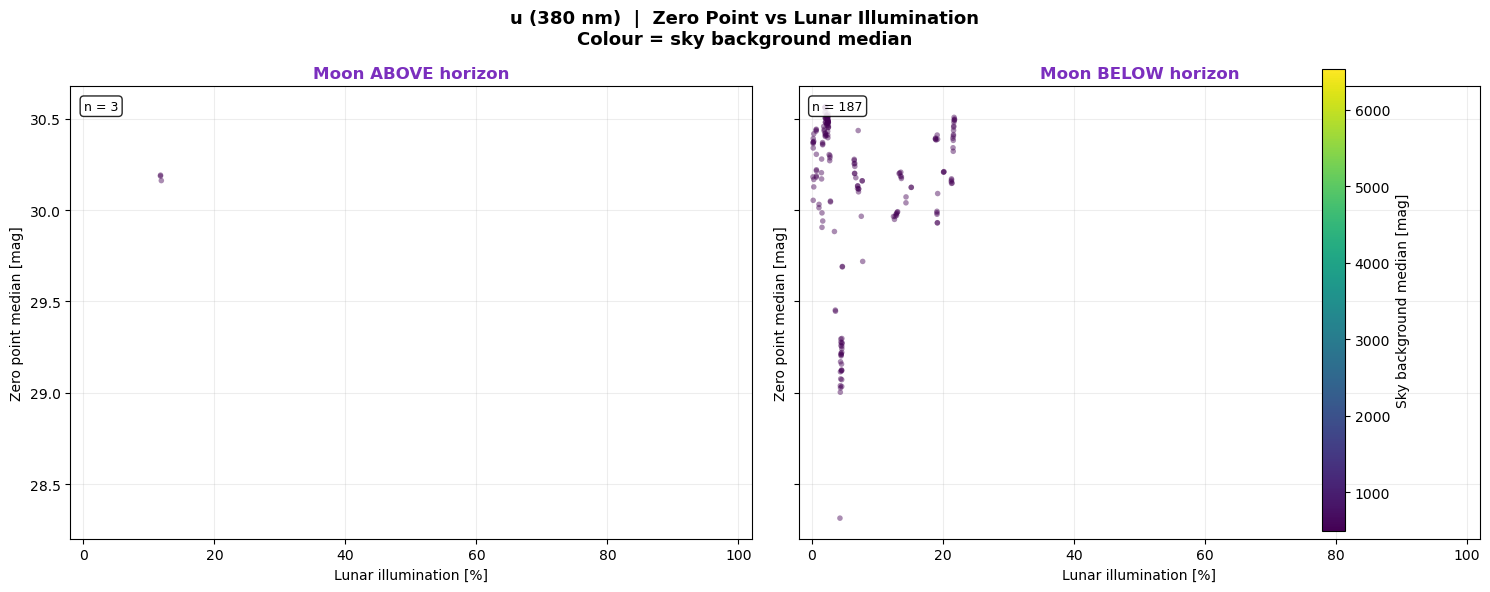

  Saved: moon_plots_consdb_only/illum_zeroPoint_u.png


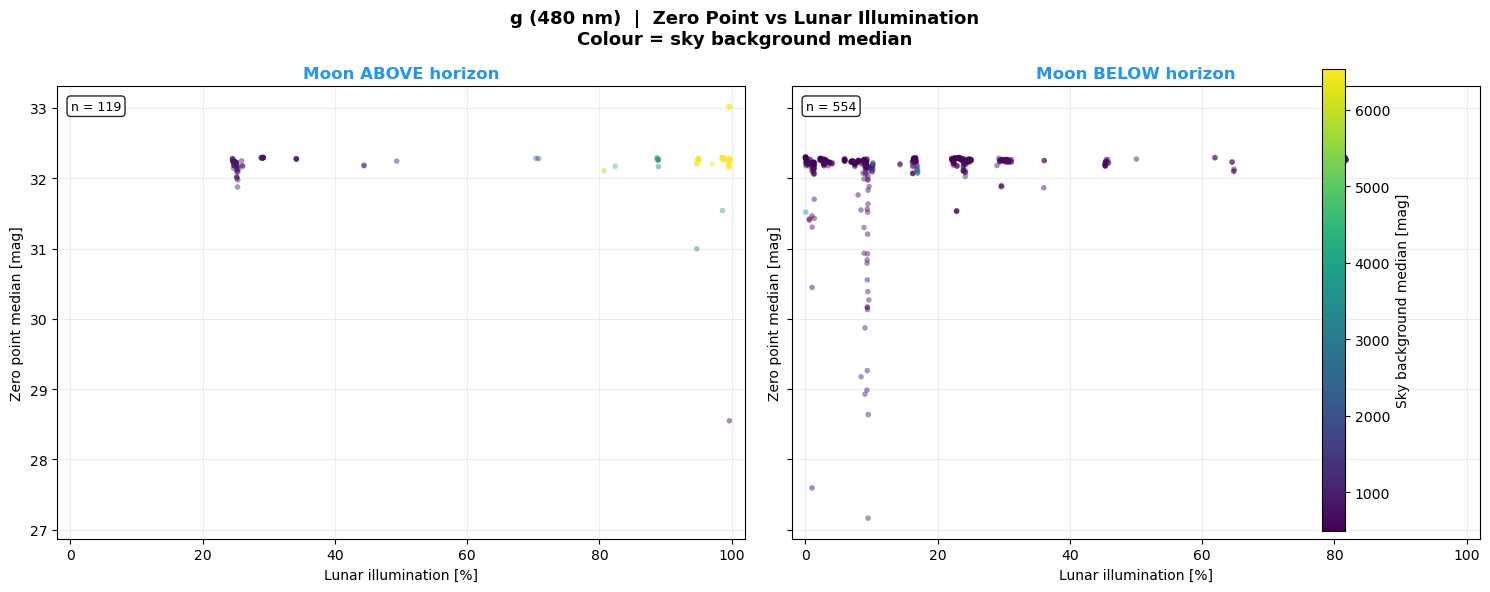

  Saved: moon_plots_consdb_only/illum_zeroPoint_g.png


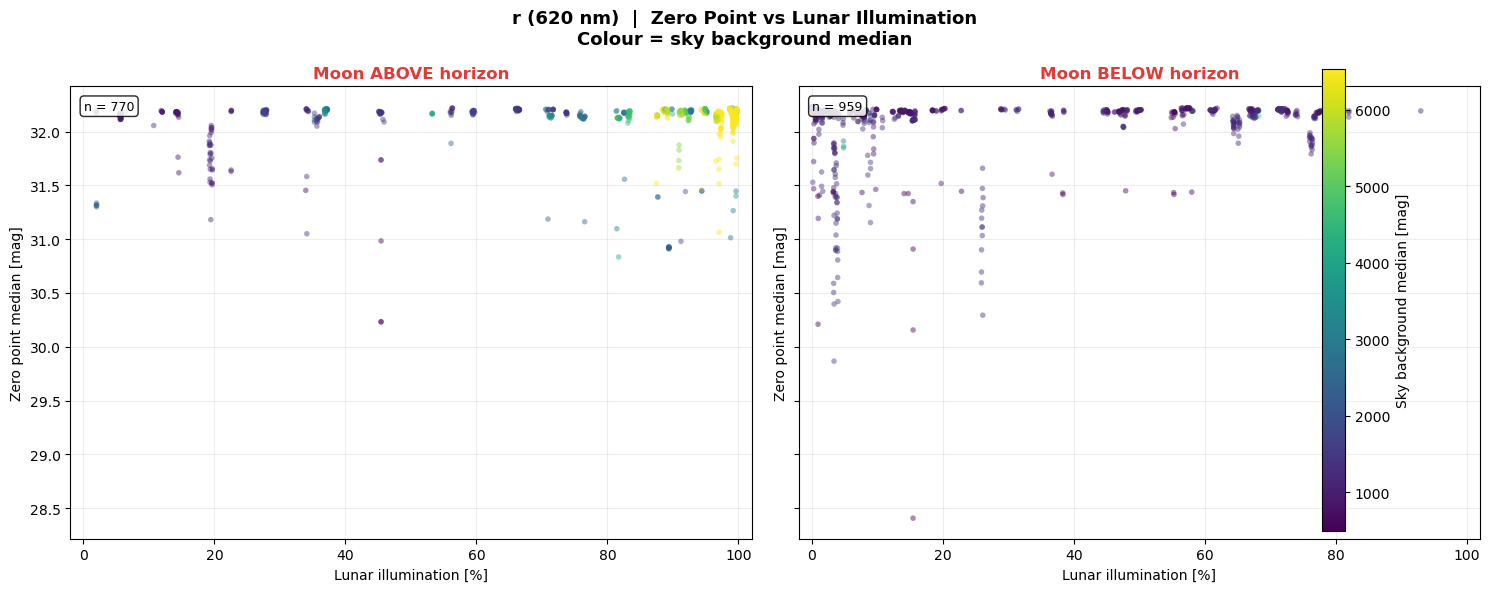

  Saved: moon_plots_consdb_only/illum_zeroPoint_r.png


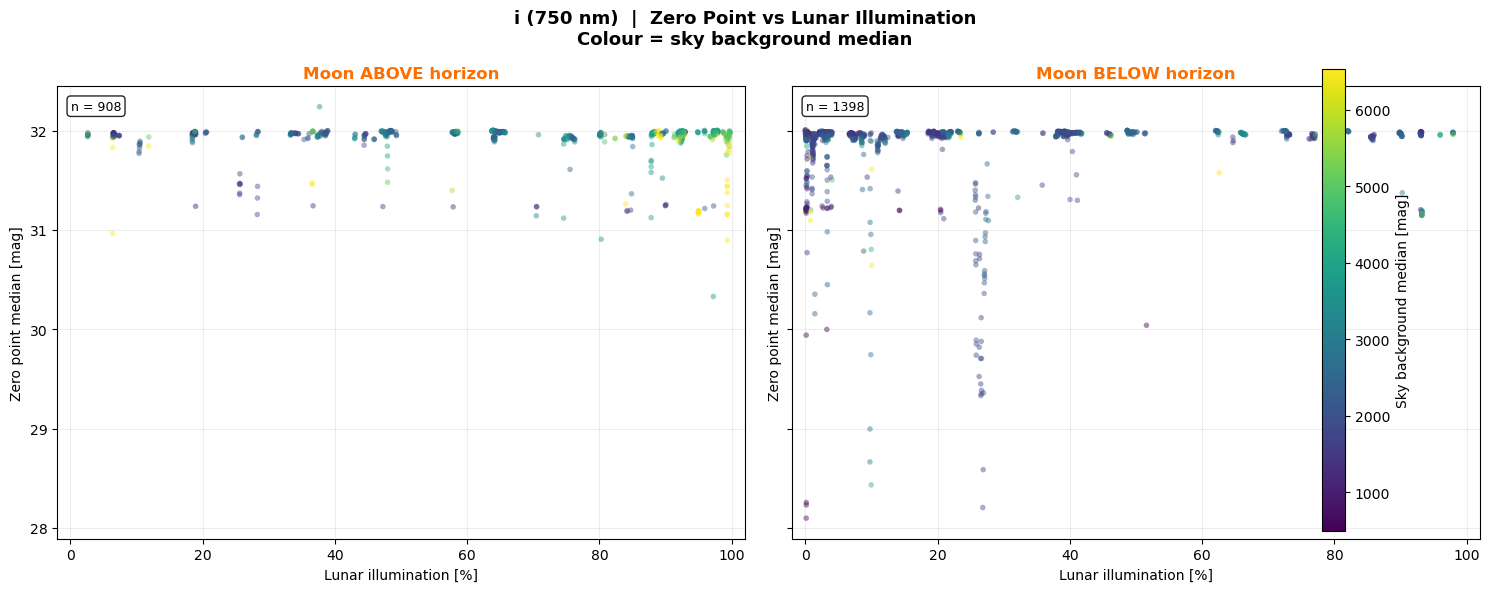

  Saved: moon_plots_consdb_only/illum_zeroPoint_i.png


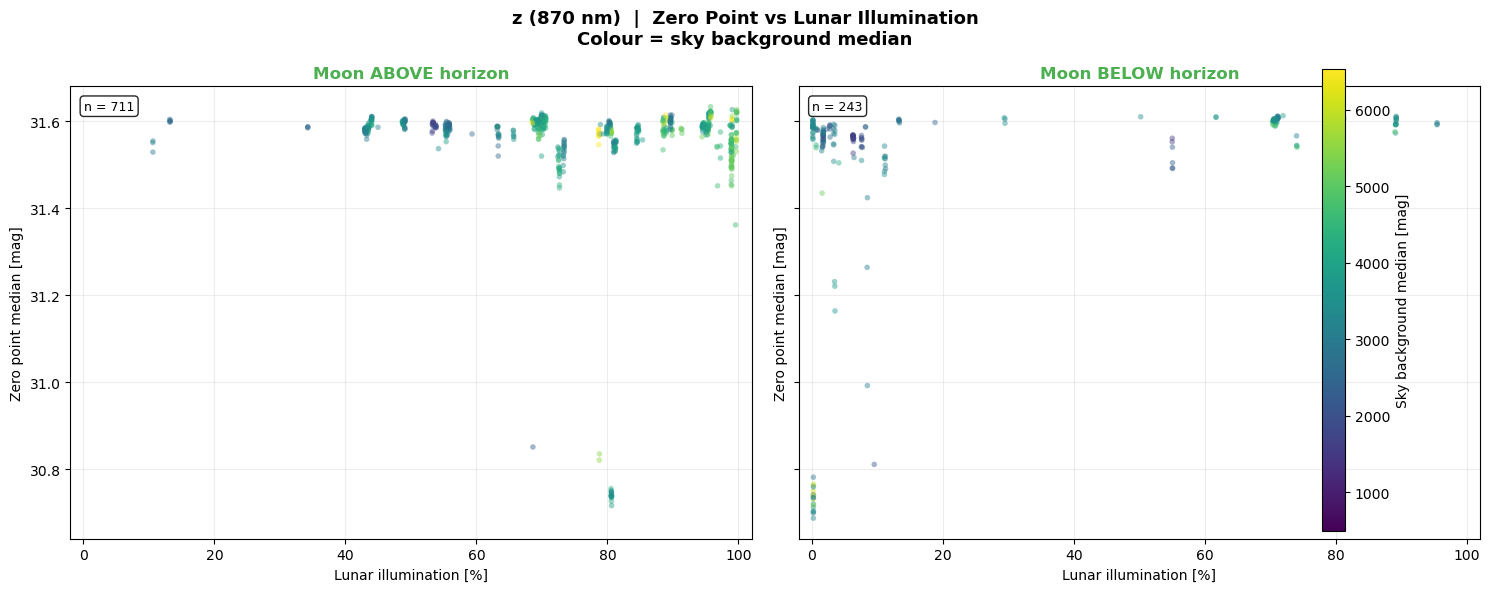

  Saved: moon_plots_consdb_only/illum_zeroPoint_z.png


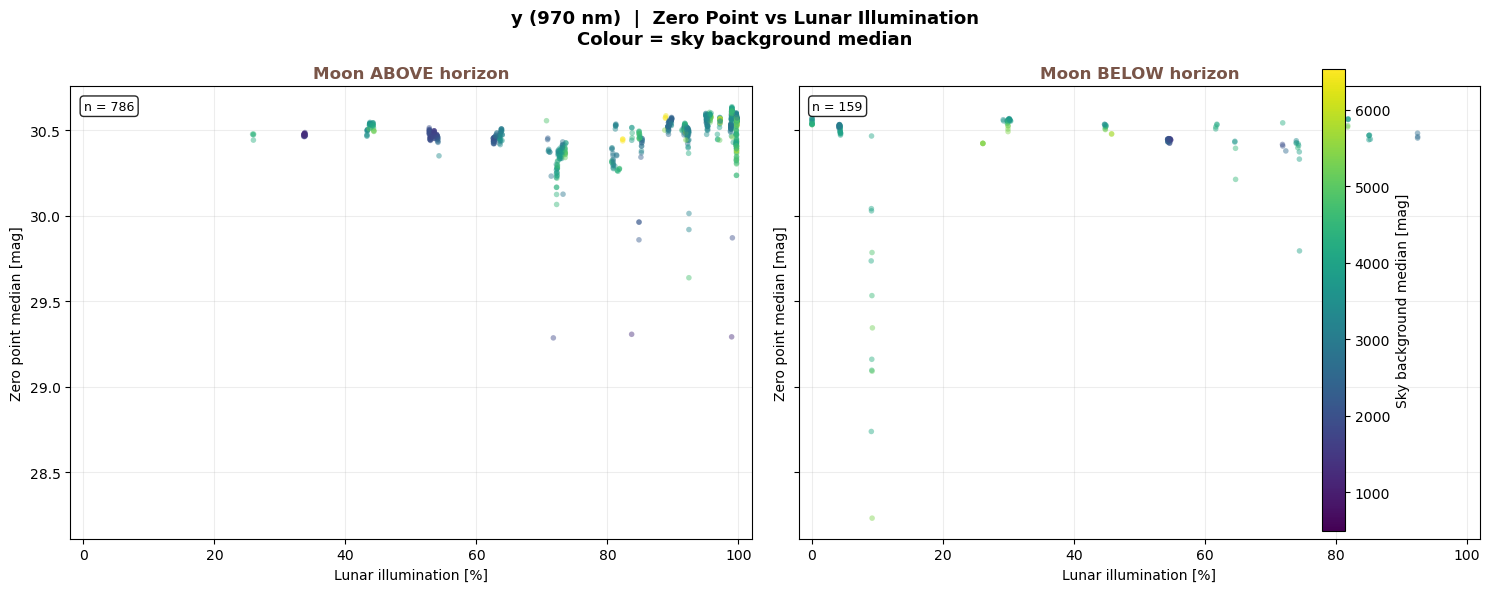

  Saved: moon_plots_consdb_only/illum_zeroPoint_y.png


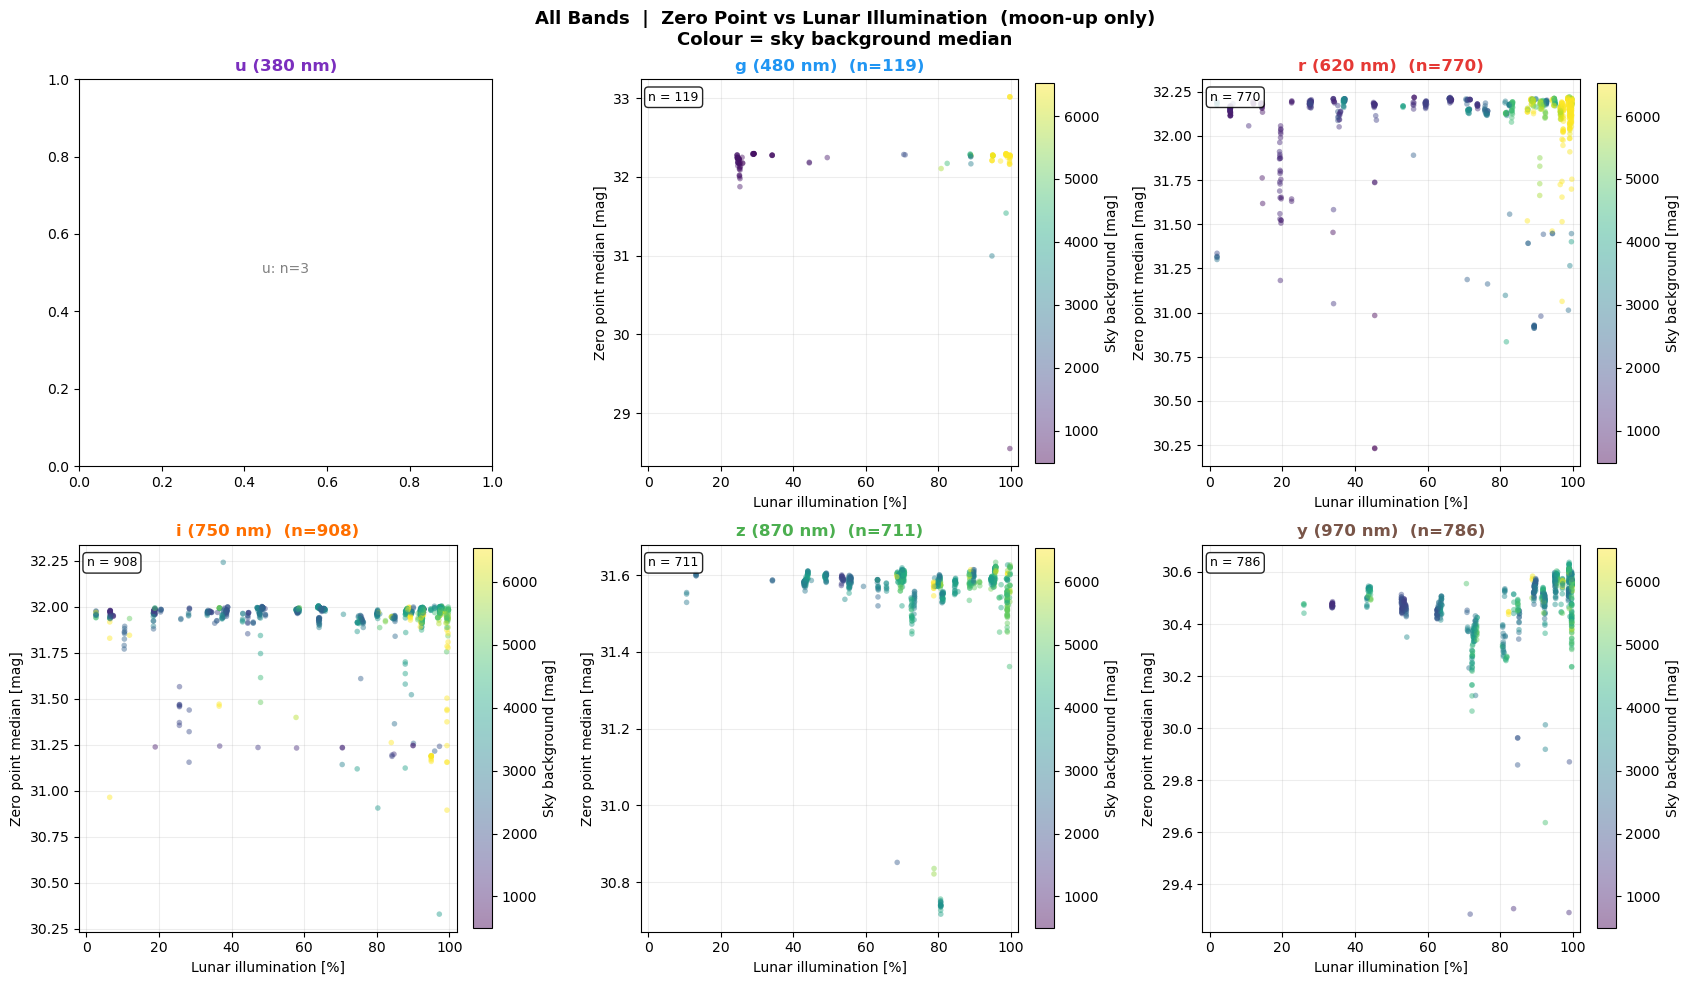

  Saved: moon_plots_consdb_only/illum_zeroPoint_all_bands.png


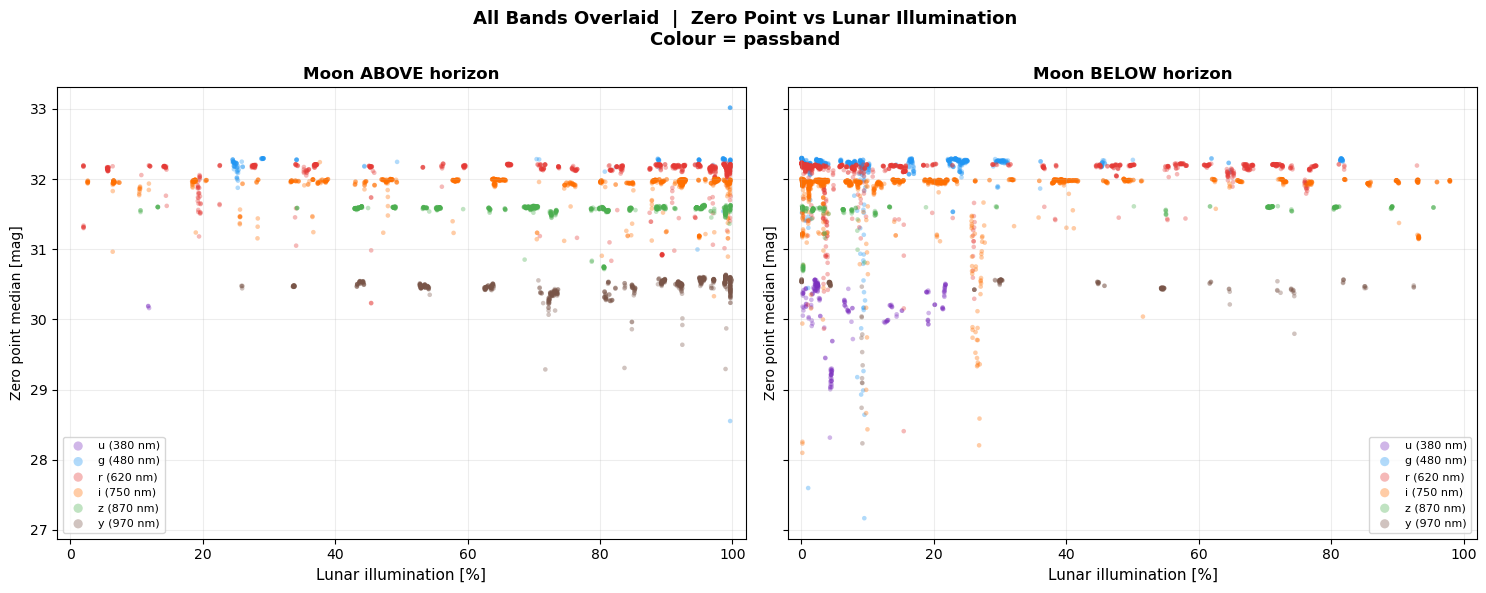

  Saved: moon_plots_consdb_only/illum_zeroPoint_overlay.png


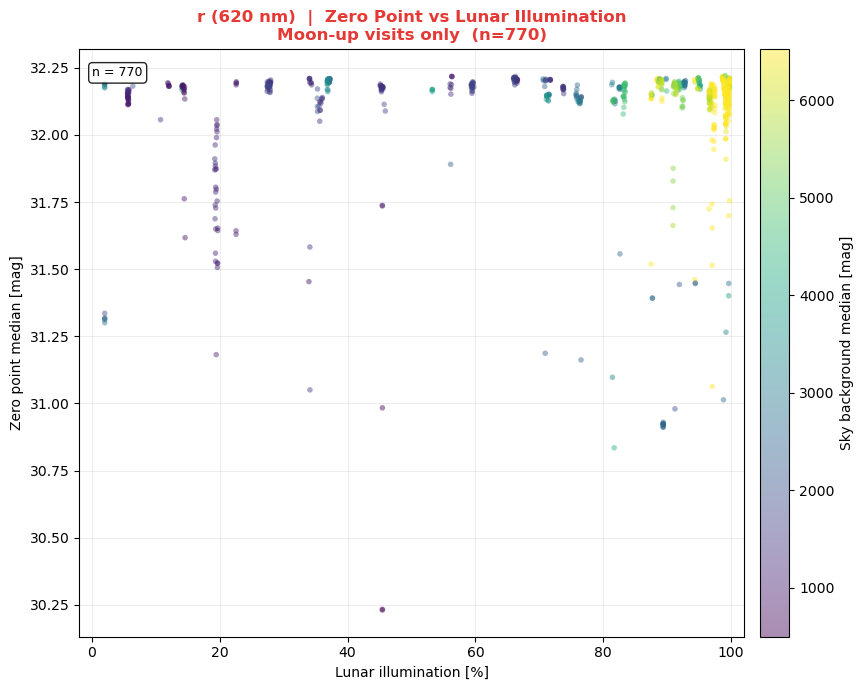

  Saved: moon_plots_consdb_only/illum_zeroPoint_r_large.png


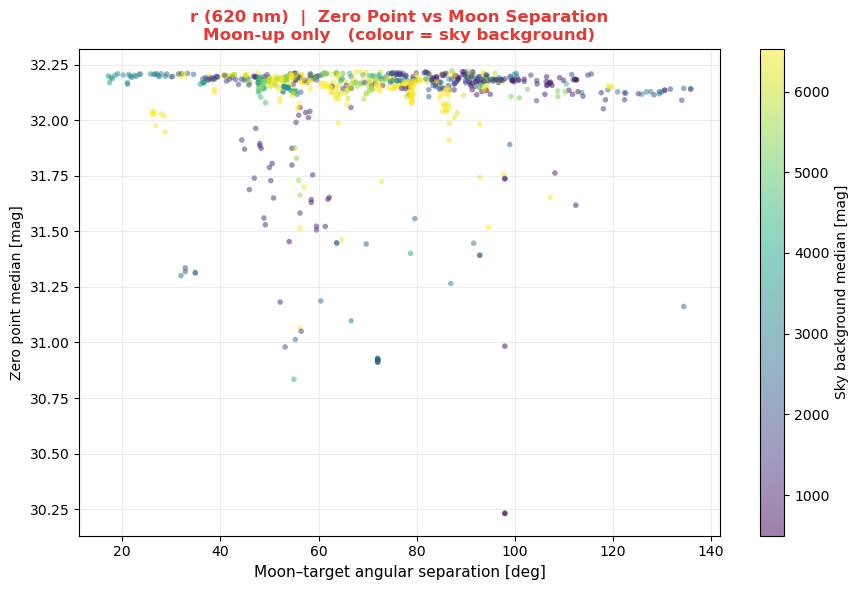

  Saved: moon_plots_consdb_only/sep_zeroPoint_r.png


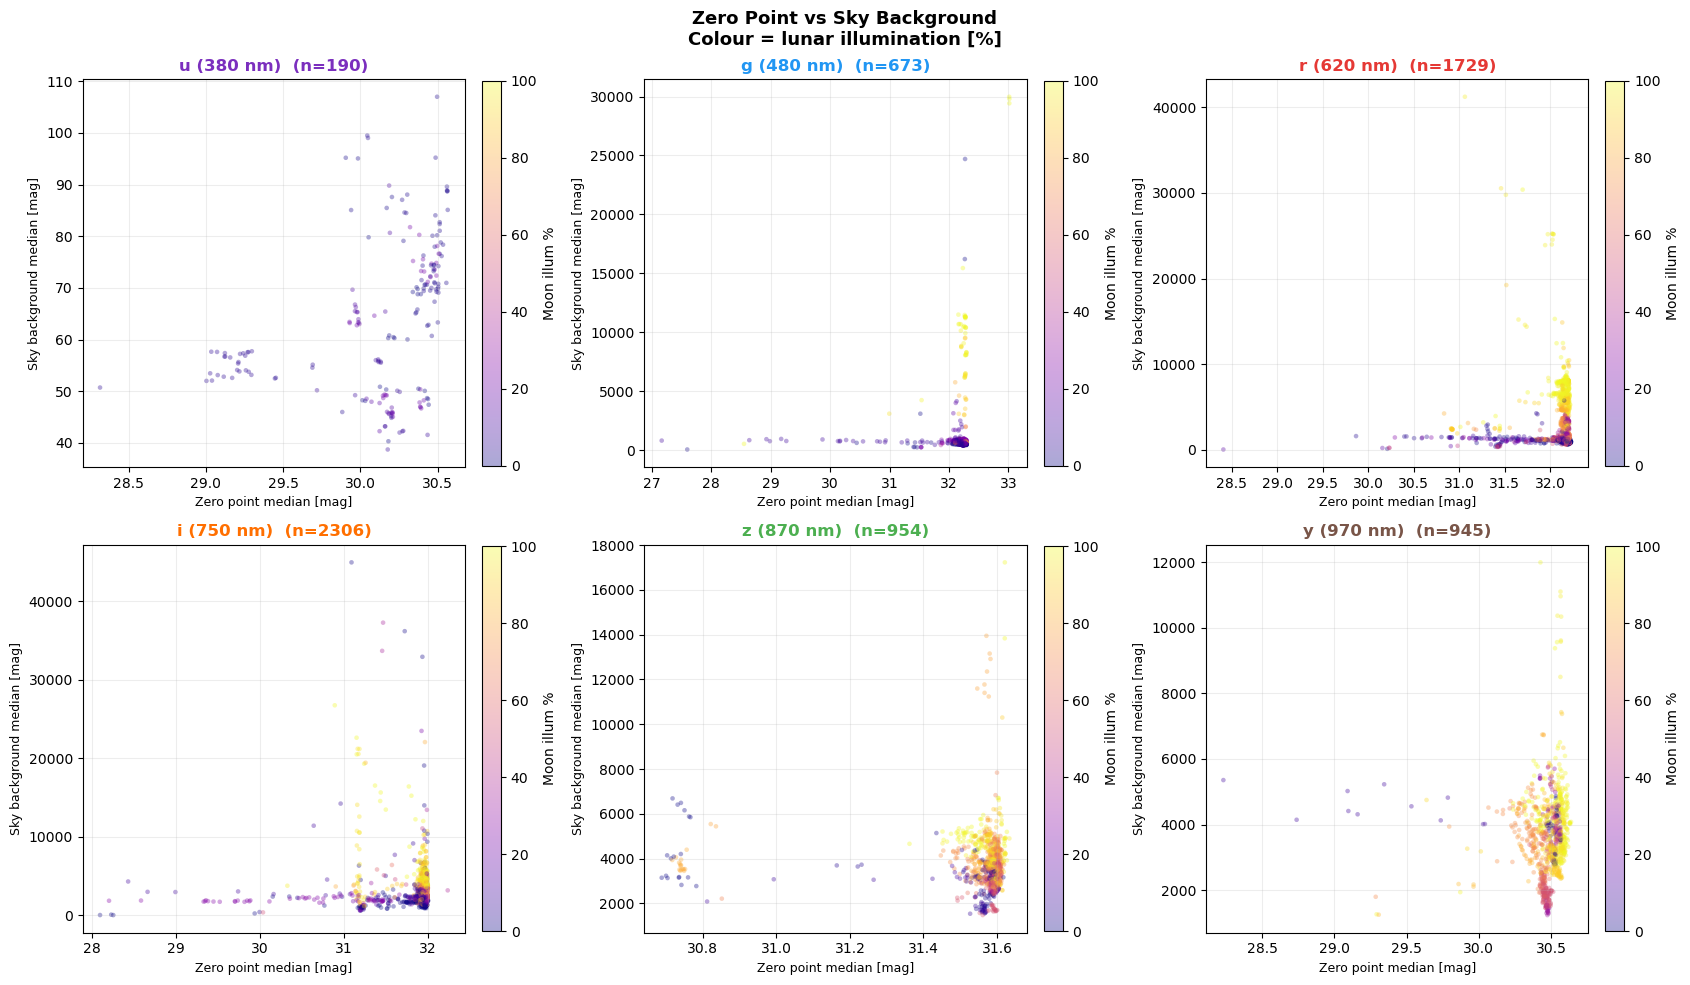

  Saved: moon_plots_consdb_only/zeroPoint_vs_skyBg.png

Step 4 / 4  —  Done
All plots saved to: moon_plots_consdb_only


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Photometry  —  ConsDB-only pipeline, single cell
#
# X-axis : lunar illumination [%]
# Y-axis : zero_point_median [mag]
# Colour : sky_bg_median [mag]
#
# Data:
#   ConsDB HDF5  →  visits_20261024_20260219.h5
#
# Uses ~25% random sampling of visits for speed.
# No DREAM matching required.
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Config — edit these ─────────────────────────────────────────────────
CONSDB_H5       = "visits_20261024_20260219.h5"
OUTPUT_DIR      = "moon_plots_consdb_only"
SAMPLE_FRAC     = 0.25
RANDOM_SEED     = 42
BANDS_TO_PLOT   = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N      = 10

# ── 1. Imports ─────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(
    lat=-30.244639*u.deg,
    lon=-70.749417*u.deg,
    height=2663.0*u.m
)

BAND_COLOR = {"u":"#7B2FBE","g":"#2196F3","r":"#E53935",
              "i":"#FF6F00","z":"#4CAF50","y":"#795548"}
BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

# ── 2. Load ConsDB HDF5 ────────────────────────────────────────────────────
print("="*60)
print("Step 1 / 4  —  Loading ConsDB HDF5")
print("="*60)

consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"  Raw rows: {len(consdb)}")
print(f"  Columns (first 30): {list(consdb.columns[:30])}")

# ── time handling ──────────────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime()
                if pd.notna(m) and np.isfinite(m) else pd.NaT
            ),
            utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(
            lambda t: Time(t).mjd if pd.notna(t) else np.nan
        )
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── standardise columns ────────────────────────────────────────────────────
for want, cands in {
    "ra":   ["s_ra", "ra"],
    "dec":  ["s_dec", "dec"],
    "band": ["band", "physical_filter"],
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in ["ra","dec","mjd","altitude","azimuth","airmass",
            "sky_bg_median","zero_point_median","stats_mag_lim_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = (
        consdb["band"].astype(str)
        .str.extract(r'([ugrizy])', expand=False)
    )

consdb = consdb.dropna(subset=[
    "exp_midpt", "mjd", "ra", "dec", "band",
    "zero_point_median", "sky_bg_median"
]).copy()

consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

consdb = consdb.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).copy()

print(f"\n  Sampled visits: {len(consdb)} ({100*SAMPLE_FRAC:.1f}% of filtered rows)")
print(f"  Time range    : {consdb['exp_midpt'].min()} → {consdb['exp_midpt'].max()}")
print(f"  Bands         : {sorted(consdb['band'].unique())}")

print(f"\n  zero_point_median stats:\n{consdb['zero_point_median'].describe()}")
print(f"\n  sky_bg_median stats:\n{consdb['sky_bg_median'].describe()}")

# ── 3. Compute moon geometry ───────────────────────────────────────────────
print("\n" + "="*60)
print("Step 2 / 4  —  Computing Moon geometry")
print("="*60)

results = []

for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])

    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    alt_deg = float(row["altitude"]) if pd.notna(row.get("altitude", np.nan)) else float(aa.alt.deg)
    az_deg  = float(row["azimuth"])  if pd.notna(row.get("azimuth", np.nan))  else float(aa.az.deg % 360)

    a1, a2 = np.radians(float(maa.alt.deg)), np.radians(alt_deg)
    daz = np.radians(float(maa.az.deg % 360) - az_deg)
    moon_sep = float(np.degrees(np.arccos(np.clip(
        np.sin(a1)*np.sin(a2) + np.cos(a1)*np.cos(a2)*np.cos(daz), -1, 1
    ))))

    results.append({
        "band": row["band"],
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "altitude": alt_deg,
        "moon_illum_pct": illum * 100,
        "moon_up": moon_up,
        "moon_sep": moon_sep,
        "sky_bg": float(row["sky_bg_median"]),
        "zero_point": float(row["zero_point_median"]),
        "mag_lim": float(row.get("stats_mag_lim_median", np.nan)),
    })

    if len(results) % 2000 == 0:
        print(f"  ... {len(results)} rows")

df = pd.DataFrame(results)

print(f"\n  Valid rows   : {len(df)}")
print(f"  moon_illum_pct : {df['moon_illum_pct'].min():.1f} – {df['moon_illum_pct'].max():.1f} %")
print(f"  zero_point     : {df['zero_point'].min():.3f} – {df['zero_point'].max():.3f}")
print(f"  sky_bg         : {df['sky_bg'].min():.3f} – {df['sky_bg'].max():.3f}")

csv_path = os.path.join(OUTPUT_DIR, "moon_zeroPoint_skyBg.csv")
df.to_csv(csv_path, index=False)
print(f"\n  Saved: {csv_path}")

# ── 4. Plots ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Step 3 / 4  —  Plotting")
print("="*60)

bands_present = [b for b in BANDS_TO_PLOT if b in df["band"].unique()]

clim_low  = float(np.nanpercentile(df["sky_bg"], 5))
clim_high = float(np.nanpercentile(df["sky_bg"], 95))
cnorm = Normalize(vmin=clim_low, vmax=clim_high)
cmap  = "viridis"

CBAR_LABEL = "Sky background median [mag]"
XLABEL = "Lunar illumination [%]"
YLABEL = "Zero point median [mag]"

def _cbar(fig, axes_list):
    return fig.colorbar(
        ScalarMappable(norm=cnorm, cmap=cmap),
        ax=axes_list,
        label=CBAR_LABEL,
        fraction=0.02,
        pad=0.02
    )

def _scatter(ax, sub):
    return ax.scatter(
        sub["moon_illum_pct"],
        sub["zero_point"],
        c=sub["sky_bg"],
        cmap=cmap,
        norm=cnorm,
        s=16,
        alpha=0.45,
        edgecolors="none",
        zorder=3
    )

def _decorate(ax, bc, title, n):
    ax.set_xlabel(XLABEL, fontsize=10)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_xlim(-2, 102)
    ax.set_title(title, weight="bold", color=bc)
    ax.grid(alpha=0.22)
    ax.text(
        0.02, 0.97, f"n = {n}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.85)
    )

# ── Fig 1: per band, moon-up | moon-down ──────────────────────────────────
for band in bands_present:
    bdf     = df[df["band"] == band]
    moon_up = bdf[bdf["moon_up"]]
    moon_dn = bdf[~bdf["moon_up"]]
    bc      = BAND_COLOR[band]

    fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    fig.suptitle(
        f"{BAND_LABEL[band]}  |  Zero Point vs Lunar Illumination\n"
        f"Colour = sky background median",
        fontsize=13, weight="bold"
    )

    for ax, sub, title in [
        (ax_up, moon_up, "Moon ABOVE horizon"),
        (ax_dn, moon_dn, "Moon BELOW horizon"),
    ]:
        if len(sub) < 3:
            ax.text(0.5, 0.5, f"n = {len(sub)}", transform=ax.transAxes,
                    ha="center", fontsize=12, color="gray")
            ax.set_title(title, weight="bold")
            continue
        _scatter(ax, sub)
        _decorate(ax, bc, title, len(sub))

    _cbar(fig, [ax_up, ax_dn])
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f"illum_zeroPoint_{band}.png")
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {p}")

# ── Fig 2: all bands, moon-up only ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "All Bands  |  Zero Point vs Lunar Illumination  (moon-up only)\n"
    "Colour = sky background median",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = df[(df["band"] == band) & df["moon_up"]]
    bc  = BAND_COLOR[band]
    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue
    sc = _scatter(ax, sub)
    _decorate(ax, bc, BAND_LABEL.get(band, band)+f"  (n={len(sub)})", len(sub))
    plt.colorbar(sc, ax=ax, label="Sky background [mag]", fraction=0.046, pad=0.04)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "illum_zeroPoint_all_bands.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {p}")

# ── Fig 3: all bands overlaid, moon-up | moon-down ────────────────────────
fig, (ax_up, ax_dn) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle("All Bands Overlaid  |  Zero Point vs Lunar Illumination\n"
             "Colour = passband", fontsize=13, weight="bold")

for ax, flag, title in [
    (ax_up, True,  "Moon ABOVE horizon"),
    (ax_dn, False, "Moon BELOW horizon"),
]:
    for band in bands_present:
        sub = df[(df["band"] == band) & (df["moon_up"] == flag)]
        if len(sub) < 3:
            continue
        ax.scatter(sub["moon_illum_pct"], sub["zero_point"],
                   color=BAND_COLOR[band], label=BAND_LABEL[band],
                   s=11, alpha=0.35, edgecolors="none")
    ax.set_xlabel(XLABEL, fontsize=11)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_xlim(-2, 102)
    ax.set_title(title, weight="bold")
    ax.grid(alpha=0.22)
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "illum_zeroPoint_overlay.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {p}")

# ── Fig 4: u and r large, moon-up only ────────────────────────────────────
for band in [b for b in ["u","r"] if b in bands_present]:
    sub = df[(df["band"] == band) & df["moon_up"]]
    if len(sub) < PLOT_MIN_N:
        continue
    bc = BAND_COLOR[band]
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = _scatter(ax, sub)
    plt.colorbar(sc, ax=ax, label=CBAR_LABEL, pad=0.02)
    _decorate(ax, bc,
              f"{BAND_LABEL[band]}  |  Zero Point vs Lunar Illumination\n"
              f"Moon-up visits only  (n={len(sub)})", len(sub))
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f"illum_zeroPoint_{band}_large.png")
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {p}")

# ── Fig 5: moon separation vs zero point, colour = sky background ─────────
for band in [b for b in ["u","r"] if b in bands_present]:
    sub = df[(df["band"] == band) & df["moon_up"]].dropna(
        subset=["moon_sep","zero_point","sky_bg"]
    )
    if len(sub) < PLOT_MIN_N:
        continue
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sub["moon_sep"], sub["zero_point"],
                    c=sub["sky_bg"], cmap=cmap, norm=cnorm,
                    s=16, alpha=0.5, edgecolors="none")
    plt.colorbar(sc, ax=ax, label=CBAR_LABEL)
    ax.set_xlabel("Moon–target angular separation [deg]", fontsize=11)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_title(f"{BAND_LABEL[band]}  |  Zero Point vs Moon Separation\n"
                 "Moon-up only   (colour = sky background)",
                 weight="bold", color=BAND_COLOR[band])
    ax.grid(alpha=0.22)
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, f"sep_zeroPoint_{band}.png")
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {p}")

# ── Fig 6: zero point vs sky background ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Zero Point vs Sky Background\n"
    "Colour = lunar illumination [%]",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = df[df["band"] == band].dropna(subset=["zero_point","sky_bg"])
    bc  = BAND_COLOR[band]
    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue
    sc = ax.scatter(sub["zero_point"], sub["sky_bg"],
                    c=sub["moon_illum_pct"], cmap="plasma",
                    vmin=0, vmax=100, s=11, alpha=0.35, edgecolors="none")
    ax.set_title(f"{BAND_LABEL.get(band,band)}  (n={len(sub)})",
                 weight="bold", color=bc)
    ax.set_xlabel("Zero point median [mag]", fontsize=9)
    ax.set_ylabel("Sky background median [mag]", fontsize=9)
    ax.grid(alpha=0.22)
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyBg.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {p}")

print("\n" + "="*60)
print("Step 4 / 4  —  Done")
print(f"All plots saved to: {OUTPUT_DIR}")
print("="*60)

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Zero Point vs Sky Brightness Excess  —  ConsDB-only, single cell
#
# Keeps only visits with photometric scale > 0.32
#
# X-axis : sky brightness excess above model  [mag]
#           = sky_bg_median - model_sky
#
# Y-axis : zero-point attenuation proxy [mag]
#           = -2.5 log10(photometric_scale)
#
# Plot style : log-log
# Colour     : lunar illumination [%]
#
# Data:
#   ConsDB HDF5  →  visits_20261024_20260219.h5
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Config ──────────────────────────────────────────────────────────────
CONSDB_H5       = "visits_20261024_20260219.h5"
OUTPUT_DIR      = "moon_plots_consdb_only"
SAMPLE_FRAC     = 0.25
RANDOM_SEED     = 42
BANDS_TO_PLOT   = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N      = 10

PHOTOMETRIC_SCALE_CUT = 0.32

# IMPORTANT: set this to the actual model-sky column in your ConsDB table
MODEL_SKY_COL   = "sky_bg_model"

# This is the "photometric scale" column you referred to
PHOT_SCALE_COL  = "eff_time_zero_point_scale_median"

# ── 1. Imports ─────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(
    lat=-30.244639*u.deg,
    lon=-70.749417*u.deg,
    height=2663.0*u.m
)

BAND_COLOR = {"u":"#7B2FBE","g":"#2196F3","r":"#E53935",
              "i":"#FF6F00","z":"#4CAF50","y":"#795548"}
BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

# ── 2. Load ConsDB ─────────────────────────────────────────────────────────
print("="*60)
print("Step 1 / 4  —  Loading ConsDB HDF5")
print("="*60)

consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"  Raw rows: {len(consdb)}")
print(f"  Columns (first 40): {list(consdb.columns[:40])}")

# ── time handling ──────────────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime()
                if pd.notna(m) and np.isfinite(m) else pd.NaT
            ),
            utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(
            lambda t: Time(t).mjd if pd.notna(t) else np.nan
        )
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── standardise columns ────────────────────────────────────────────────────
for want, cands in {
    "ra":   ["s_ra", "ra"],
    "dec":  ["s_dec", "dec"],
    "band": ["band", "physical_filter"],
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

numeric_cols = [
    "ra","dec","mjd","altitude","azimuth","airmass",
    "sky_bg_median","zero_point_median","stats_mag_lim_median",
    PHOT_SCALE_COL, MODEL_SKY_COL
]
for col in numeric_cols:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = (
        consdb["band"].astype(str)
        .str.extract(r'([ugrizy])', expand=False)
    )

# ── helpful failure if model column is wrong ───────────────────────────────
if MODEL_SKY_COL not in consdb.columns:
    print("\nERROR: MODEL_SKY_COL not found.")
    print(f"You set MODEL_SKY_COL = '{MODEL_SKY_COL}'")
    print("\nPossible sky-related columns:")
    print([c for c in consdb.columns if "sky" in c.lower()])
    raise KeyError(f"Column '{MODEL_SKY_COL}' not found.")

if PHOT_SCALE_COL not in consdb.columns:
    raise KeyError(f"Column '{PHOT_SCALE_COL}' not found.")

# ── filter usable rows ─────────────────────────────────────────────────────
consdb = consdb.dropna(subset=[
    "exp_midpt", "mjd", "ra", "dec", "band",
    "sky_bg_median", MODEL_SKY_COL, PHOT_SCALE_COL
]).copy()

consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

# sample ~25%
consdb = consdb.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).copy()

print(f"\n  Sampled visits: {len(consdb)} ({100*SAMPLE_FRAC:.1f}% of filtered rows)")
print(f"  Time range    : {consdb['exp_midpt'].min()} → {consdb['exp_midpt'].max()}")
print(f"  Bands         : {sorted(consdb['band'].unique())}")

# ── apply photometric-scale cut ────────────────────────────────────────────
consdb = consdb[consdb[PHOT_SCALE_COL] > PHOTOMETRIC_SCALE_CUT].copy()
print(f"\n  After photometric scale cut ({PHOT_SCALE_COL} > {PHOTOMETRIC_SCALE_CUT}): {len(consdb)} rows")

# ── 3. Compute moon illumination only ──────────────────────────────────────
print("\n" + "="*60)
print("Step 2 / 4  —  Computing Moon illumination")
print("="*60)

moon_illum_list = []

for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    t   = Time(mjd, format="mjd")

    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)

    sep = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_illum_list.append(illum * 100)

    if (len(moon_illum_list) % 2000 == 0) and (len(moon_illum_list) > 0):
        print(f"  ... {len(moon_illum_list)} rows")

consdb["moon_illum_pct"] = moon_illum_list

# ── 4. Derived quantities ──────────────────────────────────────────────────
# sky excess above model
consdb["sky_excess_mag"] = consdb["sky_bg_median"] - consdb[MODEL_SKY_COL]

# zero-point attenuation proxy from photometric scale
consdb["zp_attenuation_mag"] = -2.5 * np.log10(consdb[PHOT_SCALE_COL].clip(lower=1e-6))

# keep only positive values for log-log plotting
df = consdb[
    (consdb["sky_excess_mag"] > 0) &
    (consdb["zp_attenuation_mag"] > 0)
].copy()

print(f"\n  Rows surviving log-log positivity cut: {len(df)}")
print(f"  sky_excess_mag       : {df['sky_excess_mag'].min():.4f} – {df['sky_excess_mag'].max():.4f}")
print(f"  zp_attenuation_mag   : {df['zp_attenuation_mag'].min():.4f} – {df['zp_attenuation_mag'].max():.4f}")
print(f"  Correlation          : {df['sky_excess_mag'].corr(df['zp_attenuation_mag']):.3f}")

csv_path = os.path.join(OUTPUT_DIR, "zp_vs_skyExcess_loglog.csv")
df.to_csv(csv_path, index=False)
print(f"\n  Saved: {csv_path}")

# ── 5. Plot only: zero point vs sky brightness excess ─────────────────────
print("\n" + "="*60)
print("Step 3 / 4  —  Plotting")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Zero-Point Attenuation vs Sky Brightness Excess Above Model\n"
    f"Only visits with {PHOT_SCALE_COL} > {PHOTOMETRIC_SCALE_CUT}   |   log–log",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = df[df["band"] == band].dropna(subset=["sky_excess_mag", "zp_attenuation_mag"])
    bc  = BAND_COLOR[band]

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        ax.set_xscale("log")
        ax.set_yscale("log")
        continue

    sc = ax.scatter(
        sub["sky_excess_mag"],
        sub["zp_attenuation_mag"],
        c=sub["moon_illum_pct"],
        cmap="plasma",
        vmin=0, vmax=100,
        s=12, alpha=0.38, edgecolors="none"
    )

    r = sub["sky_excess_mag"].corr(sub["zp_attenuation_mag"])

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(alpha=0.22, which="both")

    ax.set_title(
        f"{BAND_LABEL.get(band,band)}  (n={len(sub)})  r={r:.3f}",
        weight="bold", color=bc
    )
    ax.set_xlabel(r"Sky brightness excess above model  [mag]", fontsize=9)
    ax.set_ylabel(r"Zero-point attenuation  [mag]", fontsize=9)

    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, "zp_vs_skyExcess_loglog.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved: {p}")

print("\n" + "="*60)
print("Step 4 / 4  —  Done")
print(f"All outputs saved to: {OUTPUT_DIR}")
print("="*60)

Step 1 / 4  —  Loading ConsDB HDF5
  Raw rows: 29933
  Columns (first 40): ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason', 'physical_filter', 'pressure', 's_dec', 's_ra', 's_region', 'scheduler_note', 'science_program', 'seq_num', 'shut_time', 'simulated']

ERROR: MODEL_SKY_COL not found.
You set MODEL_SKY_COL = 'sky_bg_model'

Possible sky-related columns:
['can_see_sky', 'sky_rotation', 'eff_time_sky_bg_scale_max', 'eff_time_sky_bg_scale_median', 'eff_time_sky_bg_scale_min', 'sky_bg_max', 'sky_bg_median', 'sky_bg_min', 'sky_noise_max', 'sky_noise_median', 'sky_noise_min', 'sky_bg_mag']


KeyError: "Column 'sky_bg_model' not found."

Step 1 / 5  —  Loading ConsDB HDF5
Raw rows: 29,933
Columns (first 40): ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason', 'physical_filter', 'pressure', 's_dec', 's_ra', 's_region', 'scheduler_note', 'science_program', 'seq_num', 'shut_time', 'simulated']

Rows after minimal required-column cuts: 27,189
Rows removed by minimal cuts: 2,744

Sampled visits: 6,797 (25.0% of minimally filtered rows)
Time range    : 2025-10-25 00:42:08.712000+00:00  →  2026-02-20 09:33:25.663000+00:00
Bands         : ['g', 'i', 'r', 'u', 'y', 'z']

zero_point_median stats:
count    6797.000000
mean       31.660542
std         0.672417
min        27.1656

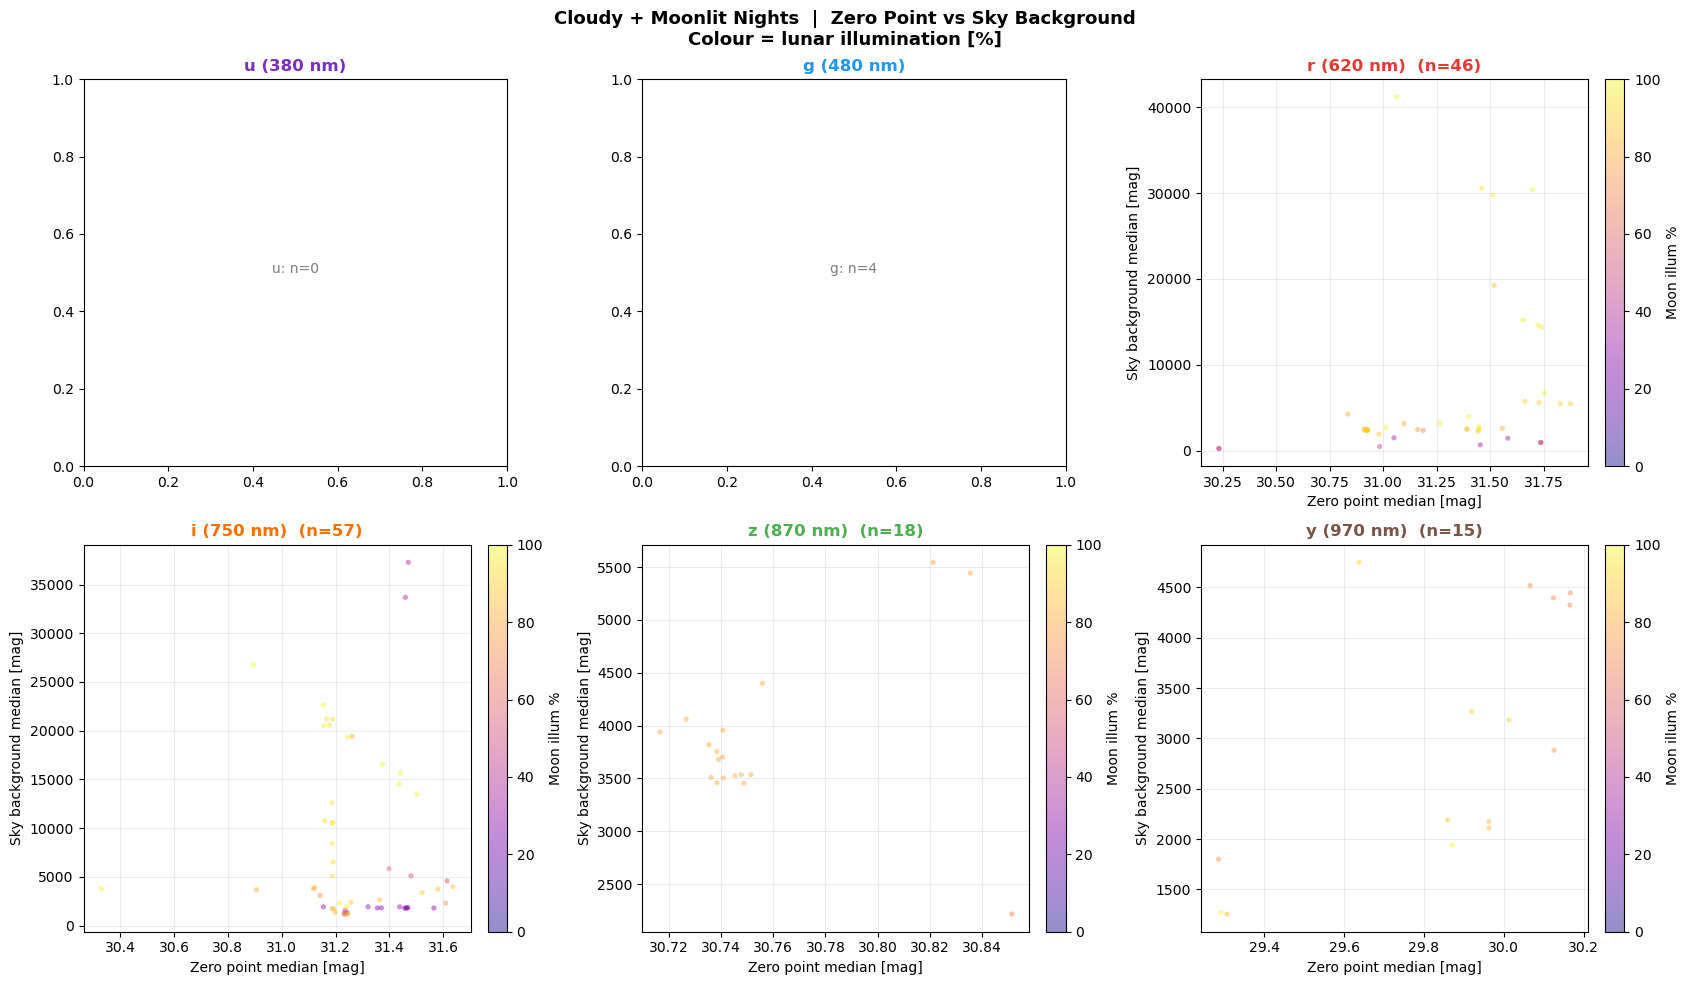

Saved: cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyBg_cloudy_moonlit.png


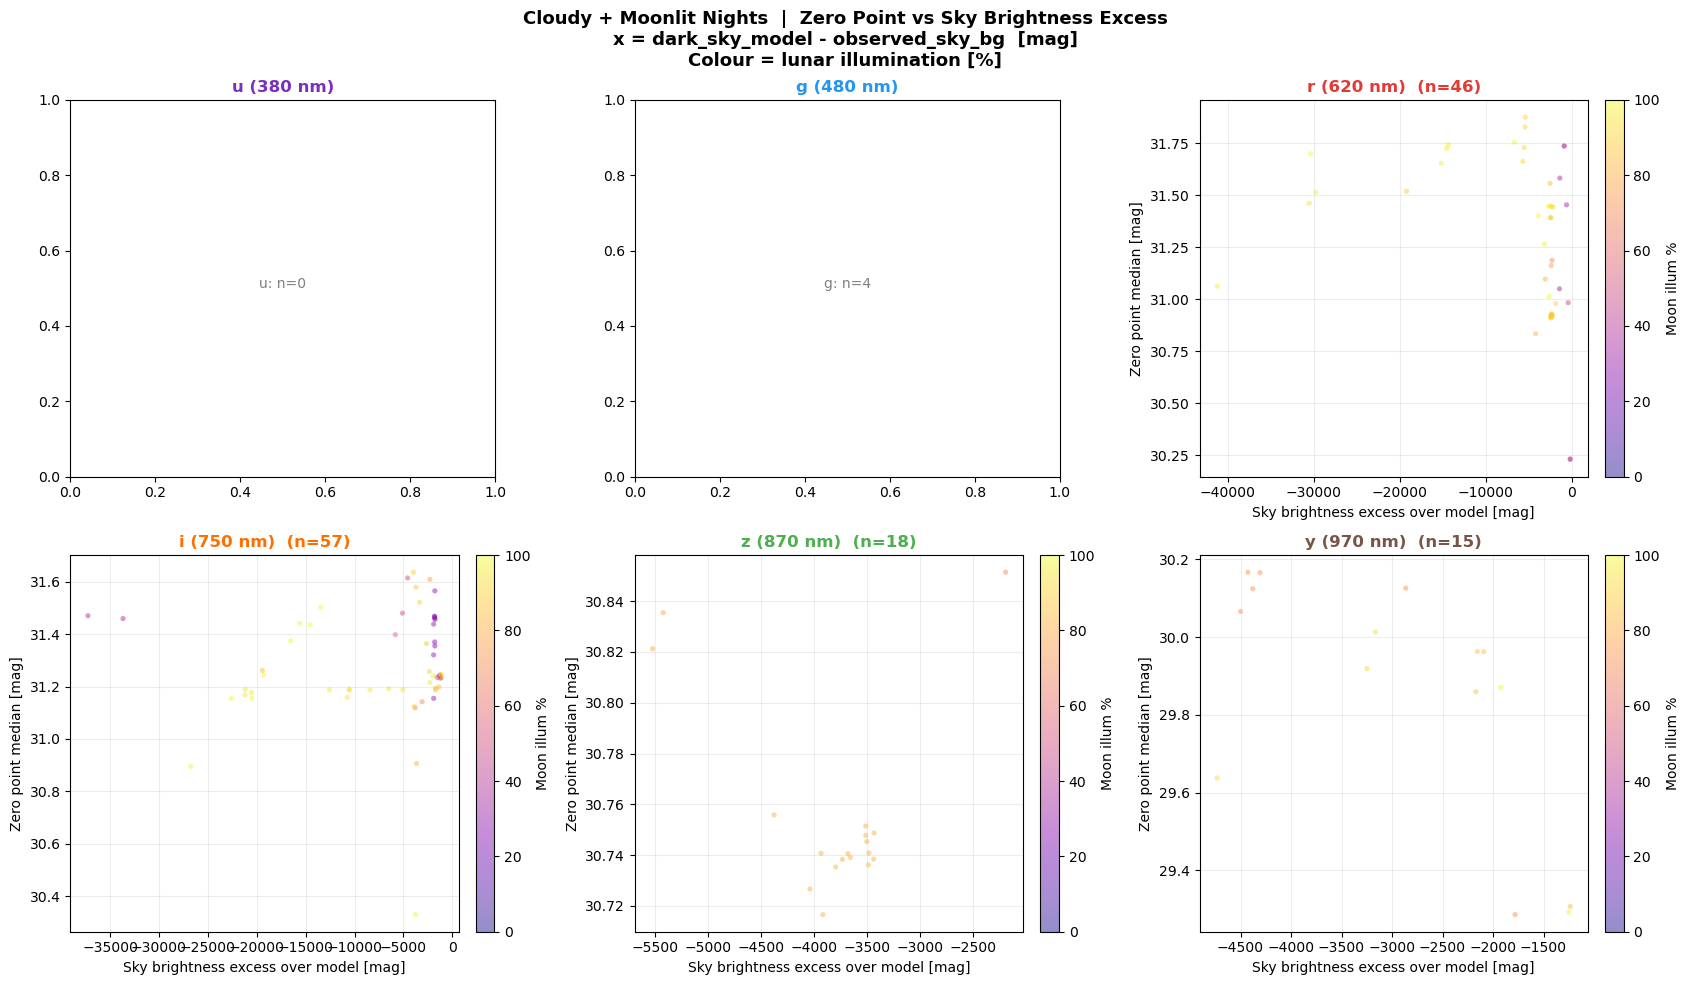

Saved: cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyExcessMag_cloudy_moonlit.png


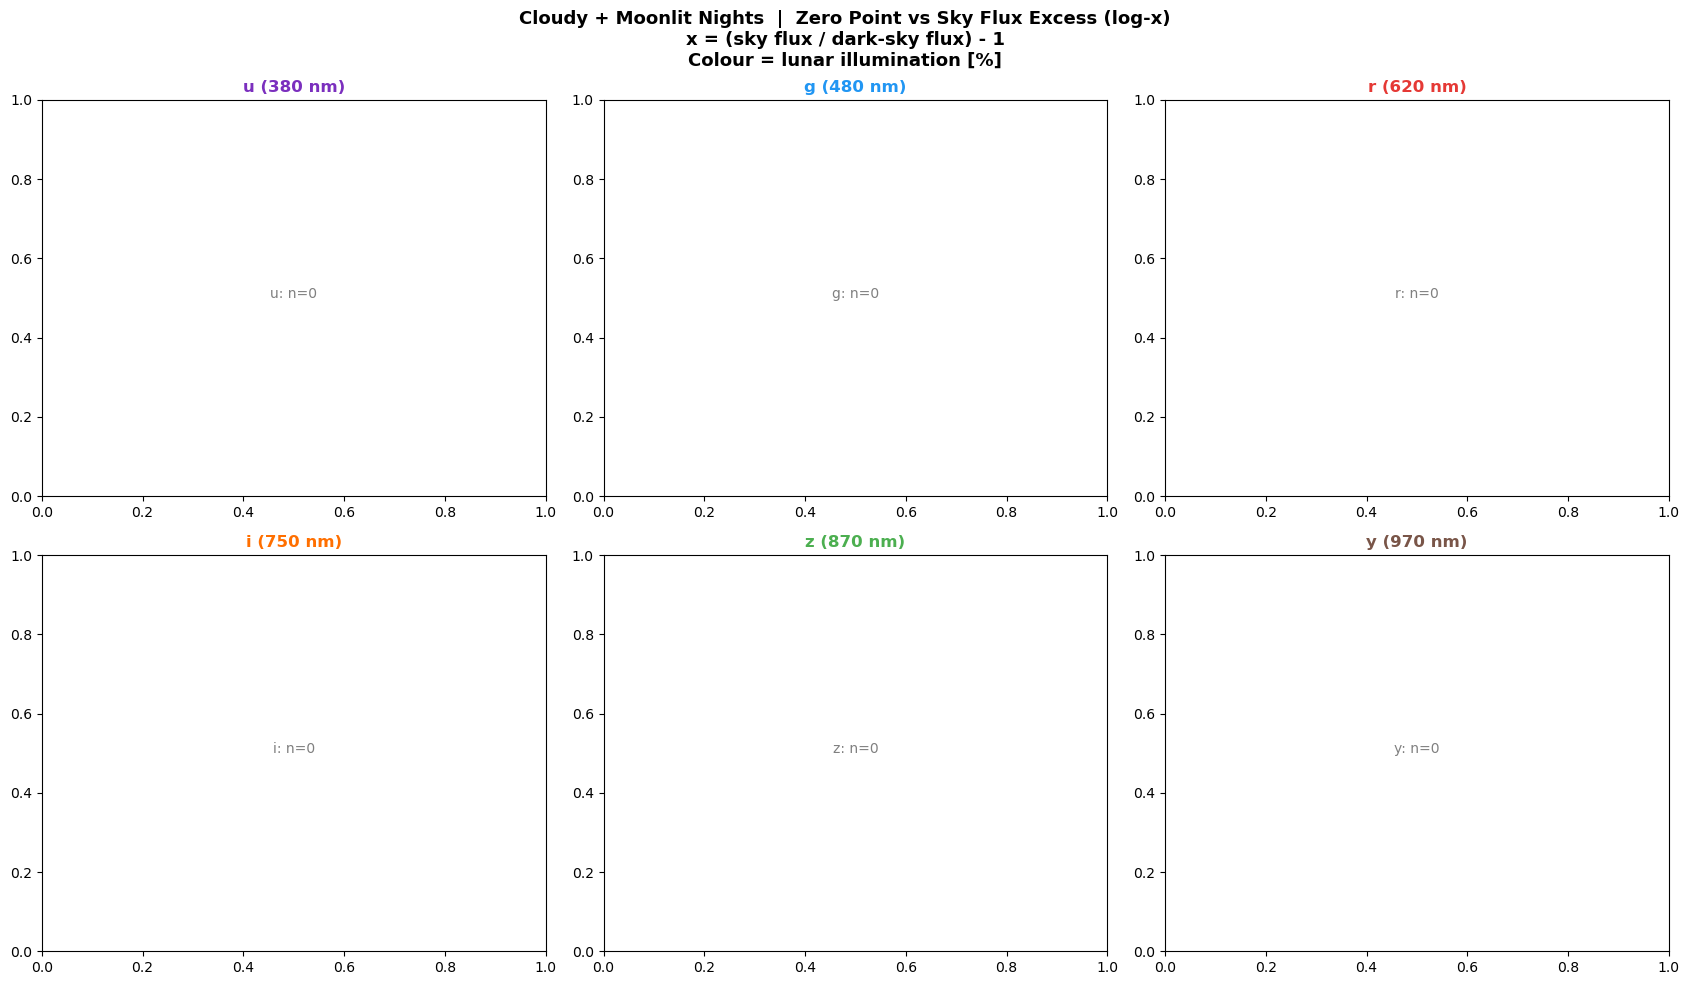

Saved: cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyFluxExcess_LOGX_cloudy_moonlit.png


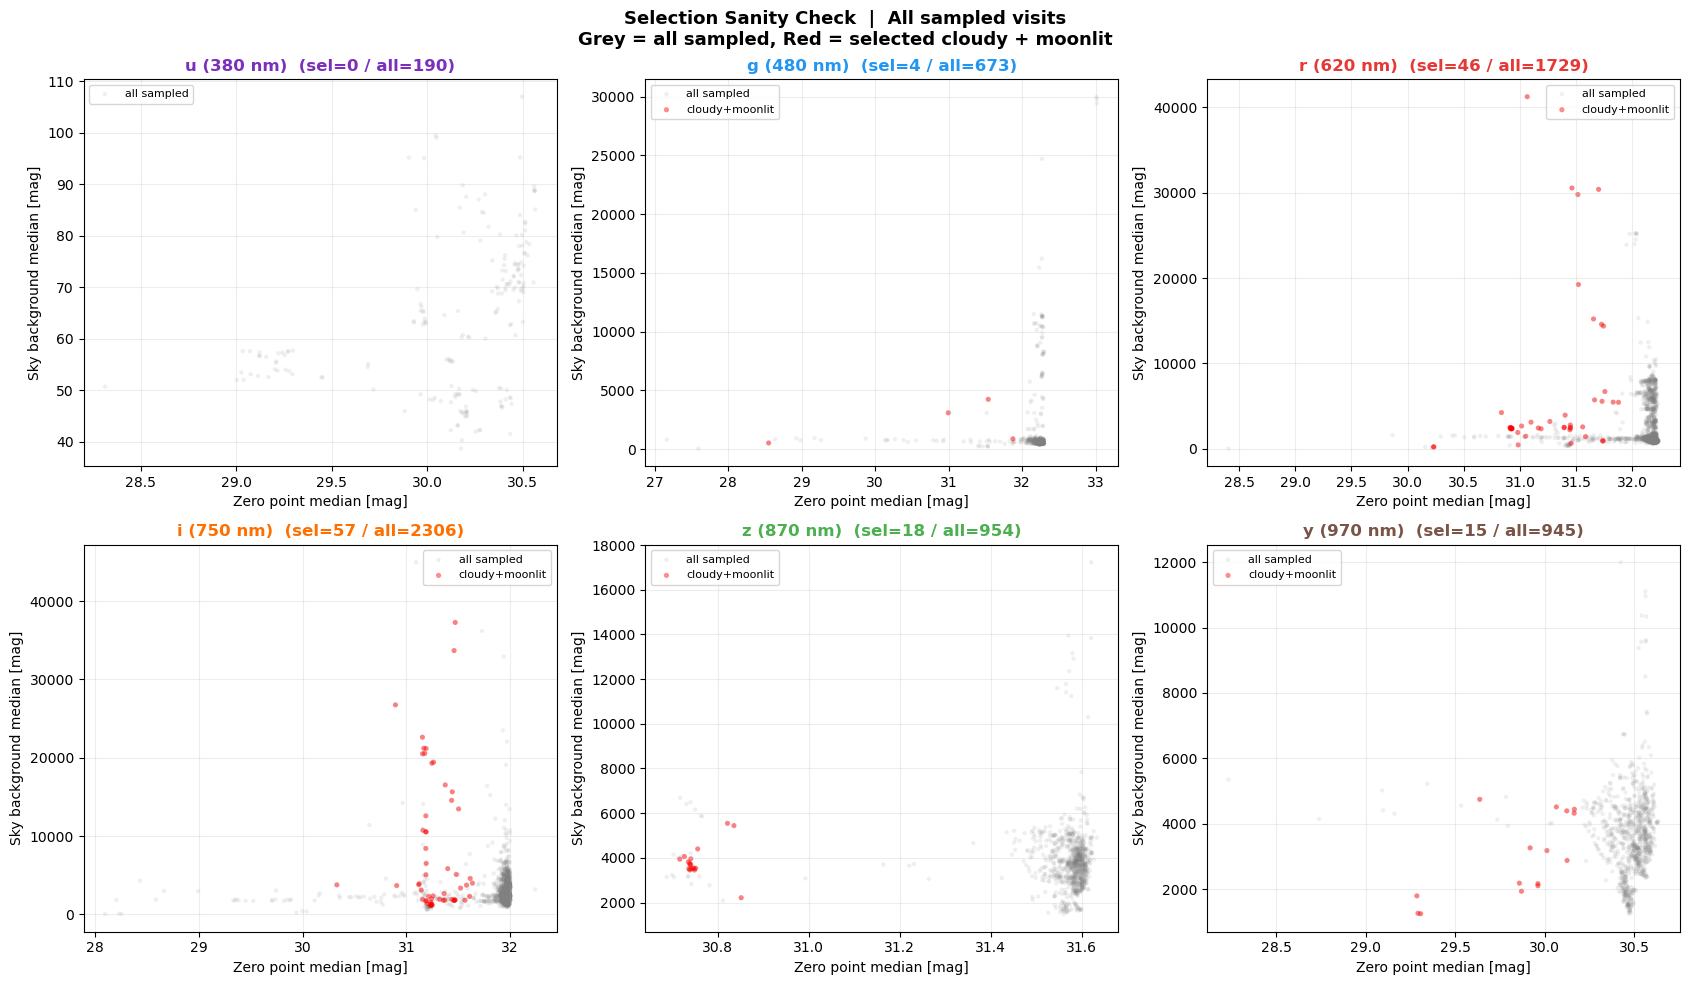

Saved: cloudy_moonlit_zeroPoint_only/selection_sanity_check_cloudy_moonlit.png

Step 5 / 5  —  Done
All outputs saved to: cloudy_moonlit_zeroPoint_only

Most important files:
  cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyBg_cloudy_moonlit.png
  cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyExcessMag_cloudy_moonlit.png
  cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyFluxExcess_LOGX_cloudy_moonlit.png
  cloudy_moonlit_zeroPoint_only/selection_sanity_check_cloudy_moonlit.png
  cloudy_moonlit_zeroPoint_only/cloudy_moonlit_zeroPoint_skyBg_diagnostics.csv
  cloudy_moonlit_zeroPoint_only/cloudy_moonlit_subset.csv


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cloudy + Moonlit Nights  —  ConsDB-only pipeline, single cell
#
# ONLY makes the "last plot" style diagnostics:
#   1) zero_point vs sky_bg
#   2) zero_point vs (sky_bg - dark-sky model)
#   3) zero_point vs sky flux excess (log-x)
#
# Key differences from earlier versions:
#   - NO DREAM
#   - ~25% sampling for speed
#   - NO upstream "photometric-ish" cuts
#   - Explicitly isolates cloudy + moonlit nights
#
# Data:
#   ConsDB HDF5  →  visits_20261024_20260219.h5
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Config ──────────────────────────────────────────────────────────────
CONSDB_H5       = "visits_20261024_20260219.h5"
OUTPUT_DIR      = "cloudy_moonlit_zeroPoint_only"
SAMPLE_FRAC     = 0.25
RANDOM_SEED     = 42
BANDS_TO_PLOT   = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N      = 10

# ---- cloudy + moonlit selection knobs ----
MOON_UP_ONLY          = True
MIN_MOON_ILLUM_PCT    = 25.0
MAX_MOON_SEP_DEG      = 180.0

# "Cloudy-ish" selector:
# We define cloudy-ish as visits with degraded transparency / zero point
# relative to the median of that band.
# Larger delta_zp = more attenuation / cloudier.
MIN_DELTA_ZP_CLOUDY   = 0.30   # mag below band median

# Optional extra selector: sky brighter than nominal dark sky by this much
MIN_SKY_EXCESS_MAG    = 0.25   # mag brighter than model (i.e. lower mag number)

# Whether to require BOTH cloudy criteria:
REQUIRE_BOTH_CLOUDY_TESTS = False

# Dark-sky reference model (very simple per-band baseline, mag/arcsec^2-ish)
# Adjust if you have better site-specific medians.
DARK_SKY_MODEL = {
    "u": 22.0,
    "g": 22.2,
    "r": 21.3,
    "i": 20.5,
    "z": 19.6,
    "y": 18.6,
}

# ── 1. Imports ─────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(
    lat=-30.244639*u.deg,
    lon=-70.749417*u.deg,
    height=2663.0*u.m
)

BAND_COLOR = {
    "u":"#7B2FBE", "g":"#2196F3", "r":"#E53935",
    "i":"#FF6F00", "z":"#4CAF50", "y":"#795548"
}

BAND_LABEL = {
    "u":"u (380 nm)", "g":"g (480 nm)", "r":"r (620 nm)",
    "i":"i (750 nm)", "z":"z (870 nm)", "y":"y (970 nm)"
}

# ── 2. Load ConsDB HDF5 ────────────────────────────────────────────────────
print("="*70)
print("Step 1 / 5  —  Loading ConsDB HDF5")
print("="*70)

consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Raw rows: {len(consdb):,}")
print(f"Columns (first 40): {list(consdb.columns[:40])}")

# ── time handling ──────────────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime()
                if pd.notna(m) and np.isfinite(m) else pd.NaT
            ),
            utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(
            lambda t: Time(t).mjd if pd.notna(t) else np.nan
        )
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── standardize columns ────────────────────────────────────────────────────
for want, cands in {
    "ra":   ["s_ra", "ra"],
    "dec":  ["s_dec", "dec"],
    "band": ["band", "physical_filter"],
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in [
    "ra","dec","mjd","altitude","azimuth","airmass",
    "sky_bg_median","zero_point_median","stats_mag_lim_median"
]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = (
        consdb["band"].astype(str)
        .str.extract(r'([ugrizy])', expand=False)
    )

# ── IMPORTANT: minimal cuts only ───────────────────────────────────────────
# Keep only what's absolutely necessary to make the diagnostic.
before_drop = len(consdb)

consdb = consdb.dropna(subset=[
    "exp_midpt", "mjd", "ra", "dec", "band",
    "zero_point_median", "sky_bg_median"
]).copy()

consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

print(f"\nRows after minimal required-column cuts: {len(consdb):,}")
print(f"Rows removed by minimal cuts: {before_drop - len(consdb):,}")

# ── sample AFTER minimal cuts ──────────────────────────────────────────────
consdb = consdb.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).copy()

print(f"\nSampled visits: {len(consdb):,} ({100*SAMPLE_FRAC:.1f}% of minimally filtered rows)")
print(f"Time range    : {consdb['exp_midpt'].min()}  →  {consdb['exp_midpt'].max()}")
print(f"Bands         : {sorted(consdb['band'].dropna().unique())}")

print(f"\nzero_point_median stats:\n{consdb['zero_point_median'].describe()}")
print(f"\nsky_bg_median stats:\n{consdb['sky_bg_median'].describe()}")

# ── 3. Compute moon geometry ───────────────────────────────────────────────
print("\n" + "="*70)
print("Step 2 / 5  —  Computing Moon geometry")
print("="*70)

results = []

for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])

    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    alt_deg = float(row["altitude"]) if pd.notna(row.get("altitude", np.nan)) else float(aa.alt.deg)
    az_deg  = float(row["azimuth"])  if pd.notna(row.get("azimuth", np.nan))  else float(aa.az.deg % 360)

    a1, a2 = np.radians(float(maa.alt.deg)), np.radians(alt_deg)
    daz = np.radians(float(maa.az.deg % 360) - az_deg)
    moon_sep = float(np.degrees(np.arccos(np.clip(
        np.sin(a1)*np.sin(a2) + np.cos(a1)*np.cos(a2)*np.cos(daz), -1, 1
    ))))

    results.append({
        "band": row["band"],
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "altitude": alt_deg,
        "moon_illum_pct": illum * 100.0,
        "moon_up": moon_up,
        "moon_sep": moon_sep,
        "sky_bg": float(row["sky_bg_median"]),
        "zero_point": float(row["zero_point_median"]),
        "mag_lim": float(row.get("stats_mag_lim_median", np.nan)),
        "airmass": float(row.get("airmass", np.nan)),
    })

    if len(results) % 2000 == 0:
        print(f"  ... processed {len(results):,} rows")

df = pd.DataFrame(results)

print(f"\nValid rows after geometry: {len(df):,}")
print(f"moon_illum_pct : {df['moon_illum_pct'].min():.1f} – {df['moon_illum_pct'].max():.1f} %")
print(f"zero_point     : {df['zero_point'].min():.3f} – {df['zero_point'].max():.3f}")
print(f"sky_bg         : {df['sky_bg'].min():.3f} – {df['sky_bg'].max():.3f}")

# ── 4. Build "cloudy + moonlit" diagnostics ───────────────────────────────
print("\n" + "="*70)
print("Step 3 / 5  —  Building cloudy + moonlit diagnostics")
print("="*70)

# Per-band medians to define "degraded transparency"
band_med_zp = df.groupby("band")["zero_point"].median().to_dict()

df["zp_band_median"] = df["band"].map(band_med_zp)
df["delta_zp_from_band_median"] = df["zp_band_median"] - df["zero_point"]
# positive = worse throughput / more attenuation / cloudier-ish

df["dark_sky_model"] = df["band"].map(DARK_SKY_MODEL)

# Magnitude difference:
# positive means observed sky is BRIGHTER than dark sky
# because lower mag number = brighter sky
df["sky_excess_mag"] = df["dark_sky_model"] - df["sky_bg"]

# Convert to relative flux excess over model:
# flux ratio = 10^(0.4 * delta_mag)
# where delta_mag = (model - observed)
df["sky_flux_ratio_to_model"] = 10**(0.4 * df["sky_excess_mag"])
df["sky_flux_excess_over_model"] = df["sky_flux_ratio_to_model"] - 1.0

# Boolean masks
moonlit_mask = (df["moon_illum_pct"] >= MIN_MOON_ILLUM_PCT) & (df["moon_sep"] <= MAX_MOON_SEP_DEG)
if MOON_UP_ONLY:
    moonlit_mask &= df["moon_up"]

cloudy_mask_zp = df["delta_zp_from_band_median"] >= MIN_DELTA_ZP_CLOUDY
cloudy_mask_sky = df["sky_excess_mag"] >= MIN_SKY_EXCESS_MAG

if REQUIRE_BOTH_CLOUDY_TESTS:
    cloudy_mask = cloudy_mask_zp & cloudy_mask_sky
else:
    cloudy_mask = cloudy_mask_zp | cloudy_mask_sky

df["is_moonlit"] = moonlit_mask
df["is_cloudyish"] = cloudy_mask
df["is_cloudy_moonlit"] = df["is_moonlit"] & df["is_cloudyish"]

print("Band median zero points used as cloudy baseline:")
for b in BANDS_TO_PLOT:
    if b in band_med_zp:
        print(f"  {b}: {band_med_zp[b]:.3f}")

print("\nSelection summary:")
print(f"  Total rows                     : {len(df):,}")
print(f"  Moonlit rows                   : {df['is_moonlit'].sum():,}")
print(f"  Cloudy-ish rows                : {df['is_cloudyish'].sum():,}")
print(f"  Cloudy + moonlit rows          : {df['is_cloudy_moonlit'].sum():,}")

for b in BANDS_TO_PLOT:
    n_all = (df["band"] == b).sum()
    n_sel = ((df["band"] == b) & df["is_cloudy_moonlit"]).sum()
    print(f"    {b}: {n_sel:5d} / {n_all:5d}")

# Save full diagnostic table
csv_path = os.path.join(OUTPUT_DIR, "cloudy_moonlit_zeroPoint_skyBg_diagnostics.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved full diagnostic table: {csv_path}")

# Also save just the selected cloudy+moonlit subset
sel = df[df["is_cloudy_moonlit"]].copy()
csv_sel_path = os.path.join(OUTPUT_DIR, "cloudy_moonlit_subset.csv")
sel.to_csv(csv_sel_path, index=False)
print(f"Saved selected subset: {csv_sel_path}")

# ── 5. Plot ONLY the "last plot" family ────────────────────────────────────
print("\n" + "="*70)
print("Step 4 / 5  —  Plotting ONLY zero_point vs sky diagnostics")
print("="*70)

def _finish_ax(ax, title, xlabel, ylabel, bc):
    ax.set_title(title, weight="bold", color=bc)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.22)

# -------------------------------------------------------------------------
# FIG 1: zero_point vs raw sky background (selected cloudy + moonlit only)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Cloudy + Moonlit Nights  |  Zero Point vs Sky Background\n"
    "Colour = lunar illumination [%]",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = sel[sel["band"] == band].dropna(subset=["zero_point","sky_bg"])
    bc  = BAND_COLOR[band]

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue

    sc = ax.scatter(
        sub["zero_point"], sub["sky_bg"],
        c=sub["moon_illum_pct"], cmap="plasma",
        vmin=0, vmax=100, s=14, alpha=0.45, edgecolors="none"
    )

    _finish_ax(
        ax,
        f"{BAND_LABEL.get(band,band)}  (n={len(sub)})",
        "Zero point median [mag]",
        "Sky background median [mag]",
        bc
    )
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p1 = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyBg_cloudy_moonlit.png")
plt.savefig(p1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p1}")

# -------------------------------------------------------------------------
# FIG 2: zero_point vs sky brightness excess over model (mag-space)
# positive sky_excess_mag = brighter sky than model
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Cloudy + Moonlit Nights  |  Zero Point vs Sky Brightness Excess\n"
    "x = dark_sky_model - observed_sky_bg  [mag]\n"
    "Colour = lunar illumination [%]",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = sel[sel["band"] == band].dropna(subset=["zero_point","sky_excess_mag"])
    bc  = BAND_COLOR[band]

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue

    sc = ax.scatter(
        sub["sky_excess_mag"], sub["zero_point"],
        c=sub["moon_illum_pct"], cmap="plasma",
        vmin=0, vmax=100, s=14, alpha=0.45, edgecolors="none"
    )

    _finish_ax(
        ax,
        f"{BAND_LABEL.get(band,band)}  (n={len(sub)})",
        "Sky brightness excess over model [mag]",
        "Zero point median [mag]",
        bc
    )
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p2 = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyExcessMag_cloudy_moonlit.png")
plt.savefig(p2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p2}")

# -------------------------------------------------------------------------
# FIG 3: log-x version using FLUX excess (physically sensible for log axis)
# x = (sky flux / dark-sky flux) - 1
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Cloudy + Moonlit Nights  |  Zero Point vs Sky Flux Excess (log-x)\n"
    "x = (sky flux / dark-sky flux) - 1\n"
    "Colour = lunar illumination [%]",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = sel[sel["band"] == band].dropna(subset=["zero_point","sky_flux_excess_over_model"])
    sub = sub[sub["sky_flux_excess_over_model"] > 0].copy()
    bc  = BAND_COLOR[band]

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue

    sc = ax.scatter(
        sub["sky_flux_excess_over_model"], sub["zero_point"],
        c=sub["moon_illum_pct"], cmap="plasma",
        vmin=0, vmax=100, s=14, alpha=0.45, edgecolors="none"
    )

    ax.set_xscale("log")
    _finish_ax(
        ax,
        f"{BAND_LABEL.get(band,band)}  (n={len(sub)})",
        "Sky flux excess over model [relative, log scale]",
        "Zero point median [mag]",
        bc
    )
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p3 = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyFluxExcess_LOGX_cloudy_moonlit.png")
plt.savefig(p3, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p3}")

# -------------------------------------------------------------------------
# FIG 4: sanity-check panel showing what got selected vs not
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Selection Sanity Check  |  All sampled visits\n"
    "Grey = all sampled, Red = selected cloudy + moonlit",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    allb = df[df["band"] == band].dropna(subset=["zero_point","sky_bg"])
    sub  = sel[sel["band"] == band].dropna(subset=["zero_point","sky_bg"])
    bc   = BAND_COLOR[band]

    if len(allb) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(allb)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue

    ax.scatter(allb["zero_point"], allb["sky_bg"],
               s=10, alpha=0.12, color="gray", edgecolors="none", label="all sampled")
    if len(sub) > 0:
        ax.scatter(sub["zero_point"], sub["sky_bg"],
                   s=14, alpha=0.45, color="red", edgecolors="none", label="cloudy+moonlit")

    _finish_ax(
        ax,
        f"{BAND_LABEL.get(band,band)}  (sel={len(sub)} / all={len(allb)})",
        "Zero point median [mag]",
        "Sky background median [mag]",
        bc
    )
    ax.legend(fontsize=8)

plt.tight_layout()
p4 = os.path.join(OUTPUT_DIR, "selection_sanity_check_cloudy_moonlit.png")
plt.savefig(p4, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p4}")

print("\n" + "="*70)
print("Step 5 / 5  —  Done")
print("="*70)
print(f"All outputs saved to: {OUTPUT_DIR}")
print("\nMost important files:")
print(f"  {p1}")
print(f"  {p2}")
print(f"  {p3}")
print(f"  {p4}")
print(f"  {csv_path}")
print(f"  {csv_sel_path}")

Loading ConsDB
Raw rows: 29933
Columns (first 40): ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason', 'physical_filter', 'pressure', 's_dec', 's_ra', 's_region', 'scheduler_note', 'science_program', 'seq_num', 'shut_time', 'simulated']

After minimal cuts + sampling: 6797 rows
Bands: ['g', 'i', 'r', 'u', 'y', 'z']

Computing moon illumination
  processed index 24000

Rows after cloudy/moonlit filtering: 2977
        band  zero_point_median  sky_bg_median  moon_illum_pct
count   2977        2977.000000    2977.000000     2977.000000
unique     5                NaN            NaN             NaN
top        i                NaN        

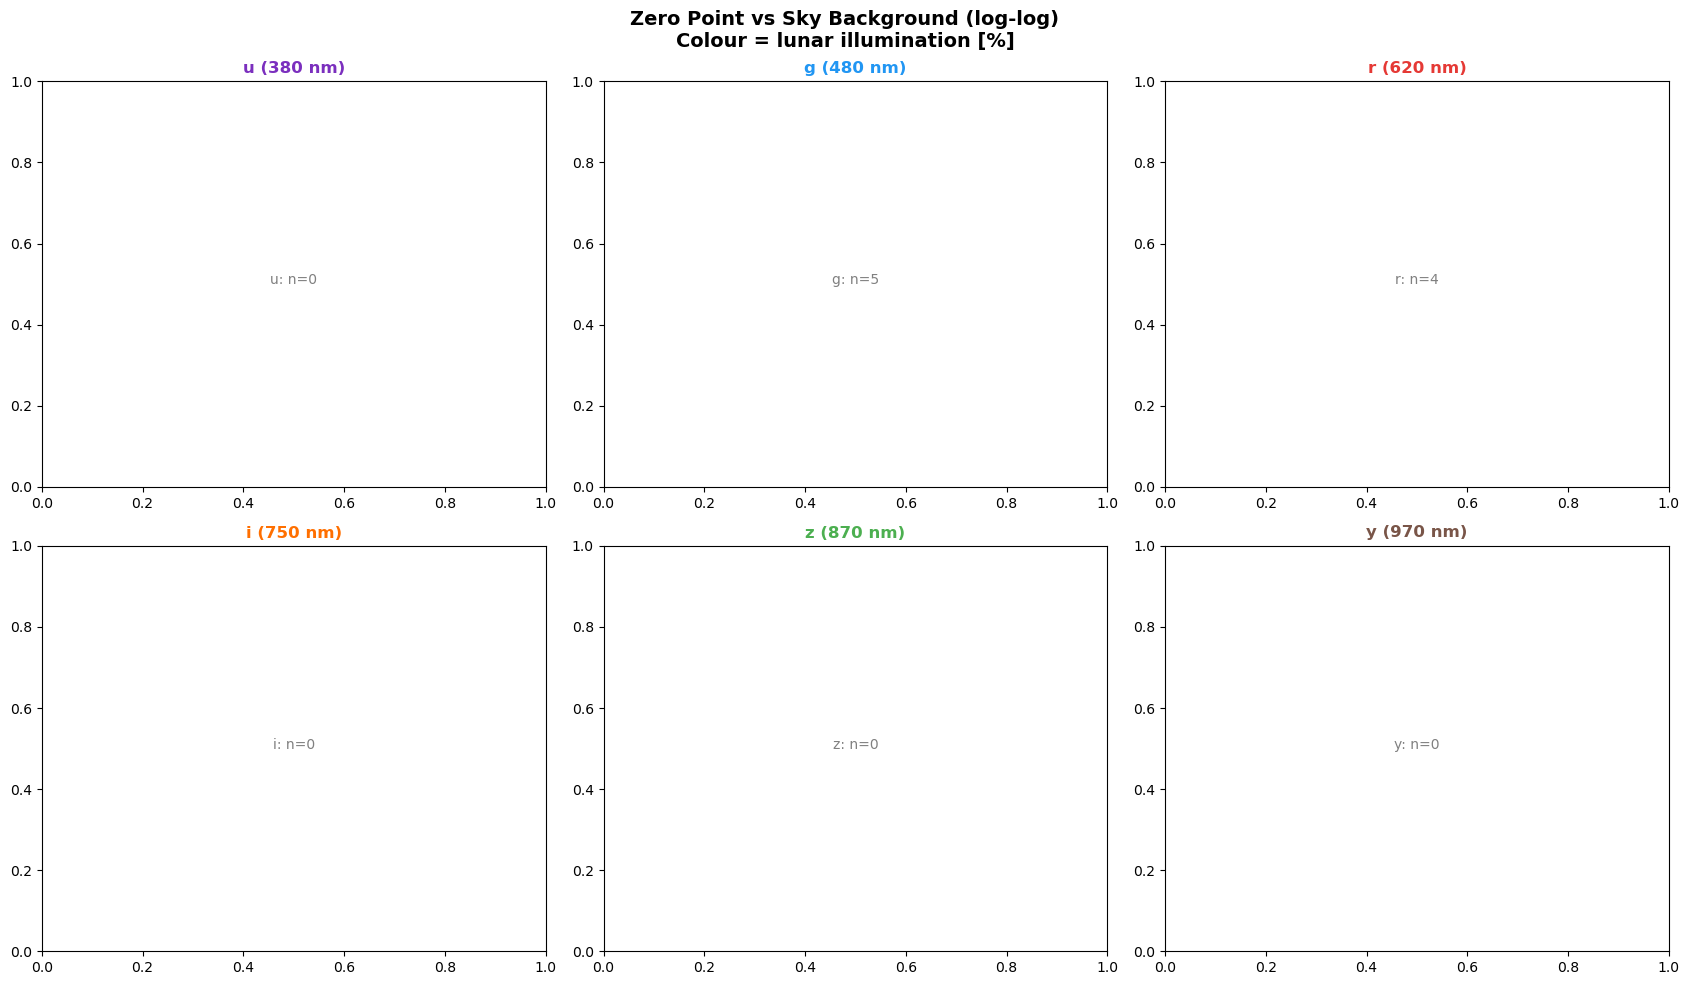

Saved: moon_plots_consdb_only/zeroPoint_vs_skyBg_LOGLOG.png

Done.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Zero Point vs Sky Background (LOG-LOG)
# ConsDB-only, stripped standalone
#
# X-axis : zero_point_median  -> flux-like throughput scale
# Y-axis : sky_bg_median      -> flux-like sky brightness scale
# Colour : lunar illumination [%]
#
# Also optionally plots:
#   (sky_bg_median - model_sky_bg) in flux-like residual space
# if a model/background reference column exists.
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Config ──────────────────────────────────────────────────────────────
CONSDB_H5       = "visits_20261024_20260219.h5"
OUTPUT_DIR      = "moon_plots_consdb_only"
SAMPLE_FRAC     = 0.25
RANDOM_SEED     = 42
BANDS_TO_PLOT   = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N      = 10

# Cloudy + moonlit selection
MOONLIT_ONLY    = True
MIN_MOON_ILLUM  = 30.0      # percent
MIN_CLOUDY_SKY  = None      # e.g. 20.5 if you want "bright sky only" cut in mag units

# ── 1. Imports ─────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(
    lat=-30.244639*u.deg,
    lon=-70.749417*u.deg,
    height=2663.0*u.m
)

BAND_COLOR = {
    "u":"#7B2FBE", "g":"#2196F3", "r":"#E53935",
    "i":"#FF6F00", "z":"#4CAF50", "y":"#795548"
}
BAND_LABEL = {
    "u":"u (380 nm)", "g":"g (480 nm)", "r":"r (620 nm)",
    "i":"i (750 nm)", "z":"z (870 nm)", "y":"y (970 nm)"
}

# ── 2. Load ConsDB ─────────────────────────────────────────────────────────
print("="*60)
print("Loading ConsDB")
print("="*60)

consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Raw rows: {len(consdb)}")
print(f"Columns (first 40): {list(consdb.columns[:40])}")

# ── time handling ──────────────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime()
                if pd.notna(m) and np.isfinite(m) else pd.NaT
            ),
            utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(
            lambda t: Time(t).mjd if pd.notna(t) else np.nan
        )
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── standardize columns ────────────────────────────────────────────────────
for want, cands in {
    "ra":   ["s_ra", "ra"],
    "dec":  ["s_dec", "dec"],
    "band": ["band", "physical_filter"],
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in [
    "ra", "dec", "mjd",
    "sky_bg_median", "zero_point_median",
    "sky_model_median", "sky_brightness_model",
    "model_sky_bg", "predicted_sky_bg"
]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = (
        consdb["band"].astype(str)
        .str.extract(r'([ugrizy])', expand=False)
    )

# ── IMPORTANT: minimal cuts only ───────────────────────────────────────────
consdb = consdb.dropna(subset=[
    "exp_midpt", "mjd", "ra", "dec", "band",
    "zero_point_median", "sky_bg_median"
]).copy()

consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

# sample only after basic validity cuts
consdb = consdb.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).copy()

print(f"\nAfter minimal cuts + sampling: {len(consdb)} rows")
print(f"Bands: {sorted(consdb['band'].dropna().unique())}")

# ── 3. Compute moon illumination ───────────────────────────────────────────
print("\n" + "="*60)
print("Computing moon illumination")
print("="*60)

moon_illum = []
moon_up = []

for i, row in consdb.iterrows():
    t = Time(float(row["mjd"]), format="mjd")
    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0

    moon_illum.append(illum * 100.0)
    moon_up.append(bool(maa.alt.deg > 0))

    if (i % 2000) == 0 and i > 0:
        print(f"  processed index {i}")

consdb["moon_illum_pct"] = moon_illum
consdb["moon_up"] = moon_up

# ── 4. Cloudy + moonlit filter ─────────────────────────────────────────────
df = consdb.copy()

if MOONLIT_ONLY:
    df = df[(df["moon_up"]) & (df["moon_illum_pct"] >= MIN_MOON_ILLUM)].copy()

if MIN_CLOUDY_SKY is not None:
    # brighter sky = smaller mag value
    df = df[df["sky_bg_median"] <= MIN_CLOUDY_SKY].copy()

print(f"\nRows after cloudy/moonlit filtering: {len(df)}")
print(df[["band", "zero_point_median", "sky_bg_median", "moon_illum_pct"]].describe(include="all"))

# ── 5. Convert magnitudes to flux-like linear units ────────────────────────
# zero point: larger mag => more throughput, so use +0.4
df["zp_flux_like"] = 10**(0.4 * df["zero_point_median"])

# sky background: brighter sky means smaller mag, so use -0.4
df["sky_flux_like"] = 10**(-0.4 * df["sky_bg_median"])

# ── optional: sky minus model ──────────────────────────────────────────────
model_candidates = [
    "sky_model_median",
    "sky_brightness_model",
    "model_sky_bg",
    "predicted_sky_bg"
]
model_col = next((c for c in model_candidates if c in df.columns), None)

if model_col is not None:
    df["sky_bg_minus_model_mag"] = df["sky_bg_median"] - df[model_col]
    df["sky_model_flux_like"] = 10**(-0.4 * df[model_col])
    df["sky_excess_flux_like"] = df["sky_flux_like"] - df["sky_model_flux_like"]
    print(f"\nUsing model sky column: {model_col}")
else:
    print("\nNo model sky column found; residual plot will be skipped.")

# ── keep only positive values for log axes ─────────────────────────────────
df = df[(df["zp_flux_like"] > 0) & (df["sky_flux_like"] > 0)].copy()

# ── 6. Plot 1: log-log zero point vs sky background ───────────────────────
print("\n" + "="*60)
print("Plotting: log-log zero point vs sky background")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Zero Point vs Sky Background (log-log)\n"
    "Colour = lunar illumination [%]",
    fontsize=14, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = df[df["band"] == band].dropna(subset=["zp_flux_like", "sky_flux_like"])
    bc = BAND_COLOR[band]

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL[band], weight="bold", color=bc)
        continue

    sc = ax.scatter(
        sub["zp_flux_like"],
        sub["sky_flux_like"],
        c=sub["moon_illum_pct"],
        cmap="plasma",
        vmin=0, vmax=100,
        s=12, alpha=0.4, edgecolors="none"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{BAND_LABEL[band]}  (n={len(sub)})", weight="bold", color=bc)
    ax.set_xlabel("Photometric throughput scale ∝ 10^(0.4 × zero point)", fontsize=9)
    ax.set_ylabel("Sky brightness scale ∝ 10^(-0.4 × sky bg)", fontsize=9)
    ax.grid(alpha=0.25, which="both")
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p1 = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyBg_LOGLOG.png")
plt.savefig(p1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p1}")

# ── 7. Plot 2: log-log sky excess over model (if available) ───────────────
if model_col is not None:
    dfr = df.dropna(subset=["zp_flux_like", "sky_excess_flux_like"]).copy()
    dfr = dfr[dfr["sky_excess_flux_like"] > 0].copy()

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle(
        "Zero Point vs Sky Brightness Excess Above Model (log-log)\n"
        "Colour = lunar illumination [%]",
        fontsize=14, weight="bold"
    )

    for ax, band in zip(axes.flat, BANDS_TO_PLOT):
        sub = dfr[dfr["band"] == band]
        bc = BAND_COLOR[band]

        if len(sub) < PLOT_MIN_N:
            ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                    transform=ax.transAxes, ha="center", color="gray")
            ax.set_title(BAND_LABEL[band], weight="bold", color=bc)
            continue

        sc = ax.scatter(
            sub["zp_flux_like"],
            sub["sky_excess_flux_like"],
            c=sub["moon_illum_pct"],
            cmap="plasma",
            vmin=0, vmax=100,
            s=12, alpha=0.4, edgecolors="none"
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"{BAND_LABEL[band]}  (n={len(sub)})", weight="bold", color=bc)
        ax.set_xlabel("Photometric throughput scale ∝ 10^(0.4 × zero point)", fontsize=9)
        ax.set_ylabel("Sky excess above model ∝ flux", fontsize=9)
        ax.grid(alpha=0.25, which="both")
        plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

    plt.tight_layout()
    p2 = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyExcessAboveModel_LOGLOG.png")
    plt.savefig(p2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {p2}")

print("\nDone.")

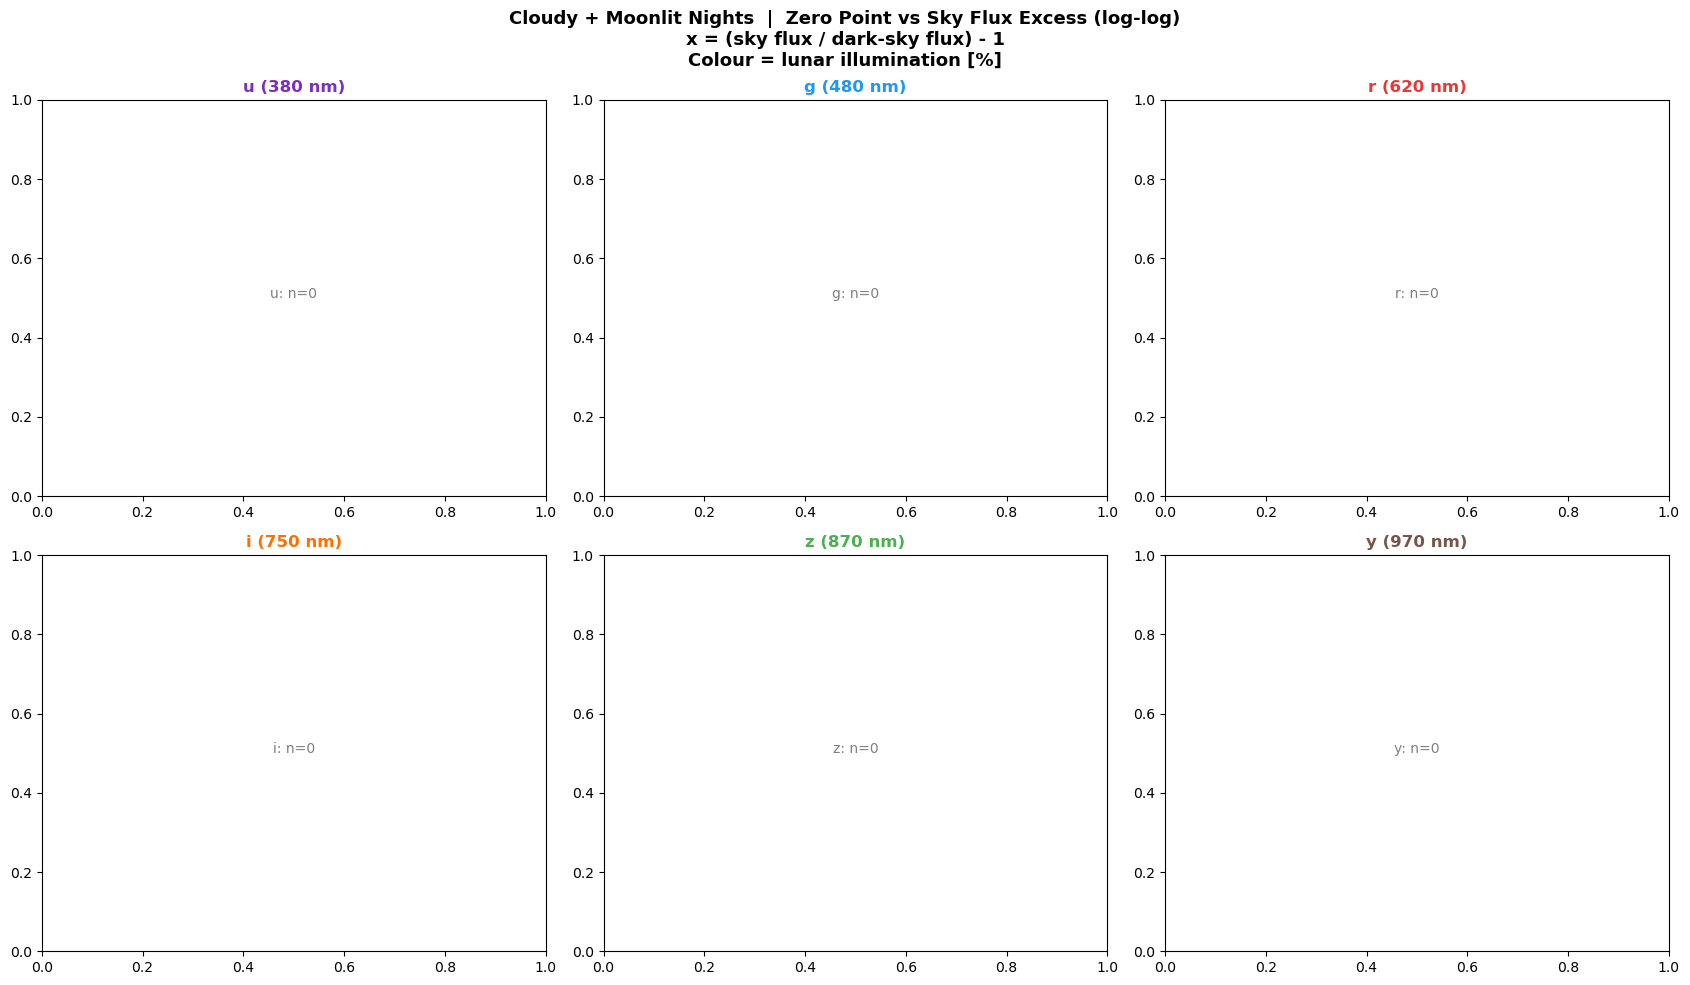

Saved: cloudy_moonlit_zeroPoint_only/zeroPoint_vs_skyFluxExcess_LOGLOG_cloudy_moonlit.png


In [5]:
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "cloudy_moonlit_zeroPoint_only"
BANDS_TO_PLOT = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N = 10

BAND_COLOR = {
    "u":"#7B2FBE", "g":"#2196F3", "r":"#E53935",
    "i":"#FF6F00", "z":"#4CAF50", "y":"#795548"
}

BAND_LABEL = {
    "u":"u (380 nm)", "g":"g (480 nm)", "r":"r (620 nm)",
    "i":"i (750 nm)", "z":"z (870 nm)", "y":"y (970 nm)"
}

def _finish_ax(ax, title, xlabel, ylabel, bc):
    ax.set_title(title, weight="bold", color=bc)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.22)

# sel = dataframe of selected cloudy + moonlit visits (already computed)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle(
    "Cloudy + Moonlit Nights  |  Zero Point vs Sky Flux Excess (log-log)\n"
    "x = (sky flux / dark-sky flux) - 1\n"
    "Colour = lunar illumination [%]",
    fontsize=13, weight="bold"
)

for ax, band in zip(axes.flat, BANDS_TO_PLOT):
    sub = sel[sel["band"] == band].dropna(subset=["zero_point","sky_flux_excess_over_model"])
    sub = sub[sub["sky_flux_excess_over_model"] > 0].copy()
    bc  = BAND_COLOR[band]

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: n={len(sub)}",
                transform=ax.transAxes, ha="center", color="gray")
        ax.set_title(BAND_LABEL.get(band, band), weight="bold", color=bc)
        continue

    sc = ax.scatter(
        sub["sky_flux_excess_over_model"], sub["zero_point"],
        c=sub["moon_illum_pct"], cmap="plasma",
        vmin=0, vmax=100, s=14, alpha=0.45, edgecolors="none"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    _finish_ax(
        ax,
        f"{BAND_LABEL.get(band,band)}  (n={len(sub)})",
        "Sky flux excess over model [relative, log scale]",
        "Zero point median [mag]",
        bc
    )
    plt.colorbar(sc, ax=ax, label="Moon illum %", fraction=0.046, pad=0.04)

plt.tight_layout()
p_loglog = os.path.join(OUTPUT_DIR, "zeroPoint_vs_skyFluxExcess_LOGLOG_cloudy_moonlit.png")
plt.savefig(p_loglog, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p_loglog}")

Loading ConsDB HDF5 ...
Rows: 29933, Columns: ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason']
Computing Moon geometry ...
Computed Moon geometry for 27189 rows


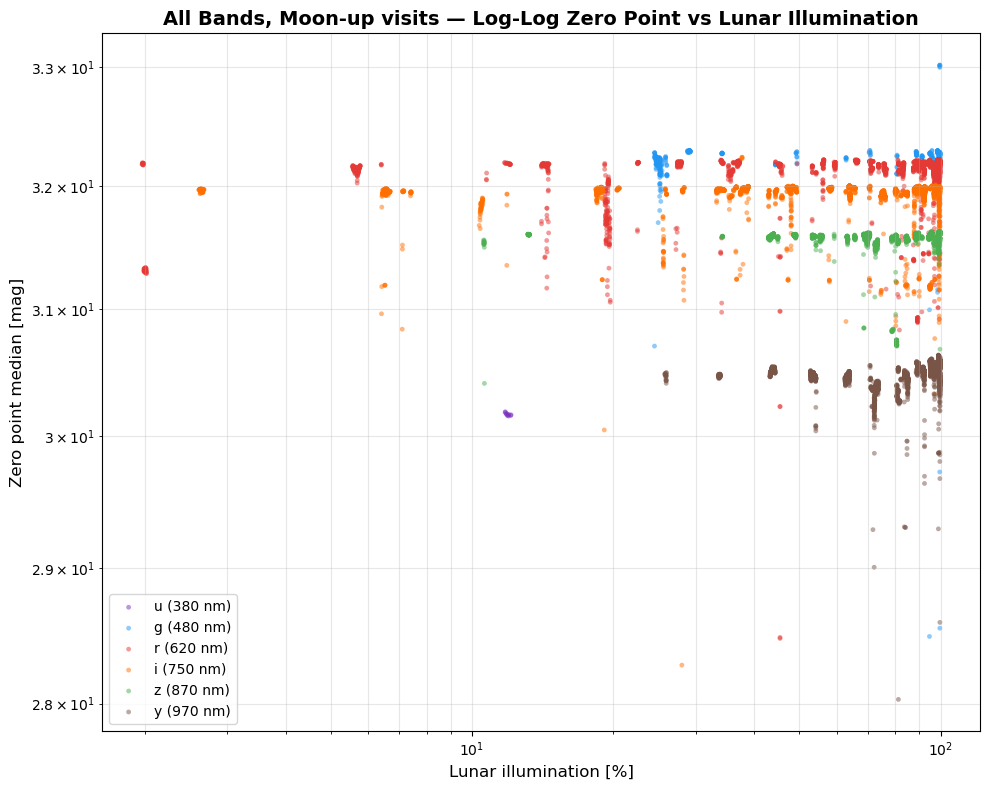

Saved log-log plot: moon_plots_loglog_all/loglog_zeroPoint_allBands.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Photometry  —  ConsDB-only, log-log all data
#
# X-axis : lunar illumination [%]
# Y-axis : zero_point_median [mag]
# Colour : sky_bg_median [mag]
# Full dataset, no sampling
# ═══════════════════════════════════════════════════════════════════════════

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────
CONSDB_H5  = "visits_20261024_20260219.h5"
OUTPUT_DIR = "moon_plots_loglog_all"
BANDS_TO_PLOT = ["u","g","r","i","z","y"]
PLOT_MIN_N = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)

BAND_COLOR = {"u":"#7B2FBE","g":"#2196F3","r":"#E53935",
              "i":"#FF6F00","z":"#4CAF50","y":"#795548"}
BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

# ── Load HDF5 ─────────────────────────────────────────────────────────────
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Rows: {len(consdb)}, Columns: {list(consdb.columns[:30])}")

# ── MJD / time handling ───────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime() if pd.notna(m) and np.isfinite(m) else pd.NaT
            ), utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(lambda t: Time(t).mjd if pd.notna(t) else np.nan)
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── Standardise column names ──────────────────────────────────────────────
for want, cands in {"ra":["s_ra","ra"], "dec":["s_dec","dec"], "band":["band","physical_filter"]}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in ["ra","dec","mjd","altitude","azimuth","airmass",
            "sky_bg_median","zero_point_median","stats_mag_lim_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r'([ugrizy])', expand=False)

consdb = consdb.dropna(subset=["exp_midpt","mjd","ra","dec","band","zero_point_median","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

# ── Compute Moon geometry ─────────────────────────────────────────────────
print("Computing Moon geometry ...")
results = []

for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])
    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_body("sun",  t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(sun).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    alt_deg = float(row["altitude"]) if pd.notna(row.get("altitude", np.nan)) else float(aa.alt.deg)
    az_deg  = float(row["azimuth"])  if pd.notna(row.get("azimuth", np.nan))  else float(aa.az.deg % 360)

    a1, a2 = np.radians(float(maa.alt.deg)), np.radians(alt_deg)
    daz = np.radians(float(maa.az.deg % 360) - az_deg)
    moon_sep = float(np.degrees(np.arccos(np.clip(
        np.sin(a1)*np.sin(a2) + np.cos(a1)*np.cos(a2)*np.cos(daz), -1, 1
    ))))

    results.append({
        "band": row["band"],
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "altitude": alt_deg,
        "moon_illum_pct": illum*100,
        "moon_up": moon_up,
        "moon_sep": moon_sep,
        "sky_bg": float(row["sky_bg_median"]),
        "zero_point": float(row["zero_point_median"]),
        "mag_lim": float(row.get("stats_mag_lim_median", np.nan)),
    })

df = pd.DataFrame(results)
print(f"Computed Moon geometry for {len(df)} rows")

# ── Log-log scatter plot, all bands, moon-up only ─────────────────────────
bands_present = [b for b in BANDS_TO_PLOT if b in df["band"].unique()]
clim_low  = float(np.nanpercentile(df["sky_bg"], 5))
clim_high = float(np.nanpercentile(df["sky_bg"], 95))
cnorm = Normalize(vmin=clim_low, vmax=clim_high)
cmap  = "viridis"

fig, ax = plt.subplots(figsize=(10,8))
for band in bands_present:
    sub = df[(df["band"]==band) & (df["moon_up"])]
    if len(sub) < PLOT_MIN_N:
        continue
    ax.scatter(sub["moon_illum_pct"], sub["zero_point"],
               color=BAND_COLOR[band], label=BAND_LABEL[band],
               s=12, alpha=0.5, edgecolors="none")

ax.set_xlabel("Lunar illumination [%]", fontsize=12)
ax.set_ylabel("Zero point median [mag]", fontsize=12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("All Bands, Moon-up visits — Log-Log Zero Point vs Lunar Illumination", fontsize=14, weight="bold")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
outpath = os.path.join(OUTPUT_DIR, "loglog_zeroPoint_allBands.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved log-log plot: {outpath}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Photometry — All Bands Subplots, Sky background in counts vs Zero point
# X-axis: zero_point_median [mag]
# Y-axis: sky_bg_median [counts]
# Colour: lunar illumination [%]
# Moon-up only
# ═══════════════════════════════════════════════════════════════════════════

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")

CONSDB_H5  = "visits_20261024_20260219.h5"
OUTPUT_DIR = "moon_plots_subplots"
BANDS_TO_PLOT = ["u","g","r","i","z","y"]
PLOT_MIN_N = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)

BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

# ── Load HDF5 ─────────────────────────────────────────────────────────────
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Rows: {len(consdb)}, Columns: {list(consdb.columns[:30])}")

# ── MJD / time handling ───────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime() if pd.notna(m) and np.isfinite(m) else pd.NaT
            ), utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(lambda t: Time(t).mjd if pd.notna(t) else np.nan)
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── Standardise column names ──────────────────────────────────────────────
for want, cands in {"ra":["s_ra","ra"], "dec":["s_dec","dec"], "band":["band","physical_filter"]}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in ["ra","dec","mjd","altitude","azimuth","airmass",
            "sky_bg_median","zero_point_median","stats_mag_lim_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r'([ugrizy])', expand=False)

consdb = consdb.dropna(subset=["exp_midpt","mjd","ra","dec","band","zero_point_median","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

# ── Compute Moon geometry ─────────────────────────────────────────────────
print("Computing Moon geometry ...")
results = []

for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])
    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    moon = get_body("moon", t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(get_body("sun", t, location=RUBIN_LOC)).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    alt_deg = float(row["altitude"]) if pd.notna(row.get("altitude", np.nan)) else float(aa.alt.deg)
    az_deg  = float(row["azimuth"])  if pd.notna(row.get("azimuth", np.nan))  else float(aa.az.deg % 360)

    results.append({
        "band": row["band"],
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "altitude": alt_deg,
        "moon_illum_pct": illum*100,
        "moon_up": moon_up,
        "sky_bg": float(row["sky_bg_median"]),        # still in counts
        "zero_point": float(row["zero_point_median"]),
    })

df = pd.DataFrame(results)
df = df[df["moon_up"]].copy()
print(f"Computed Moon geometry for {len(df)} moon-up rows")

# ── Subplots per band ─────────────────────────────────────────────────────
n_bands = len(BANDS_TO_PLOT)
fig, axes = plt.subplots(n_bands, 1, figsize=(10, 3*n_bands), sharex=True)

clim_low  = float(np.nanpercentile(df["moon_illum_pct"], 5))
clim_high = float(np.nanpercentile(df["moon_illum_pct"], 95))
norm = Normalize(vmin=clim_low, vmax=clim_high)
cmap = plt.get_cmap("viridis")

for ax, band in zip(axes, BANDS_TO_PLOT):
    sub = df[df["band"]==band]
    if len(sub) < PLOT_MIN_N:
        ax.set_visible(False)
        continue
    sc = ax.scatter(sub["zero_point"], sub["sky_bg"],
                    c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                    s=12, alpha=0.7, edgecolors="none")
    ax.set_ylabel(f"{BAND_LABEL[band]} sky [counts]", fontsize=12)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Zero point median [mag]", fontsize=12)

# Colourbar
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, orientation="vertical")
cbar.set_label("Lunar illumination [%]", fontsize=12)

fig.suptitle("Moon-up visits: Sky background [counts] vs Zero point median [mag]", fontsize=14, weight="bold")
plt.tight_layout(rect=[0,0,1,0.97])
outpath = os.path.join(OUTPUT_DIR, "subplots_skyBg_vs_zeroPoint.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {outpath}")

Loading ConsDB HDF5 ...
Rows: 29933, Columns: ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason']
Computing Moon geometry ...


Loading ConsDB HDF5 ...
Rows: 29933, Columns: ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing', 'emulated', 'exp_midpt', 'exp_midpt_mjd', 'exp_time', 'exposure_name', 'focus_z', 'group_id', 'humidity', 'img_type', 'max_index', 'obs_end', 'obs_end_mjd', 'obs_start', 'obs_start_mjd', 'observation_reason']
Computing Moon geometry ...
Computed Moon geometry for 13089 moon-up rows


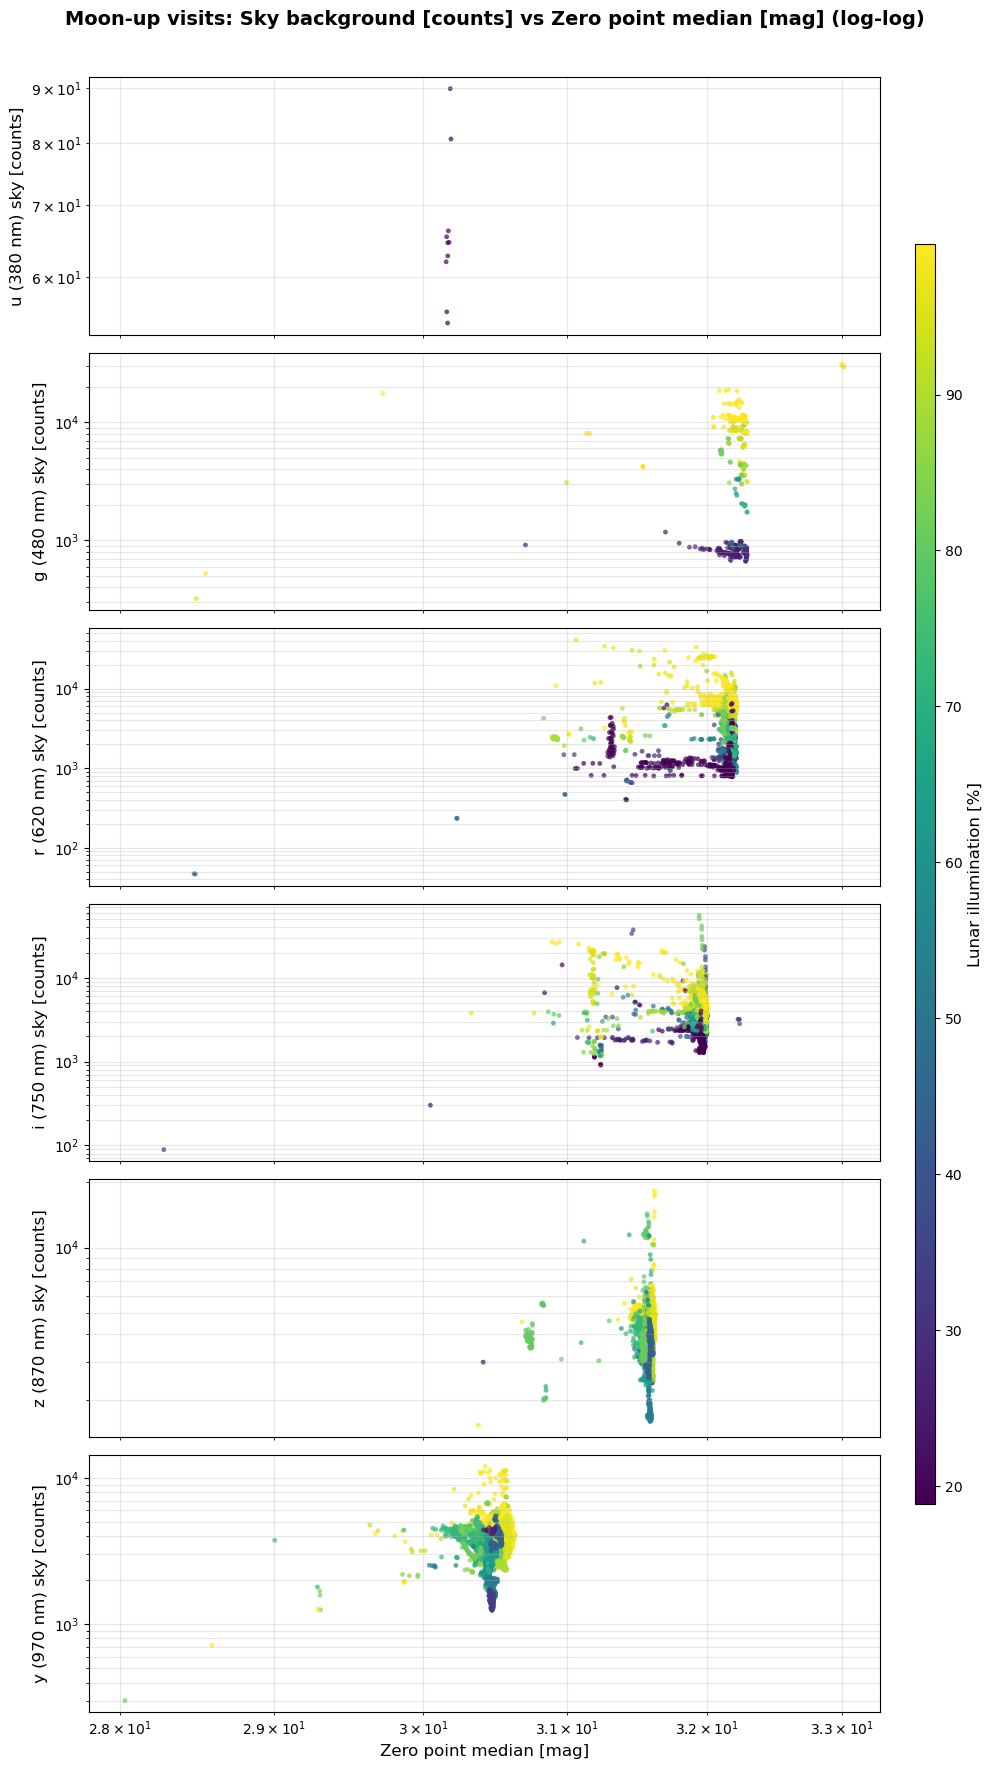

Saved figure: moon_plots_loglog_subplots/loglog_subplots_skyBg_vs_zeroPoint.png


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Photometry — All Bands Subplots, Sky background vs Zero point (log-log)
# X-axis: zero_point_median [mag]
# Y-axis: sky_bg_median [counts]
# Colour: lunar illumination [%]
# Moon-up only
# ═══════════════════════════════════════════════════════════════════════════

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")

CONSDB_H5  = "visits_20261024_20260219.h5"
OUTPUT_DIR = "moon_plots_loglog_subplots"
BANDS_TO_PLOT = ["u","g","r","i","z","y"]
PLOT_MIN_N = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)

BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

# ── Load HDF5 ─────────────────────────────────────────────────────────────
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Rows: {len(consdb)}, Columns: {list(consdb.columns[:30])}")

# ── MJD / time handling ───────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime() if pd.notna(m) and np.isfinite(m) else pd.NaT
            ), utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(lambda t: Time(t).mjd if pd.notna(t) else np.nan)
    if consdb["exp_midpt"].notna().sum() > 0:
        break

# ── Standardise column names ──────────────────────────────────────────────
for want, cands in {"ra":["s_ra","ra"], "dec":["s_dec","dec"], "band":["band","physical_filter"]}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in ["ra","dec","mjd","altitude","azimuth","airmass",
            "sky_bg_median","zero_point_median","stats_mag_lim_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r'([ugrizy])', expand=False)

consdb = consdb.dropna(subset=["exp_midpt","mjd","ra","dec","band","zero_point_median","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

# ── Compute Moon geometry ─────────────────────────────────────────────────
print("Computing Moon geometry ...")
results = []

for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])
    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    moon = get_body("moon", t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(get_body("sun", t, location=RUBIN_LOC)).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    results.append({
        "band": row["band"],
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "altitude": float(row["altitude"]),
        "moon_illum_pct": illum*100,
        "moon_up": moon_up,
        "sky_bg": float(row["sky_bg_median"]),
        "zero_point": float(row["zero_point_median"]),
    })

df = pd.DataFrame(results)
df = df[df["moon_up"]].copy()
print(f"Computed Moon geometry for {len(df)} moon-up rows")

# ── Subplots per band (log-log) ───────────────────────────────────────────
n_bands = len(BANDS_TO_PLOT)
fig, axes = plt.subplots(n_bands, 1, figsize=(10, 3*n_bands), sharex=True)

clim_low  = float(np.nanpercentile(df["moon_illum_pct"], 5))
clim_high = float(np.nanpercentile(df["moon_illum_pct"], 95))
norm = Normalize(vmin=clim_low, vmax=clim_high)
cmap = plt.get_cmap("viridis")

for ax, band in zip(axes, BANDS_TO_PLOT):
    sub = df[df["band"]==band]
    if len(sub) < PLOT_MIN_N:
        ax.set_visible(False)
        continue
    sc = ax.scatter(sub["zero_point"], sub["sky_bg"],
                    c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                    s=12, alpha=0.7, edgecolors="none")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_ylabel(f"{BAND_LABEL[band]} sky [counts]", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)

axes[-1].set_xlabel("Zero point median [mag]", fontsize=12)

# Colourbar on the right, outside subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coords
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label("Lunar illumination [%]", fontsize=12)

fig.suptitle("Moon-up visits: Sky background [counts] vs Zero point median [mag] (log-log)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0,0,0.9,0.97])  # leave space for colorbar
outpath = os.path.join(OUTPUT_DIR, "loglog_subplots_skyBg_vs_zeroPoint.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {outpath}")

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body, get_sun
from astropy.time import Time
import astropy.units as u

warnings.filterwarnings("ignore")

CONSDB_H5  = "visits_20261024_20260219.h5"
OUTPUT_DIR = "rubin_model_sky_residuals"
BANDS_TO_PLOT = ["u","g","r","i","z","y"]
PLOT_MIN_N = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)
PIX_SCALE = 0.2  # Rubin LSSTCam arcsec/pixel approx

BAND_LABEL = {
    "u":"u (380 nm)",
    "g":"g (480 nm)",
    "r":"r (620 nm)",
    "i":"i (750 nm)",
    "z":"z (870 nm)",
    "y":"y (970 nm)"
}

print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Rows: {len(consdb)}")

# ─────────────────────────────────────────────────────────────
# Standardize columns
# ─────────────────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime() if pd.notna(m) and np.isfinite(m) else pd.NaT
            ), utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(lambda t: Time(t).mjd if pd.notna(t) else np.nan)
    if consdb["exp_midpt"].notna().sum() > 0:
        break

for want, cands in {
    "ra":["s_ra","ra"],
    "dec":["s_dec","dec"],
    "band":["band","physical_filter"],
    "exptime":["exp_time","visitExposureTime"]
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

for col in ["ra","dec","mjd","altitude","azimuth","airmass",
            "sky_bg_median","zero_point_median","stats_mag_lim_median","exptime"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r'([ugrizy])', expand=False)

consdb = consdb.dropna(subset=["exp_midpt","mjd","ra","dec","band","zero_point_median","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

if "exptime" not in consdb.columns:
    consdb["exptime"] = 30.0

# ─────────────────────────────────────────────────────────────
# Rubin-native measured sky conversion
# assumes sky_bg_median ~ counts/pixel over the visit
# ─────────────────────────────────────────────────────────────
def sky_counts_to_mag_arcsec2(sky_counts_pix, zp, exptime, pixscale=0.2):
    if not np.isfinite(sky_counts_pix) or not np.isfinite(zp) or not np.isfinite(exptime):
        return np.nan
    if sky_counts_pix <= 0 or exptime <= 0:
        return np.nan
    cps_arcsec2 = (sky_counts_pix / exptime) / (pixscale**2)
    return zp - 2.5 * np.log10(cps_arcsec2)

consdb["sky_mag_obs"] = consdb.apply(
    lambda r: sky_counts_to_mag_arcsec2(r["sky_bg_median"], r["zero_point_median"], r["exptime"], PIX_SCALE),
    axis=1
)

# ─────────────────────────────────────────────────────────────
# Geometry per visit
# ─────────────────────────────────────────────────────────────
print("Computing visit geometry ...")

rows = []

for _, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])
    band = row["band"]

    t = Time(mjd, format="mjd")
    target = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    altaz_frame = AltAz(obstime=t, location=RUBIN_LOC)

    targ_aa = target.transform_to(altaz_frame)
    moon = get_body("moon", t, location=RUBIN_LOC)
    sun  = get_sun(t)

    moon_aa = moon.transform_to(altaz_frame)
    sun_aa  = sun.transform_to(altaz_frame)

    moon_sep = target.separation(moon).deg
    phase_sep = moon.separation(sun).deg
    moon_illum = (1 - np.cos(np.radians(phase_sep))) / 2.0
    moon_up = moon_aa.alt.deg > 0

    rows.append({
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "band": band,
        "zero_point": row["zero_point_median"],
        "sky_bg_counts": row["sky_bg_median"],
        "sky_mag_obs": row["sky_mag_obs"],
        "airmass": row["airmass"] if "airmass" in row else np.nan,
        "target_alt_deg": targ_aa.alt.deg,
        "target_az_deg": targ_aa.az.deg,
        "moon_alt_deg": moon_aa.alt.deg,
        "moon_sep_deg": moon_sep,
        "moon_illum_pct": moon_illum * 100.0,
        "sun_alt_deg": sun_aa.alt.deg,
        "moon_up": moon_up
    })

df = pd.DataFrame(rows)
df = df.dropna(subset=["sky_mag_obs"]).copy()

print(f"Rows after geometry: {len(df)}")

# ─────────────────────────────────────────────────────────────
# Rubin sky model evaluation
# ─────────────────────────────────────────────────────────────
print("Evaluating Rubin sky model ...")

# NOTE:
# The exact class/function here can vary by Rubin package version.
# The common pattern is to use rubin_sim.skybrightness interpolation/model objects
# and ask for the sky brightness at the target coordinates and time.

from rubin_sim.skybrightness import SkyModel

sky_model = SkyModel(mags=True)

model_vals = []

for _, row in df.iterrows():
    try:
        sky_model.set_ra_dec_mjd(
            np.radians(row["ra"]),
            np.radians(row["dec"]),
            row["mjd"],
            degrees=False
        )

        mag_dict = sky_model.return_mags()
        sky_model_mag = float(np.atleast_1d(mag_dict[row["band"]])[0])

    except Exception:
        sky_model_mag = np.nan

    model_vals.append(sky_model_mag)

df["sky_mag_model"] = model_vals
df["delta_sky_mag"] = df["sky_mag_obs"] - df["sky_mag_model"]

print("Usable Rubin model rows:", df["sky_mag_model"].notna().sum())

# ─────────────────────────────────────────────────────────────
# PLOT 1: sky residual vs zeropoint
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(BANDS_TO_PLOT), 1, figsize=(10, 3*len(BANDS_TO_PLOT)), sharex=True)

clim_low  = float(np.nanpercentile(df["moon_illum_pct"], 5))
clim_high = float(np.nanpercentile(df["moon_illum_pct"], 95))
norm = Normalize(vmin=clim_low, vmax=clim_high)
cmap = plt.get_cmap("viridis")

for ax, band in zip(axes, BANDS_TO_PLOT):
    sub = df[(df["band"] == band) & np.isfinite(df["delta_sky_mag"])].copy()
    if len(sub) < PLOT_MIN_N:
        ax.set_visible(False)
        continue

    sc = ax.scatter(
        sub["zero_point"],
        sub["delta_sky_mag"],
        c=sub["moon_illum_pct"],
        cmap=cmap,
        norm=norm,
        s=12,
        alpha=0.7,
        edgecolors="none"
    )

    ax.axhline(0, color="k", ls="--", lw=1, alpha=0.5)
    ax.set_ylabel(f"{band}: Obs - Rubin sky\n[mag/arcsec²]", fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Measured zero_point_median [mag]", fontsize=12)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label("Lunar illumination [%]", fontsize=12)

fig.suptitle("Measured sky minus Rubin model sky vs zeropoint", fontsize=14, weight="bold")
plt.tight_layout(rect=[0,0,0.9,0.97])

outpath = os.path.join(OUTPUT_DIR, "deltaSky_vs_zeroPoint.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {outpath}")

Loading ConsDB HDF5 ...
Rows: 29933
Computing visit geometry ...
Rows after geometry: 27189
Evaluating Rubin sky model ...


IndexError: list index out of range

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Photometry — Sky brightness RESIDUAL vs Zero-point DEFICIT
# Uses rubin_sim.skybrightness for per-pointing sky model
#
# X-axis: ΔZP = ZP_obs − ZP_nominal(band, airmass)   [mag, negative = loss]
# Y-axis: Δsky = sky_obs_mag − sky_model_mag           [mag/arcsec², + = brighter than model]
# Colour: lunar illumination [%]
# Moon-up visits only
# ═══════════════════════════════════════════════════════════════════════════

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable

from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

# rubin_sim sky brightness model (pip install rubin-sim)
# NEW — works with rubin_sim ≥ 1.0:
from rubin_sim.skybrightness import SkyModel, SkyModelPre

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────
CONSDB_H5     = "visits_20261024_20260219.h5"
OUTPUT_DIR    = "moon_plots_skymodel"
BANDS         = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N    = 10
USE_PRECOMP   = True   # True = fast interpolator; False = full analytical model

# Nominal zero-points (mag) at zenith, 1s, 1 e-/ADU — adjust to your system
# These are approximate LSST design values; replace with your survey baseline if known
ZP_NOMINAL = {"u": 26.50, "g": 28.30, "r": 28.13, "i": 27.79, "z": 27.40, "y": 26.58}

# Atmospheric extinction coefficients k [mag/airmass] — standard Cerro Pachón values
K_EXT = {"u": 0.48, "g": 0.21, "r": 0.10, "i": 0.07, "z": 0.05, "y": 0.04}

os.makedirs(OUTPUT_DIR, exist_ok=True)

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)
BAND_LABEL = {"u":"u (380 nm)", "g":"g (480 nm)", "r":"r (620 nm)",
              "i":"i (750 nm)", "z":"z (870 nm)", "y":"y (970 nm)"}

# ── Sky brightness model in mag/arcsec² → counts conversion ───────────────
PIXEL_SCALE   = 0.2        # arcsec/pixel (LSST)
EXP_TIME_NOM  = 30.0       # s  (nominal single snap)
GAIN          = 1.0        # e-/ADU (set to actual if known)

def sky_mag_to_counts(sky_mag_per_arcsec2, zero_point, exp_time=EXP_TIME_NOM):
    """Convert sky surface brightness [mag/arcsec²] to counts/pixel."""
    flux_per_arcsec2 = 10**((zero_point - sky_mag_per_arcsec2) / 2.5)
    return flux_per_arcsec2 * PIXEL_SCALE**2 * exp_time

# ── Load ConsDB ───────────────────────────────────────────────────────────
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"  Rows: {len(consdb)}")

# ── Standardise columns ───────────────────────────────────────────────────
for want, cands in {"ra":  ["s_ra","ra"],
                    "dec": ["s_dec","dec"],
                    "band":["band","physical_filter"]}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]; break

for tc in ["exp_midpt_mjd", "obs_start_mjd", "exp_midpt", "obs_start"]:
    if tc not in consdb.columns: continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
    else:
        consdb["mjd"] = consdb[tc].apply(
            lambda t: Time(pd.Timestamp(t)).mjd if pd.notna(t) else np.nan)
    if consdb["mjd"].notna().sum() > 0: break

for col in ["ra","dec","mjd","airmass","sky_bg_median","zero_point_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r'([ugrizy])', expand=False)

consdb = consdb.dropna(subset=["mjd","ra","dec","band",
                                "zero_point_median","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS)].copy()
print(f"  After cleaning: {len(consdb)} rows")

# ── Initialise Rubin sky model ─────────────────────────────────────────────
print("Initialising rubin_sim sky model ...")
if USE_PRECOMP:
    sky_model = SkyModelPre()
else:
    sky_model = SkyModel(mags=True)   # returns mag/arcsec²

# ── Per-row computation ────────────────────────────────────────────────────
print("Computing Moon geometry + sky model per pointing ...")
results = []

# rubin_sim filter name map
BAND_TO_FILTER = {"u":"u","g":"g","r":"r","i":"i","z":"z","y":"y"}

for _, row in consdb.iterrows():
    mjd  = float(row["mjd"])
    ra   = float(row["ra"])
    dec  = float(row["dec"])
    band = str(row["band"])
    t    = Time(mjd, format="mjd")

    # ── Moon geometry ──
    moon = get_body("moon", t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
    sep  = float(moon.separation(get_body("sun", t, location=RUBIN_LOC)).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = maa.alt.deg > 0
    if not moon_up:
        continue

    # ── Airmass (use consdb value or recompute) ──
    if "airmass" in row and np.isfinite(row["airmass"]):
        airmass = float(row["airmass"])
    else:
        sky_coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
        aa = sky_coord.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
        airmass = float(1.0 / np.sin(aa.alt.rad)) if aa.alt.deg > 5 else np.nan

    # ── ZP deficit relative to nominal ──
    zp_obs = float(row["zero_point_median"])
    zp_nom = ZP_NOMINAL.get(band, np.nan) - K_EXT.get(band, 0.0) * (airmass - 1.0)
    delta_zp = zp_obs - zp_nom   # negative = transparency loss

    # ── Rubin sky model: sky brightness in mag/arcsec² ──
    try:
        if USE_PRECOMP:
            # SkyModelPre.returnMags(mjd, ra_rad_array, dec_rad_array, filter_name)
            sky_mags = sky_model.returnMags(
                mjd,
                np.array([np.radians(ra)]),
                np.array([np.radians(dec)]),
                indx=None,
                badval=np.nan,
                extrapolate=True
            )
            # sky_mags is dict keyed by filter name, value is array[n_points]
            sky_model_mag = float(sky_mags[BAND_TO_FILTER[band]][0])
        else:
            sky_model.setRaDecMjd(
                np.array([np.radians(ra)]),
                np.array([np.radians(dec)]),
                mjd,
                degrees=False
            )
            sky_mags = sky_model.returnMags()
            sky_model_mag = float(sky_mags[BAND_TO_FILTER[band]][0])
    except Exception:
        sky_model_mag = np.nan

    # ── Convert observed sky counts → mag/arcsec² ──
    sky_counts = float(row["sky_bg_median"])
    exp_time   = float(row.get("exp_time", EXP_TIME_NOM))
    # counts/pixel → flux density → mag/arcsec²
    # sky_mag = ZP − 2.5·log10(counts / (pixel_scale² · t_exp))
    surf_brightness_counts = sky_counts / (PIXEL_SCALE**2 * exp_time)
    if surf_brightness_counts > 0:
        sky_obs_mag = zp_obs - 2.5 * np.log10(surf_brightness_counts)
    else:
        sky_obs_mag = np.nan

    delta_sky = sky_obs_mag - sky_model_mag   # + = brighter than model

    results.append({
        "band":          band,
        "mjd":           mjd,
        "ra":            ra,
        "dec":           dec,
        "airmass":       airmass,
        "moon_illum_pct": illum * 100,
        "zp_obs":        zp_obs,
        "zp_nominal":    zp_nom,
        "delta_zp":      delta_zp,
        "sky_obs_mag":   sky_obs_mag,
        "sky_model_mag": sky_model_mag,
        "delta_sky":     delta_sky,
        "sky_bg_counts": sky_counts,
    })

df = pd.DataFrame(results).dropna(subset=["delta_zp","delta_sky"])
print(f"  Final sample: {len(df)} moon-up rows with valid model")

# Save enriched table
df.to_csv(os.path.join(OUTPUT_DIR, "visits_with_skymodel.csv"), index=False)

# ── Plot: Δsky vs ΔZP per band ────────────────────────────────────────────
print("Plotting ...")
n_bands = len(BANDS)
fig = plt.figure(figsize=(12, 4*n_bands))
gs  = gridspec.GridSpec(n_bands, 1, hspace=0.35)

clim_low  = np.nanpercentile(df["moon_illum_pct"], 5)
clim_high = np.nanpercentile(df["moon_illum_pct"], 95)
norm  = Normalize(vmin=clim_low, vmax=clim_high)
cmap  = plt.get_cmap("plasma")

for i, band in enumerate(BANDS):
    sub = df[df["band"] == band].copy()
    ax  = fig.add_subplot(gs[i])
    if len(sub) < PLOT_MIN_N:
        ax.set_visible(False); continue

    sc = ax.scatter(sub["delta_zp"], sub["delta_sky"],
                    c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                    s=14, alpha=0.75, edgecolors="none")

    # Reference lines
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5, label="Model sky")
    ax.axvline(0, color="r", lw=0.8, ls="--", alpha=0.5, label="Nominal ZP")

    # Regression line
    m = np.isfinite(sub["delta_zp"]) & np.isfinite(sub["delta_sky"])
    if m.sum() > 5:
        c = np.polyfit(sub["delta_zp"][m], sub["delta_sky"][m], 1)
        x_fit = np.linspace(sub["delta_zp"][m].min(), sub["delta_zp"][m].max(), 100)
        ax.plot(x_fit, np.polyval(c, x_fit), "w-", lw=1.5, alpha=0.8,
                label=f"slope={c[0]:.2f}")

    ax.set_ylabel(f"{BAND_LABEL[band]}\nΔsky [mag/arcsec²]", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_title(
        f"{band}-band  n={len(sub)}  "
        f"median Δsky={sub['delta_sky'].median():.2f} mag/arcsec²  "
        f"median ΔZP={sub['delta_zp'].median():.2f} mag",
        fontsize=9, pad=3
    )

axes_all = [fig.axes[i] for i in range(len(fig.axes))]
axes_all[-1].set_xlabel("ΔZP = ZP_obs − ZP_nominal(band, airmass)  [mag]", fontsize=12)

# Colourbar
cbar_ax = fig.add_axes([0.92, 0.12, 0.018, 0.76])
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb.set_label("Lunar illumination [%]", fontsize=11)

fig.suptitle(
    "Moon-up visits: Sky residual vs ZP deficit relative to rubin_sim sky model\n"
    r"$\Delta$sky = sky$_\mathrm{obs}$ − sky$_\mathrm{model}$   |   "
    r"$\Delta$ZP = ZP$_\mathrm{obs}$ − ZP$_\mathrm{nominal}$(band, X)",
    fontsize=13, weight="bold"
)
plt.tight_layout(rect=[0, 0, 0.91, 0.96])
outpath = os.path.join(OUTPUT_DIR, "delta_sky_vs_delta_zp_subplots.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {outpath}")

# ── Bonus: 2D hexbin — all bands combined ─────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 7))
hb = ax2.hexbin(df["delta_zp"], df["delta_sky"],
                C=df["moon_illum_pct"], gridsize=60,
                reduce_C_function=np.median,
                cmap="plasma", mincnt=3)
ax2.axhline(0, color="w", lw=1, ls="--")
ax2.axvline(0, color="r", lw=1, ls="--")
cb2 = fig2.colorbar(hb, ax=ax2)
cb2.set_label("Median lunar illumination [%]", fontsize=11)
ax2.set_xlabel("ΔZP = ZP_obs − ZP_nominal(band, airmass)  [mag]", fontsize=12)
ax2.set_ylabel("Δsky = sky_obs − sky_model  [mag/arcsec²]", fontsize=12)
ax2.set_title("All bands: Sky residual vs ZP deficit (hexbin, moon-up)", fontsize=13, weight="bold")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
outpath2 = os.path.join(OUTPUT_DIR, "hexbin_all_bands_delta_sky_vs_delta_zp.png")
plt.savefig(outpath2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {outpath2}")

ImportError: cannot import name 'SkyModelPre' from 'rubin_sim.skybrightness' (/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/rubin_sim/skybrightness/__init__.py)

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# Moon × Photometry — Sky brightness RESIDUAL vs Zero-point DEFICIT
# Uses rubin_sim 2.6.1 SkyModel for per-pointing sky model
#
# X-axis: ΔZP  = ZP_obs − ZP_nominal(band, airmass)   [mag, negative = loss]
# Y-axis: Δsky = sky_obs_mag − sky_model_mag            [mag/arcsec², + = brighter than model]
# Colour: lunar illumination [%]
# Moon-up visits only
# ═══════════════════════════════════════════════════════════════════════════

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

from rubin_sim.skybrightness import SkyModel

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────
CONSDB_H5  = "visits_20261024_20260219.h5"
OUTPUT_DIR = "moon_plots_skymodel"
BANDS      = ["u", "g", "r", "i", "z", "y"]
PLOT_MIN_N = 10

# Nominal zero-points [mag] at zenith — approximate LSST design values
# Replace with your survey-wide median from clean photometric nights
ZP_NOMINAL = {"u": 26.50, "g": 28.30, "r": 28.13, "i": 27.79, "z": 27.40, "y": 26.58}

# Standard Cerro Pachón atmospheric extinction [mag/airmass]
K_EXT = {"u": 0.48, "g": 0.21, "r": 0.10, "i": 0.07, "z": 0.05, "y": 0.04}

# LSST camera constants
PIXEL_SCALE  = 0.2    # arcsec/pixel
EXP_TIME_NOM = 30.0   # seconds (nominal single snap)

BAND_LABEL = {
    "u": "u (380 nm)", "g": "g (480 nm)", "r": "r (620 nm)",
    "i": "i (750 nm)", "z": "z (870 nm)", "y": "y (970 nm)"
}

RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Sky model query helper ────────────────────────────────────────────────
def get_sky_model_mag(model, ra_deg, dec_deg, mjd, band):
    """
    Query rubin_sim SkyModel for a single pointing.
    Returns sky brightness in mag/arcsec² or NaN on failure.
    """
    try:
        model.setRaDecMjd(
            np.array([np.radians(ra_deg)]),
            np.array([np.radians(dec_deg)]),
            mjd,
            degrees=False,
            azAlt=False,
        )
        mags = model.returnMags()
        if band not in mags:
            return np.nan
        val = mags[band]
        if hasattr(val, "filled"):
            val = val.filled(np.nan)
        return float(val[0])
    except Exception:
        return np.nan

# ── Load ConsDB ───────────────────────────────────────────────────────────
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"  Rows: {len(consdb)},  Columns: {list(consdb.columns[:15])}")

# ── Standardise column names ──────────────────────────────────────────────
for want, cands in {
    "ra":   ["s_ra",  "ra"],
    "dec":  ["s_dec", "dec"],
    "band": ["band",  "physical_filter"],
}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]
                break

# MJD
for tc in ["exp_midpt_mjd", "obs_start_mjd", "exp_midpt", "obs_start"]:
    if tc not in consdb.columns:
        continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
    else:
        consdb["mjd"] = consdb[tc].apply(
            lambda t: Time(pd.Timestamp(t)).mjd if pd.notna(t) else np.nan
        )
    if consdb["mjd"].notna().sum() > 0:
        break

for col in ["ra", "dec", "mjd", "airmass", "sky_bg_median", "zero_point_median", "exp_time"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r"([ugrizy])", expand=False)

consdb = consdb.dropna(subset=["mjd", "ra", "dec", "band", "zero_point_median", "sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS)].copy()
print(f"  After cleaning: {len(consdb)} rows")

# ── Sanity-check the sky model with one test pointing ────────────────────
print("\nSanity-checking SkyModel ...")
sky_model = SkyModel(mags=True)
sky_model.setRaDecMjd(
    np.array([np.radians(180.0)]),
    np.array([np.radians(-30.0)]),
    60000.0,
    degrees=False,
)
test = sky_model.returnMags()
print("  Test sky mags (mag/arcsec²):",
      {k: round(float(v.filled(np.nan)[0] if hasattr(v, "filled") else v[0]), 2)
       for k, v in test.items()})

# ── Per-row computation ───────────────────────────────────────────────────
print(f"\nProcessing {len(consdb)} visits ...")
results = []

for idx, (_, row) in enumerate(consdb.iterrows()):
    if idx % 2000 == 0:
        print(f"  {idx}/{len(consdb)} ...")

    mjd  = float(row["mjd"])
    ra   = float(row["ra"])
    dec  = float(row["dec"])
    band = str(row["band"])
    t    = Time(mjd, format="mjd")

    # ── Moon geometry ──────────────────────────────────────────────────
    try:
        moon = get_body("moon", t, location=RUBIN_LOC)
        maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
        sun  = get_body("sun",  t, location=RUBIN_LOC)
        sep  = float(moon.separation(sun).deg)
    except Exception:
        continue

    illum   = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = maa.alt.deg > 0
    if not moon_up:
        continue

    # ── Airmass ────────────────────────────────────────────────────────
    if "airmass" in row.index and np.isfinite(float(row["airmass"])):
        airmass = float(row["airmass"])
    else:
        try:
            sc = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
            aa = sc.transform_to(AltAz(obstime=t, location=RUBIN_LOC))
            airmass = float(1.0 / np.sin(np.radians(aa.alt.deg))) if aa.alt.deg > 5 else np.nan
        except Exception:
            airmass = np.nan

    if not np.isfinite(airmass):
        continue

    # ── ZP deficit ─────────────────────────────────────────────────────
    zp_obs = float(row["zero_point_median"])
    zp_nom = ZP_NOMINAL[band] - K_EXT[band] * (airmass - 1.0)
    delta_zp = zp_obs - zp_nom      # negative → transparency loss

    # ── Rubin sky model ────────────────────────────────────────────────
    sky_model_mag = get_sky_model_mag(sky_model, ra, dec, mjd, band)

    # ── Convert observed sky counts → mag/arcsec² ──────────────────────
    sky_counts = float(row["sky_bg_median"])
    exp_time   = float(row["exp_time"]) if ("exp_time" in row.index and np.isfinite(float(row["exp_time"]))) else EXP_TIME_NOM

    surf = sky_counts / (PIXEL_SCALE**2 * exp_time)   # counts / arcsec² / s  (flux density)
    if surf > 0 and np.isfinite(zp_obs):
        # mag/arcsec²: use ZP_obs so we're comparing surface brightness on the same scale
        sky_obs_mag = zp_obs - 2.5 * np.log10(sky_counts / exp_time) + 2.5 * np.log10(PIXEL_SCALE**2)
    else:
        sky_obs_mag = np.nan

    delta_sky = sky_obs_mag - sky_model_mag    # positive → brighter than model

    results.append({
        "band":           band,
        "mjd":            mjd,
        "ra":             ra,
        "dec":            dec,
        "airmass":        airmass,
        "moon_illum_pct": illum * 100,
        "zp_obs":         zp_obs,
        "zp_nominal":     zp_nom,
        "delta_zp":       delta_zp,
        "sky_obs_mag":    sky_obs_mag,
        "sky_model_mag":  sky_model_mag,
        "delta_sky":      delta_sky,
        "sky_bg_counts":  sky_counts,
    })

df = pd.DataFrame(results)
print(f"\nRaw moon-up rows: {len(df)}")
df = df.dropna(subset=["delta_zp", "delta_sky"])
print(f"After dropping NaN residuals: {len(df)} rows")

# Save enriched table
csv_path = os.path.join(OUTPUT_DIR, "visits_with_skymodel.csv")
df.to_csv(csv_path, index=False)
print(f"Saved enriched table: {csv_path}")

# ── Per-band subplots: Δsky vs ΔZP ───────────────────────────────────────
print("\nPlotting per-band subplots ...")

fig = plt.figure(figsize=(12, 4 * len(BANDS)))
gs  = gridspec.GridSpec(len(BANDS), 1, hspace=0.45)

clim_low  = np.nanpercentile(df["moon_illum_pct"], 5)
clim_high = np.nanpercentile(df["moon_illum_pct"], 95)
norm = Normalize(vmin=clim_low, vmax=clim_high)
cmap = plt.get_cmap("plasma")

for i, band in enumerate(BANDS):
    sub = df[df["band"] == band].copy()
    ax  = fig.add_subplot(gs[i])

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"{band}: insufficient data (n={len(sub)})",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_ylabel(BAND_LABEL[band])
        continue

    ax.scatter(
        sub["delta_zp"], sub["delta_sky"],
        c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
        s=14, alpha=0.75, edgecolors="none"
    )

    # Reference lines
    ax.axhline(0, color="white", lw=0.9, ls="--", alpha=0.6)
    ax.axvline(0, color="tomato", lw=0.9, ls="--", alpha=0.6)

    # Quadrant labels
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.text(0.02, 0.97, "clouds only\n(dim sky, low ZP)",
            transform=ax.transAxes, fontsize=7, va="top", color="tomato", alpha=0.8)
    ax.text(0.75, 0.97, "moon + clouds\n(bright sky, low ZP)",
            transform=ax.transAxes, fontsize=7, va="top", color="tomato", alpha=0.8)
    ax.text(0.75, 0.05, "moon only\n(bright sky, good ZP)",
            transform=ax.transAxes, fontsize=7, va="bottom", color="white", alpha=0.8)

    # Linear regression
    m = np.isfinite(sub["delta_zp"]) & np.isfinite(sub["delta_sky"])
    if m.sum() > 10:
        c = np.polyfit(sub["delta_zp"][m], sub["delta_sky"][m], 1)
        xf = np.linspace(sub["delta_zp"][m].min(), sub["delta_zp"][m].max(), 200)
        ax.plot(xf, np.polyval(c, xf), "w-", lw=1.5, alpha=0.9,
                label=f"slope = {c[0]:.2f}")
        ax.legend(fontsize=8, loc="upper left", framealpha=0.3)

    ax.set_ylabel(f"{BAND_LABEL[band]}\nΔsky [mag/arcsec²]", fontsize=10)
    ax.set_facecolor("#111111")
    ax.grid(True, alpha=0.25)
    ax.set_title(
        f"{band}-band   n={len(sub)}   "
        f"median Δsky={sub['delta_sky'].median():.2f} mag/arcsec²   "
        f"median ΔZP={sub['delta_zp'].median():.2f} mag",
        fontsize=9, pad=3
    )

fig.axes[-1].set_xlabel("ΔZP = ZP_obs − ZP_nominal(band, X)  [mag]", fontsize=12)

# Shared colourbar
cbar_ax = fig.add_axes([0.92, 0.12, 0.018, 0.76])
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb.set_label("Lunar illumination [%]", fontsize=11)

fig.suptitle(
    "Moon-up visits: Sky residual vs ZP deficit  (rubin_sim 2.6.1 SkyModel)\n"
    r"$\Delta$sky = sky$_\mathrm{obs}$ − sky$_\mathrm{model}$  |  "
    r"$\Delta$ZP = ZP$_\mathrm{obs}$ − ZP$_\mathrm{nominal}$(band, X)",
    fontsize=13, weight="bold", y=0.995
)
plt.tight_layout(rect=[0, 0, 0.91, 0.99])
out1 = os.path.join(OUTPUT_DIR, "delta_sky_vs_delta_zp_per_band.png")
plt.savefig(out1, dpi=150, bbox_inches="tight", facecolor="#1a1a1a")
plt.show()
print(f"Saved: {out1}")

# ── All-bands hexbin summary ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9), facecolor="#1a1a1a")
axes2 = axes2.flatten()

for i, band in enumerate(BANDS):
    ax  = axes2[i]
    sub = df[df["band"] == band]
    ax.set_facecolor("#111111")

    if len(sub) < PLOT_MIN_N:
        ax.text(0.5, 0.5, f"n={len(sub)}", ha="center", va="center",
                transform=ax.transAxes, color="white")
    else:
        hb = ax.hexbin(
            sub["delta_zp"], sub["delta_sky"],
            C=sub["moon_illum_pct"],
            gridsize=40,
            reduce_C_function=np.median,
            cmap="plasma", mincnt=3,
            vmin=clim_low, vmax=clim_high,
        )
        ax.axhline(0, color="white", lw=0.8, ls="--", alpha=0.5)
        ax.axvline(0, color="tomato", lw=0.8, ls="--", alpha=0.5)
        cb = fig2.colorbar(hb, ax=ax, pad=0.02)
        cb.set_label("Moon illum [%]", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    ax.set_title(f"{BAND_LABEL[band]}  (n={len(sub)})", color="white", fontsize=10)
    ax.set_xlabel("ΔZP [mag]", fontsize=9, color="white")
    ax.set_ylabel("Δsky [mag/arcsec²]", fontsize=9, color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    ax.grid(True, alpha=0.2)

fig2.suptitle(
    "All bands: Sky residual vs ZP deficit  (hexbin, moon-up, rubin_sim SkyModel)",
    fontsize=13, weight="bold", color="white"
)
plt.tight_layout()
out2 = os.path.join(OUTPUT_DIR, "hexbin_per_band_delta_sky_vs_delta_zp.png")
plt.savefig(out2, dpi=150, bbox_inches="tight", facecolor="#1a1a1a")
plt.show()
print(f"Saved: {out2}")

print("\nDone. Output files:")
print(f"  {csv_path}")
print(f"  {out1}")
print(f"  {out2}")

Loading ConsDB HDF5 ...
  Rows: 29933,  Columns: ['air_temp', 'airmass', 'altitude', 'altitude_end', 'altitude_start', 'azimuth', 'azimuth_end', 'azimuth_start', 'band', 'can_see_sky', 'controller', 'cur_index', 'dark_time', 'day_obs', 'dimm_seeing']
  After cleaning: 27189 rows

Sanity-checking SkyModel ...


IndexError: list index out of range

In [11]:
# Run this once in a notebook cell to check and download missing data
import rubin_sim.data as rs_data
print("Data dir:", rs_data.get_data_dir())

import os, glob
sky_dir = os.path.join(rs_data.get_data_dir(), "skybrightness", "ESO_Spectra")
print("ESO_Spectra exists:", os.path.isdir(sky_dir))
print("Files found:", len(glob.glob(sky_dir + "/**/*.npz", recursive=True)))

Data dir: /home/s/segev/rubin_sim_data
ESO_Spectra exists: False
Files found: 0


In [13]:
# Option 1: run as module
subprocess.run([sys.executable, "-m", "rubin_sim.data.rs_download_data",
                "--data-selection", "skybrightness"], check=True)

<frozen runpy>:128: RuntimeWarning: 'rubin_sim.data.rs_download_data' found in sys.modules after import of package 'rubin_sim.data', but prior to execution of 'rubin_sim.data.rs_download_data'; this may result in unpredictable behaviour


CompletedProcess(args=['/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/bin/python3', '-m', 'rubin_sim.data.rs_download_data', '--data-selection', 'skybrightness'], returncode=0)

Loading ConsDB HDF5 ...
Rows: 29933
DEBUG: Limited to first 100 rows.
Computing Moon geometry and measured sky brightness ...
Computed Moon geometry for 54 moon-up rows

⚠️  Rubin sky model not available: No module named 'rubin_sim.utils'
   Proceeding without model computations. To install data, run:
       pip install rubin_sim_data
   or (if using conda):
       conda install -c lsstts rubin_sim_data
Skipping model computations.

Generating original plot...


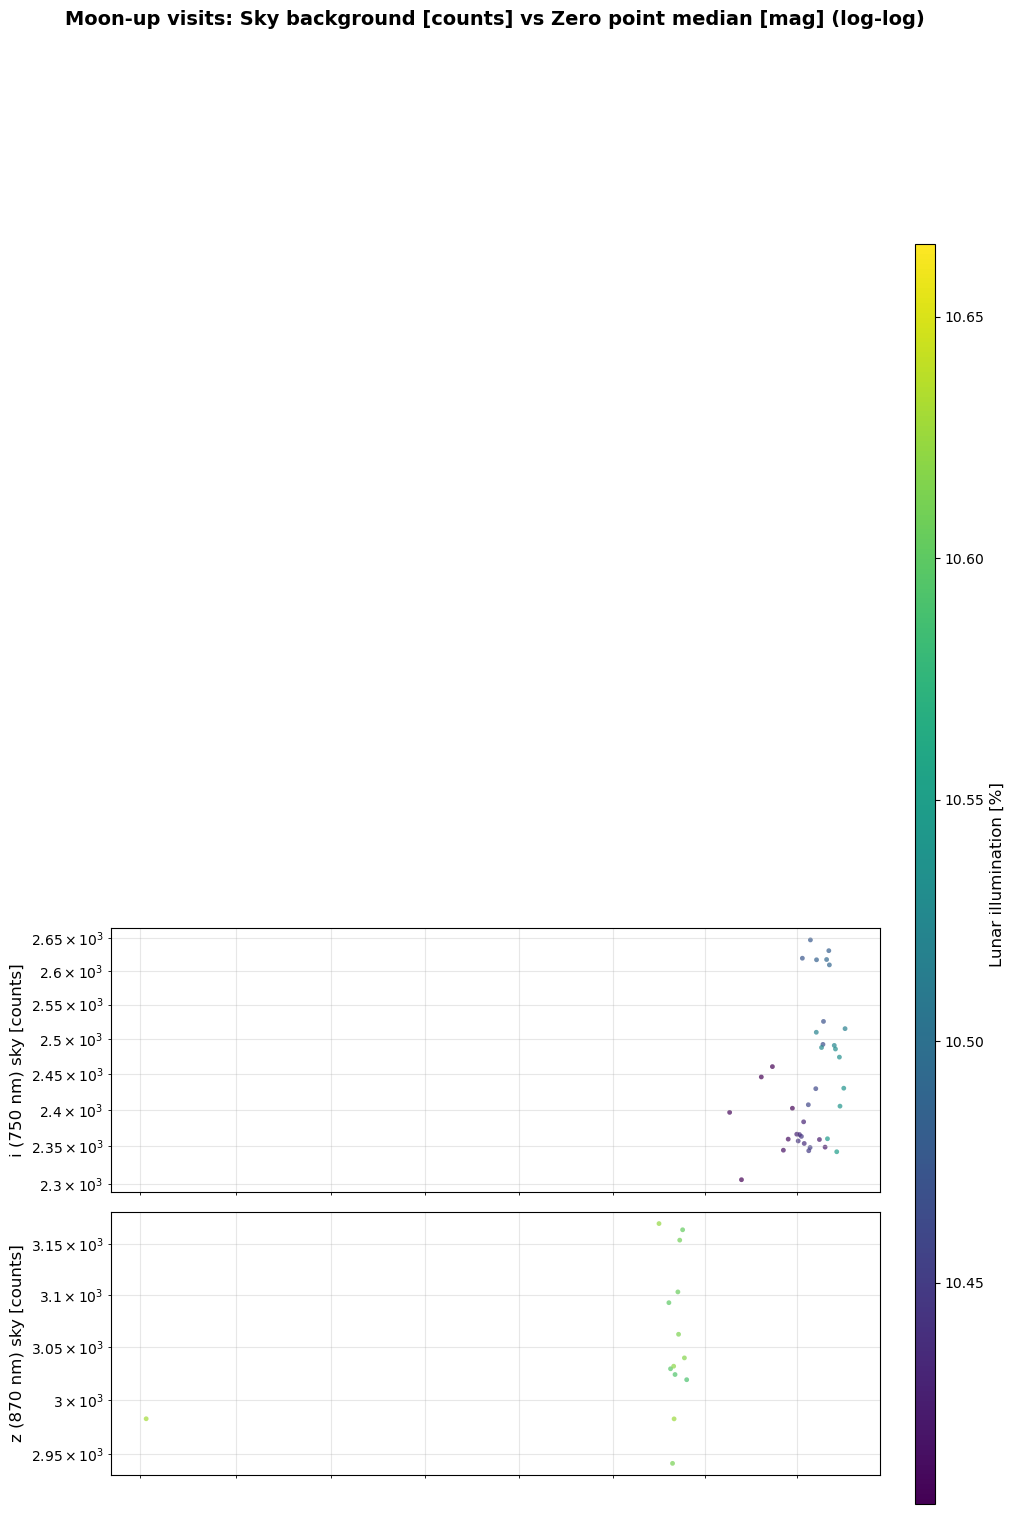

Saved figure: moon_plots_with_model/loglog_subplots_skyBg_vs_zeroPoint.png

Model plots skipped because Rubin sky model is not available.


In [20]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Enhanced Moon × Photometry — Including Rubin Sky Model (debug mode)

Usage:
    python moon_photometry_with_model.py

If the Rubin sky model data is missing, the script will:
    - warn the user and proceed without model calculations.
    - still produce the original sky_bg vs zero_point plots.

To enable full model-based analysis:
    pip install rubin_sim_data   (or conda install -c lsstts rubin_sim_data)
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_body
from astropy.time import Time
import astropy.units as u

# Optional progress bar (install with `pip install tqdm`)
try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x  # dummy if not installed

warnings.filterwarnings("ignore")

# ==================== CONFIGURATION ====================
CONSDB_H5  = "visits_20261024_20260219.h5"   # <-- Update with your actual file name
OUTPUT_DIR = "moon_plots_with_model"
BANDS_TO_PLOT = ["u","g","r","i","z","y"]
PLOT_MIN_N = 10
RUBIN_LOC = EarthLocation(lat=-30.244639*u.deg, lon=-70.749417*u.deg, height=2663.0*u.m)
PIXEL_AREA_ARCSEC2 = 0.04
MAG_PER_ARCSEC2_OFFSET = -2.5 * np.log10(PIXEL_AREA_ARCSEC2)  # ≈ -3.49485

# Debug limit: set to e.g. 100 to process only first N rows (for quick testing)
DEBUG_LIMIT = 100   # Set to None to process all rows

# Band labels for plotting
BAND_LABEL = {"u":"u (380 nm)","g":"g (480 nm)","r":"r (620 nm)",
              "i":"i (750 nm)","z":"z (870 nm)","y":"y (970 nm)"}

os.makedirs(OUTPUT_DIR, exist_ok=True)
# =======================================================

# ── Load HDF5 ─────────────────────────────────────────────────────────────
print("Loading ConsDB HDF5 ...")
consdb = pd.read_hdf(CONSDB_H5, key="visits")
print(f"Rows: {len(consdb)}")

# ── MJD / time handling ───────────────────────────────────────────────────
for tc in ["exp_midpt", "obs_start", "exp_midpt_mjd", "obs_start_mjd"]:
    if tc not in consdb.columns: continue
    if "mjd" in tc:
        consdb["mjd"] = pd.to_numeric(consdb[tc], errors="coerce")
        consdb["exp_midpt"] = pd.to_datetime(
            consdb["mjd"].apply(
                lambda m: Time(m, format="mjd").to_datetime() if pd.notna(m) and np.isfinite(m) else pd.NaT
            ), utc=True
        )
    else:
        consdb["exp_midpt"] = pd.to_datetime(consdb[tc], utc=True, errors="coerce")
        consdb["mjd"] = consdb["exp_midpt"].apply(lambda t: Time(t).mjd if pd.notna(t) else np.nan)
    if consdb["exp_midpt"].notna().sum() > 0: break

# ── Standardise column names ──────────────────────────────────────────────
for want, cands in {"ra":["s_ra","ra"], "dec":["s_dec","dec"], "band":["band","physical_filter"]}.items():
    if want not in consdb.columns:
        for c in cands:
            if c in consdb.columns:
                consdb[want] = consdb[c]; break

for col in ["ra","dec","mjd","altitude","azimuth","airmass","sky_bg_median","zero_point_median"]:
    if col in consdb.columns:
        consdb[col] = pd.to_numeric(consdb[col], errors="coerce")

if "band" in consdb.columns:
    consdb["band"] = consdb["band"].astype(str).str.extract(r'([ugrizy])', expand=False)

# Remove rows with missing essential data
consdb = consdb.dropna(subset=["exp_midpt","mjd","ra","dec","band","zero_point_median","sky_bg_median"]).copy()
consdb = consdb[consdb["band"].isin(BANDS_TO_PLOT)].copy()

# ── Apply debug limit ────────────────────────────────────────────────────
if DEBUG_LIMIT is not None:
    consdb = consdb.head(DEBUG_LIMIT).copy()
    print(f"DEBUG: Limited to first {DEBUG_LIMIT} rows.")

# ── Compute Moon geometry and measured sky brightness ─────────────────────
print("Computing Moon geometry and measured sky brightness ...")
results = []
for i, row in consdb.iterrows():
    mjd = float(row["mjd"])
    ra  = float(row["ra"])
    dec = float(row["dec"])
    t   = Time(mjd, format="mjd")
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    moon = get_body("moon", t, location=RUBIN_LOC)
    maa  = moon.transform_to(AltAz(obstime=t, location=RUBIN_LOC))

    sep = float(moon.separation(get_body("sun", t, location=RUBIN_LOC)).deg)
    illum = (1 - np.cos(np.radians(sep))) / 2.0
    moon_up = bool(maa.alt.deg > 0)

    zp = float(row["zero_point_median"])
    counts = float(row["sky_bg_median"])
    if counts > 0:
        measured_sb = zp - 2.5 * np.log10(counts) + MAG_PER_ARCSEC2_OFFSET
    else:
        measured_sb = np.nan

    results.append({
        "band": row["band"],
        "mjd": mjd,
        "ra": ra,
        "dec": dec,
        "altitude": float(row["altitude"]) if not pd.isna(row["altitude"]) else np.nan,
        "airmass": float(row["airmass"]) if not pd.isna(row["airmass"]) else np.nan,
        "moon_illum_pct": illum*100,
        "moon_up": moon_up,
        "sky_bg": counts,
        "zero_point": zp,
        "measured_sb": measured_sb,
    })

df = pd.DataFrame(results)
df = df[df["moon_up"]].copy()
print(f"Computed Moon geometry for {len(df)} moon-up rows")

# ── Try to initialise Rubin SkyModel (with data check) ──────────────────
RUBIN_SIM_AVAILABLE = False
try:
    from rubin_sim.skybrightness import SkyModel
    from rubin_sim.utils import get_data_dir
    data_dir = os.path.join(get_data_dir(), "skybrightness", "ESO_Spectra", "Moon")
    if not os.path.exists(data_dir) or len(os.listdir(data_dir)) == 0:
        raise FileNotFoundError(f"Model data not found in {data_dir}. Install rubin_sim_data.")
    sky_model = SkyModel()
    RUBIN_SIM_AVAILABLE = True
    print("Rubin SkyModel initialised successfully.")
except (ImportError, FileNotFoundError, IndexError) as e:
    print(f"\n⚠️  Rubin sky model not available: {e}")
    print("   Proceeding without model computations. To install data, run:\n"
          "       pip install rubin_sim_data\n"
          "   or (if using conda):\n"
          "       conda install -c lsstts rubin_sim_data")
except Exception as e:
    print(f"\n⚠️  Unexpected error initialising Rubin SkyModel: {e}")
    RUBIN_SIM_AVAILABLE = False

# ── Compute model sky brightness (if available) ──────────────────────────
if RUBIN_SIM_AVAILABLE and len(df) > 0:
    print("Computing model sky brightness for each row...")
    model_sb = np.full(len(df), np.nan)
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="SkyModel"):
        try:
            sb = sky_model.compute_sky_mags(
                mjd=row["mjd"],
                ra=row["ra"],
                dec=row["dec"],
                band=row["band"],
                airmass=row["airmass"] if not np.isnan(row["airmass"]) else None
            )
            model_sb[idx] = sb
        except Exception as e:
            # Skip rows where model fails (e.g., invalid airmass)
            continue
    df["model_sb"] = model_sb
    df = df.dropna(subset=["model_sb"]).copy()
    print(f"Rows with successful model computation: {len(df)}")

    # Derive additional quantities
    df["delta_sb"] = df["measured_sb"] - df["model_sb"]  # measured - model
    df["zero_point_from_model"] = df["model_sb"] + 2.5 * np.log10(df["sky_bg"]) - MAG_PER_ARCSEC2_OFFSET
    df["zero_point_deficit"] = df["zero_point"] - df["zero_point_from_model"]
else:
    print("Skipping model computations.")

# ── Original plot (sky_bg vs zero_point) ──────────────────────────────────
print("\nGenerating original plot...")
n_bands = len(BANDS_TO_PLOT)
fig, axes = plt.subplots(n_bands, 1, figsize=(10, 3*n_bands), sharex=True)

clim_low  = float(np.nanpercentile(df["moon_illum_pct"], 5))
clim_high = float(np.nanpercentile(df["moon_illum_pct"], 95))
norm = Normalize(vmin=clim_low, vmax=clim_high)
cmap = plt.get_cmap("viridis")

for ax, band in zip(axes, BANDS_TO_PLOT):
    sub = df[df["band"]==band]
    if len(sub) < PLOT_MIN_N:
        ax.set_visible(False)
        continue
    sc = ax.scatter(sub["zero_point"], sub["sky_bg"],
                    c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                    s=12, alpha=0.7, edgecolors="none")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_ylabel(f"{BAND_LABEL[band]} sky [counts]", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)

axes[-1].set_xlabel("Zero point median [mag]", fontsize=12)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label("Lunar illumination [%]", fontsize=12)
fig.suptitle("Moon-up visits: Sky background [counts] vs Zero point median [mag] (log-log)", fontsize=14, weight="bold")
plt.tight_layout(rect=[0,0,0.9,0.97])
outpath = os.path.join(OUTPUT_DIR, "loglog_subplots_skyBg_vs_zeroPoint.png")
plt.savefig(outpath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {outpath}")

# ── Additional plots if model data is available ──────────────────────────
if RUBIN_SIM_AVAILABLE and len(df) > 0 and "delta_sb" in df.columns:
    # Plot 2: delta_sb vs zero point
    fig, axes = plt.subplots(n_bands, 1, figsize=(10, 3*n_bands), sharex=True)
    for ax, band in zip(axes, BANDS_TO_PLOT):
        sub = df[df["band"]==band]
        if len(sub) < PLOT_MIN_N:
            ax.set_visible(False)
            continue
        ax.scatter(sub["zero_point"], sub["delta_sb"],
                   c=sub["moon_illum_pct"], cmap=cmap, norm=norm,
                   s=12, alpha=0.7, edgecolors="none")
        ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_ylabel(f"Δ SB [mag/arcsec²]\n(measured - model)", fontsize=12)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Zero point median [mag]", fontsize=12)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
    cbar.set_label("Lunar illumination [%]", fontsize=12)
    fig.suptitle("Moon-up visits: Difference between measured and model sky brightness", fontsize=14, weight="bold")
    plt.tight_layout(rect=[0,0,0.9,0.97])
    outpath = os.path.join(OUTPUT_DIR, "delta_sb_vs_zeroPoint.png")
    plt.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {outpath}")

    # Plot 3: zero_point_deficit vs moon illumination
    fig, axes = plt.subplots(n_bands, 1, figsize=(10, 3*n_bands), sharex=True)
    for ax, band in zip(axes, BANDS_TO_PLOT):
        sub = df[df["band"]==band]
        if len(sub) < PLOT_MIN_N:
            ax.set_visible(False)
            continue
        ax.scatter(sub["moon_illum_pct"], sub["zero_point_deficit"],
                   s=12, alpha=0.7, edgecolors="none", color='blue')
        ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_ylabel(f"Zero point deficit [mag]\n(zp - zp_from_model)", fontsize=12)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Lunar illumination [%]", fontsize=12)
    fig.suptitle("Zero point deficit vs moon illumination", fontsize=14, weight="bold")
    plt.tight_layout()
    outpath = os.path.join(OUTPUT_DIR, "zeroPoint_deficit_vs_moonIllum.png")
    plt.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {outpath}")

    # Save full dataframe with model results
    df.to_csv(os.path.join(OUTPUT_DIR, "visits_with_model.csv"), index=False)
    print(f"Saved dataframe with model results to {os.path.join(OUTPUT_DIR, 'visits_with_model.csv')}")
else:
    print("\nModel plots skipped because Rubin sky model is not available.")

In [21]:
!pip install rubin_sim_data

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement rubin_sim_data (from versions: none)
ERROR: No matching distribution found for rubin_sim_data


In [25]:
import os
import pandas as pd
from lsst.resources import ResourcePath
import h5py
import io
from astropy.time import Time
import shutil

# -----------------------------------------------------------------------------
# Configuration – change these as needed
# -----------------------------------------------------------------------------
CSV_FILE = "feb5_data.csv"          # Path to your DREAM CSV file (with 'time' and 'url' columns)
NIGHT = "2026-01-26"                # Night to download (YYYY-MM-DD)
OUTPUT_DIR = f"./dream_{NIGHT.replace('-', '')}"   # Where to save HDF5 files
# -----------------------------------------------------------------------------

def transform_url(url: str) -> str:
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def download_hdf5_file(url, output_path):
    """Download an HDF5 file from a URL using lsst.resources."""
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        data = fd.read()
    with open(output_path, "wb") as f:
        f.write(data)
    # Quick validation
    try:
        with h5py.File(output_path, "r") as _:
            pass
    except Exception as e:
        print(f"Warning: {output_path} may be corrupted: {e}")

def download_night(csv_file, night_str, output_dir):
    # Load CSV
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    df = df.dropna(subset=['lsst.sal.DREAM.logevent_largeFileObjectAvailable.url']).copy()
    df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    # Keep only cloud_sys HDF5 files
    df = df[df['lsst.sal.DREAM.logevent_largeFileObjectAvailable.url'].str.contains('.hdf5', case=False, na=False)].copy()
    df = df[df['lsst.sal.DREAM.logevent_largeFileObjectAvailable.url'].str.contains('cloud_sys', case=False, na=False)].copy()
    # Compute night key (UTC date - 12h)
    shifted = df['time'] - pd.Timedelta(hours=12)
    df['night_key'] = shifted.dt.date

    night_date = pd.to_datetime(night_str).date()
    night_df = df[df['night_key'] == night_date].copy().sort_values('time').reset_index(drop=True)

    if night_df.empty:
        raise ValueError(f"No cloud_sys frames found for night {night_str}")

    os.makedirs(output_dir, exist_ok=True)
    print(f"Found {len(night_df)} frames for night {night_str}. Downloading...")
    records = []
    for idx, row in night_df.iterrows():
        url = transform_url(row['lsst.sal.DREAM.logevent_largeFileObjectAvailable.url'])
        # Create a sensible filename
        if 'dream_' in url:
            basename = url.split('/')[-1].split('?')[0]
        else:
            basename = f"dream_{night_str.replace('-','')}_{row['time'].strftime('%H%M%S')}_cloud_sys.hdf5"
        out_path = os.path.join(output_dir, basename)
        print(f"  [{idx+1}/{len(night_df)}] {basename}")
        download_hdf5_file(url, out_path)
        records.append({'time': row['time'].isoformat(), 'url': out_path})

    # Save manifest CSV for later loading
    manifest_csv = os.path.join(output_dir, f"dream_{night_str.replace('-','')}_manifest.csv")
    pd.DataFrame(records).to_csv(manifest_csv, index=False)
    print(f"\n✅ Download complete. Manifest: {manifest_csv}")
    print(f"All files saved in: {output_dir}")

# -----------------------------------------------------------------------------
# Run the download
# -----------------------------------------------------------------------------
download_night(CSV_FILE, NIGHT, OUTPUT_DIR)

# Optionally, compress the directory for easy transfer to your local machine
shutil.make_archive(OUTPUT_DIR, 'gztar', OUTPUT_DIR)
print(f"\n📦 Compressed archive created: {OUTPUT_DIR}.tar.gz")

Found 991 frames for night 2026-01-26. Downloading...
  [1/991] DREAM_dream_2026-01-27T00:33:32.789_B_cloud_sys_64628875_64628878_r0.hdf5
  [2/991] DREAM_dream_2026-01-27T00:34:04.702_B_cloud_sys_64628880_64628883_r0.hdf5
  [3/991] DREAM_dream_2026-01-27T00:34:36.614_B_cloud_sys_64628885_64628888_r0.hdf5
  [4/991] DREAM_dream_2026-01-27T00:35:08.527_B_cloud_sys_64628890_64628893_r0.hdf5
  [5/991] DREAM_dream_2026-01-27T00:35:40.439_B_cloud_sys_64628895_64628898_r0.hdf5
  [6/991] DREAM_dream_2026-01-27T00:36:12.352_B_cloud_sys_64628900_64628903_r0.hdf5
  [7/991] DREAM_dream_2026-01-27T00:36:44.265_B_cloud_sys_64628905_64628908_r0.hdf5
  [8/991] DREAM_dream_2026-01-27T00:37:16.177_B_cloud_sys_64628910_64628913_r0.hdf5
  [9/991] DREAM_dream_2026-01-27T00:37:48.090_B_cloud_sys_64628915_64628918_r0.hdf5
  [10/991] DREAM_dream_2026-01-27T00:38:20.003_B_cloud_sys_64628920_64628923_r0.hdf5
  [11/991] DREAM_dream_2026-01-27T00:38:51.915_B_cloud_sys_64628925_64628928_r0.hdf5
  [12/991] DREAM_dre